In [ ]:
!unzip -o PQC_HO_Full_Experiments.zip
%cd PQC_HO_Full_Experiments
!pip install -q -r requirements.txt

Archive:  PQC_HO_Full_Experiments.zip
   creating: PQC_HO_Full_Experiments/
  inflating: PQC_HO_Full_Experiments/collect_pqc_benchmarks.py  
  inflating: PQC_HO_Full_Experiments/README.md  
  inflating: PQC_HO_Full_Experiments/requirements.txt  
  inflating: PQC_HO_Full_Experiments/run_pqcho_experiments.py  
  inflating: PQC_HO_Full_Experiments/demo_pqc_profile.csv  
/content/PQC_HO_Full_Experiments


In [ ]:
!python run_pqcho_experiments.py \
    --quick \
    --outdir demo_results

Profile=DEMO_ONLY; payload=8133 B; edge_crypto=0.750000 ms; seeds=[1001, 1002, 1003]
E1 main baselines
E2 density
E3 packet loss
E4 radio capacity
E5 MEC capacity
E6 radio-MEC grid
E7 payload scale
E8 compute scale
E9 ablation
E10-E12 runtime/CDF/statistics

MAIN SUMMARY
           method  mean_latency_ms_mean  p95_latency_ms_mean  deadline_violation_rate_mean  hard_failure_rate_mean  auth_throughput_per_s_mean
             EDF             34.065838            76.754578                      0.000000                     0.0                  187.605779
            FIFO             32.839172            56.421519                      0.046667                     0.0                  187.605779
          PQC-HO             35.605838            58.474474                      0.000000                     0.0                  187.794090
      PQCUnaware             33.952505            56.206857                      0.000000                     0.0                  187.605779
ProportionalFair 

In [ ]:
!apt-get update -qq
!apt-get install -y -qq cmake ninja-build gcc g++ libssl-dev
!pip install -q liboqs-python

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package ninja-build.
(Reading database ... 118422 files and directories currently installed.)
Preparing to unpack .../ninja-build_1.10.1-1_amd64.deb ...
Unpacking ninja-build (1.10.1-1) ...
Setting up ninja-build (1.10.1-1) ...
Processing triggers for man-db (2.10.2-1) ...


In [ ]:
import oqs

print("liboqs:", oqs.oqs_version())
print("KEM available:", "ML-KEM-768" in oqs.get_enabled_kem_mechanisms())
print("Signature available:", "ML-DSA-65" in oqs.get_enabled_sig_mechanisms())

liboqs-python faulthandler is disabled


INFO:oqs.oqs:liboqs-python faulthandler is disabled


liboqs not found, installing it in /root/_oqs


INFO:oqs.oqs:liboqs not found, installing it in /root/_oqs


Installing in 5 seconds...


...

Installing in 1 seconds...


INFO:oqs.oqs:Installing in 1 seconds...


Done installing liboqs


INFO:oqs.oqs:Done installing liboqs


liboqs: 0.16.0
KEM available: True
Signature available: True


In [ ]:
!python collect_pqc_benchmarks.py \
    --kem ML-KEM-768 \
    --signature ML-DSA-65 \
    --repeats 2000 \
    --warmup 100 \
    --out pqc_profiles_measured.csv

liboqs-python faulthandler is disabled
profile                                  ML-KEM-768+ML-DSA-65
kem                                                ML-KEM-768
signature                                           ML-DSA-65
kem_public_key_bytes                                     1184
kem_ciphertext_bytes                                     1088
sig_public_key_bytes                                     1952
signature_bytes                                          3309
protocol_overhead_bytes                                   600
edge_crypto_ms                                       0.094935
kem_keygen_median_ms                                 0.022499
kem_encap_median_ms                                  0.026039
kem_decap_median_ms                                  0.031907
sig_keygen_median_ms                                 0.067172
sig_sign_median_ms                                   0.148143
sig_verify_median_ms                                 0.063028
kem_decap_p95_ms               

In [ ]:
import pandas as pd

pqc = pd.read_csv("pqc_profiles_measured.csv")
pqc.T

,0
profile,ML-KEM-768+ML-DSA-65
kem,ML-KEM-768
signature,ML-DSA-65
kem_public_key_bytes,1184
kem_ciphertext_bytes,1088
sig_public_key_bytes,1952
signature_bytes,3309
protocol_overhead_bytes,600
edge_crypto_ms,0.094935
kem_keygen_median_ms,0.022499


In [ ]:
!python run_pqcho_experiments.py \
    --pqc-profile-csv pqc_profiles_measured.csv \
    --profile-name "ML-KEM-768+ML-DSA-65" \
    --seeds 10 \
    --seed-start 1001 \
    --outdir paper_results

Profile=ML-KEM-768+ML-DSA-65; payload=8133 B; edge_crypto=0.094935 ms; seeds=[1001, 1002, 1003, 1004, 1005, 1006, 1007, 1008, 1009, 1010]
E1 main baselines
E2 density
E3 packet loss
E4 radio capacity
E5 MEC capacity
E6 radio-MEC grid
E7 payload scale
E8 compute scale
E9 ablation
E10-E12 runtime/CDF/statistics

MAIN SUMMARY
           method  mean_latency_ms_mean  p95_latency_ms_mean  deadline_violation_rate_mean  hard_failure_rate_mean  auth_throughput_per_s_mean
             EDF             87.389579           173.864377                         0.519                     0.0                  279.572068
            FIFO             86.390579           161.540718                         0.505                     0.0                  280.071359
          PQC-HO             93.643579           141.406097                         0.749                     0.0                  321.359706
      PQCUnaware             92.117579           140.673882                         0.707                 

In [ ]:
!python run_pqcho_experiments.py \
    --pqc-profile-csv pqc_profiles_measured.csv \
    --profile-name "ML-KEM-768+ML-DSA-65" \
    --seeds 20 \
    --seed-start 1001 \
    --outdir paper_results_final

Profile=ML-KEM-768+ML-DSA-65; payload=8133 B; edge_crypto=0.094935 ms; seeds=[1001, 1002, 1003, 1004, 1005, 1006, 1007, 1008, 1009, 1010, 1011, 1012, 1013, 1014, 1015, 1016, 1017, 1018, 1019, 1020]
E1 main baselines
E2 density
E3 packet loss
E4 radio capacity
E5 MEC capacity
E6 radio-MEC grid
E7 payload scale
E8 compute scale
E9 ablation
E10-E12 runtime/CDF/statistics

MAIN SUMMARY
           method  mean_latency_ms_mean  p95_latency_ms_mean  deadline_violation_rate_mean  hard_failure_rate_mean  auth_throughput_per_s_mean
             EDF             87.964215           176.041271                        0.5265                  0.0005                  278.834243
            FIFO             87.286715           163.912496                        0.5100                  0.0000                  279.599491
          PQC-HO             94.852715           144.595937                        0.7485                  0.0005                  319.493935
      PQCUnaware             93.196715        

In [ ]:
!zip -r PQC_HO_Paper_Results.zip paper_results_final

  adding: paper_results_final/ (stored 0%)
  adding: paper_results_final/tables/ (stored 0%)
  adding: paper_results_final/tables/E9_ablation_summary.csv (deflated 57%)
  adding: paper_results_final/tables/E2_density_summary.csv (deflated 55%)
  adding: paper_results_final/tables/E12_paired_tests.csv (deflated 62%)
  adding: paper_results_final/tables/E3_packet_loss_summary.csv (deflated 56%)
  adding: paper_results_final/tables/E10_scheduler_runtime.csv (deflated 31%)
  adding: paper_results_final/tables/E7_payload_scale_summary.csv (deflated 55%)
  adding: paper_results_final/tables/E6_radio_mec_grid_summary.csv (deflated 79%)
  adding: paper_results_final/tables/E5_mec_capacity_summary.csv (deflated 77%)
  adding: paper_results_final/tables/E1_main_table.tex (deflated 49%)
  adding: paper_results_final/tables/E9_ablation_table.tex (deflated 46%)
  adding: paper_results_final/tables/E8_compute_scale_summary.csv (deflated 72%)
  adding: paper_results_final/tables/E4_radio_capacity_sum

In [ ]:
from google.colab import files
files.download("PQC_HO_Paper_Results.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!unzip -o PQC_HO_Final_2027
%cd PQC_HO_Final_2027

unzip:  cannot find or open PQC_HO_Final_2027, PQC_HO_Final_2027.zip or PQC_HO_Final_2027.ZIP.
[Errno 2] No such file or directory: 'PQC_HO_Final_2027'
/content/PQC_HO_Full_Experiments


In [ ]:
!pip install -q numpy pandas matplotlib scipy


In [ ]:
!python pqcho_final_colab.py run \
    --demo \
    --quick \
    --seeds 3 \
    --seed-start 9001 \
    --outdir demo_check

python3: can't open file '/content/PQC_HO_Full_Experiments/pqcho_final_colab.py': [Errno 2] No such file or directory


# Revised ICC 2027 PQC-HO pipeline

This version replaces the old slack×service priority, sqrt(N) cap, and equal sharing with deadline-risk ranking, capacity-derived admission, and workload-aware allocation. It also adds Least-Laxity and SRPT baselines, tardiness metrics, and a small stochastic packet-loss validation. Security tiers remain externally assigned and are never downgraded.


In [ ]:
#!/usr/bin/env python3
"""
PQC-HO revised ICC 2027 experiment pipeline (Colab-friendly)
=============================================================

Targeted redesign after the reviewer-style audit.

Core design
-----------
1. Security remains EXTERNALLY ASSIGNED and fixed:
      P1: ML-KEM-512  + ML-DSA-44
      P2: ML-KEM-768  + ML-DSA-65
      P3: ML-KEM-1024 + ML-DSA-87
   PQC-HO never downgrades or chooses a security tier.

2. Deadline-risk priority uses the estimated END-TO-END remaining service:
      R_i(t) = T_hat_i^rem(t) / max(S_i(t), epsilon)
   At the simulator's 1-ms scheduling resolution, EDF determines the urgency
   tick and higher capped R breaks ties inside that tick. R_i > 1 indicates
   predicted deadline infeasibility.

3. The old sqrt(N) active-set rule is removed. Admission is capacity-derived:
   each job contributes the minimum stage-resource fraction approximately
      d_i(t) = T_hat_i^stage(t) / max(S_i(t), epsilon),
   and the admitted set is reduced until its aggregate demand fits the stage.

4. Resource allocation is workload/deadline aware, not plain equal sharing:
   each admitted job first receives its predicted minimum deadline-feasible
   stage share d_i(t), and residual capacity is distributed equally. PQC-HO
   uses actual remaining tier workload; PQCUnaware uses median workload
   estimates in BOTH admission/ranking and allocation.

5. Strong scheduling baselines are included:
      LeastLaxity: min [S_i - T_hat_i^rem]
      SRPT:        min T_hat_i^rem
   These baselines receive actual workload estimates, making them challenging
   comparators rather than intentionally weak references.

6. Deadline severity is reported with principled tardiness metrics:
      mean tardiness = mean(max(0, T_i - D_i))
      conditional tardiness = mean(T_i-D_i | T_i>D_i)
   The older hard-failure threshold is retained only as a secondary metric.

7. Packet/authentication accounting is explicit:
      authentication payload = KEM + signature/public-key material
                             + transaction protocol overhead
      wire traffic = authentication payload + per-packet overhead after MTU
   An optional stochastic packet-loss validation is included in addition to the
   expected-throughput model used by the main systems sweep.

8. Development seeds and final seeds are separated. Because this scheduler was
   redesigned after examining earlier results, use a fresh untouched final set
   (recommended: 4001--4020) after freezing all configuration choices.

IMPORTANT
---------
- Do not report --demo outputs.
- This is a reproducible systems-level discrete-time model, not a full 3GPP
  NR-V2X implementation. Do not claim full 3GPP protocol compliance.
- Freeze configuration before the untouched final run.
"""

from __future__ import annotations

import argparse
import copy
import json
import math
import platform
import random
import sys
import time
from dataclasses import asdict, dataclass, replace
from pathlib import Path
from typing import Dict, List, Optional, Sequence, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats


# =============================================================================
# Data classes and defaults
# =============================================================================

@dataclass(frozen=True)
class PQCProfile:
    profile: str
    kem: str
    signature: str
    kem_public_key_bytes: int
    kem_ciphertext_bytes: int
    sig_public_key_bytes: int
    signature_bytes: int
    edge_crypto_ms: float
    protocol_overhead_bytes: int = 600

    @property
    def payload_bytes(self) -> int:
        # Explicit transaction-footprint assumption used consistently across runs.
        return int(
            self.kem_public_key_bytes
            + self.kem_ciphertext_bytes
            + self.sig_public_key_bytes
            + self.signature_bytes
            + self.protocol_overhead_bytes
        )


@dataclass
class SimConfig:
    # Discrete-time model
    dt_ms: float = 1.0
    fixed_signaling_ms: float = 4.0
    max_simulation_ms: float = 6000.0

    # Handover arrivals
    n_vehicles: int = 300
    arrival_window_ms: float = 300.0
    burst_window_ms: float = 60.0
    storm_fraction: float = 0.75
    arrival_mode: str = "storm"  # storm | uniform

    # Externally assigned service/security tier mix
    profile_p1: float = 0.40
    profile_p2: float = 0.40
    profile_p3: float = 0.20

    # Mobility deadline model
    deadline_min_ms: float = 70.0
    deadline_max_ms: float = 140.0
    hard_failure_ms: float = 200.0

    # Radio model
    total_bandwidth_mhz: float = 20.0
    mean_snr_db: float = 12.0
    snr_std_db: float = 4.0
    snr_random_walk_std_db: float = 0.12
    min_snr_db: float = -5.0
    max_snr_db: float = 30.0
    packet_loss: float = 0.01
    mtu_bytes: int = 1500
    per_packet_overhead_bytes: int = 64

    # MEC model: measured edge_crypto_ms is one reference-core service demand.
    mec_reference_cores: float = 4.0
    crypto_cpu_share: float = 0.10

    # Small within-tier variation reflects protocol/runtime noise, not tier selection.
    payload_noise_sigma: float = 0.02
    compute_noise_sigma: float = 0.05

    # Capacity-derived admission. A selected stage set should require no more
    # than this aggregate normalized resource fraction to meet current deadlines.
    admission_capacity_fraction: float = 1.0
    scheduler_epsilon_ms: float = 1e-6

    # Main model uses expected-throughput loss. The packet_stochastic option is
    # reserved for the small packet-level trend-validation experiment.
    radio_loss_model: str = "expected"  # expected | packet_stochastic


@dataclass
class Job:
    job_id: int
    profile: str
    arrival_ms: float
    deadline_ms: float
    hard_deadline_ms: float
    payload_bytes: float
    total_wire_bits: float
    remaining_wire_bits: float
    compute_work_ms: float
    remaining_compute_ms: float
    snr_db: float
    packet_loss: float
    phase: str = "radio"
    tx_done_ms: Optional[float] = None
    complete_ms: Optional[float] = None
    served_bits: float = 0.0
    served_compute_ms: float = 0.0

    @property
    def absolute_deadline_ms(self) -> float:
        return self.arrival_ms + self.deadline_ms

    @property
    def absolute_hard_deadline_ms(self) -> float:
        return self.arrival_ms + self.hard_deadline_ms

    def clone(self) -> "Job":
        return copy.deepcopy(self)


METHODS = [
    "FIFO",
    "RoundRobin",
    "EDF",
    "ProportionalFair",
    "LeastLaxity",
    "SRPT",
    "PQCUnaware",
    "PQC-HO",
]

ABLATIONS = {
    "Full PQC-HO": None,
    "w/o tier fairness": "tier_fairness",
    "w/o tier payload": "payload",
    "w/o tier compute": "compute",
    "w/o channel awareness": "channel",
    "w/o adaptive admission": "active_set",
    "equal resource sharing": "allocation",
    "deadline only": "deadline_only",
}


PROFILE_ORDER = ["P1", "P2", "P3"]


# =============================================================================
# Generic helpers
# =============================================================================

def ensure_dir(path: Path) -> None:
    path.mkdir(parents=True, exist_ok=True)


def spectral_efficiency(snr_db: float) -> float:
    snr_lin = 10.0 ** (snr_db / 10.0)
    return math.log2(1.0 + snr_lin)


def wire_bits(payload_bytes: float, cfg: SimConfig) -> float:
    n_packets = max(1, math.ceil(payload_bytes / cfg.mtu_bytes))
    total_bytes = payload_bytes + n_packets * cfg.per_packet_overhead_bytes
    return float(total_bytes * 8.0)


def capacity_admission_count(ordered_required_fractions: Sequence[float], cfg: SimConfig, disable_cap: bool = False) -> int:
    """Capacity-derived concurrency bound for one scheduling stage.

    For the priority-ordered candidate prefix, require both:
      (i) aggregate normalized demand sum(d_i) <= available capacity, and
      (ii) k * max(d_i) <= available capacity.

    Condition (ii) is the conservative equal-share feasibility bound
    k*T_i^stage <= S_i for every admitted job.  The actual scheduler then uses
    demand-proportional allocation, so this bound provides headroom rather than
    forcing equal sharing.  This replaces the old arbitrary sqrt(N) rule with a
    workload/deadline/capacity test.
    """
    n = len(ordered_required_fractions)
    if n <= 0:
        return 0
    if disable_cap:
        return n
    cap = max(cfg.admission_capacity_fraction, cfg.scheduler_epsilon_ms)
    total = 0.0
    worst = 0.0
    best_k = 1
    for pos, raw_d in enumerate(ordered_required_fractions, start=1):
        d = max(float(raw_d), cfg.scheduler_epsilon_ms)
        total += d
        worst = max(worst, d)
        if pos == 1 or (total <= cap + 1e-12 and pos * worst <= cap + 1e-12):
            best_k = pos
        else:
            break
    return max(1, min(n, best_k))


def _packet_stochastic_delivered_bits(
    attempted_bits: float,
    packet_loss: float,
    cfg: SimConfig,
    seed: int,
    job_id: int,
    tick: int,
) -> float:
    """Small packet-level validation model.

    Packet success is sampled deterministically from (seed, job, tick), so a
    given job/time channel realization is reproducible. This is intentionally a
    validation model, not a claim of full NR-V2X packet-level fidelity.
    """
    if attempted_bits <= 0:
        return 0.0
    if packet_loss <= 0:
        return attempted_bits
    packet_bits = float((cfg.mtu_bytes + cfg.per_packet_overhead_bytes) * 8)
    full_packets = int(attempted_bits // packet_bits)
    residual_bits = attempted_bits - full_packets * packet_bits
    local_seed = int(seed) * 1_000_003 + int(job_id) * 9_176 + int(tick) * 37
    prng = np.random.default_rng(local_seed & 0xFFFFFFFFFFFF)
    successes = int(prng.binomial(full_packets, max(0.0, 1.0 - packet_loss))) if full_packets > 0 else 0
    delivered = successes * packet_bits
    if residual_bits > 0 and prng.random() >= packet_loss:
        delivered += residual_bits
    return float(min(attempted_bits, delivered))


def save_figure(fig: plt.Figure, base: Path) -> None:
    fig.tight_layout()
    fig.savefig(base.with_suffix(".pdf"), bbox_inches="tight")
    fig.savefig(base.with_suffix(".png"), dpi=300, bbox_inches="tight")
    plt.close(fig)


def aggregate_ci(
    df: pd.DataFrame,
    group_cols: Sequence[str],
    metric_cols: Sequence[str],
    confidence: float = 0.95,
) -> pd.DataFrame:
    rows = []
    alpha = 1.0 - confidence
    for keys, g in df.groupby(list(group_cols), dropna=False):
        if not isinstance(keys, tuple):
            keys = (keys,)
        row = dict(zip(group_cols, keys))
        for metric in metric_cols:
            vals = g[metric].dropna().to_numpy(dtype=float)
            n = len(vals)
            row[f"{metric}_mean"] = float(np.mean(vals)) if n else np.nan
            if n > 1:
                half = stats.t.ppf(1 - alpha / 2, n - 1) * stats.sem(vals)
                row[f"{metric}_ci95"] = float(half)
            else:
                row[f"{metric}_ci95"] = np.nan
            row[f"{metric}_n"] = n
        rows.append(row)
    return pd.DataFrame(rows)


def demo_profiles() -> Dict[str, PQCProfile]:
    """DEMO ONLY. Sizes are standards-shaped placeholders; timings are not evidence."""
    return {
        "P1": PQCProfile("P1", "ML-KEM-512", "ML-DSA-44", 800, 768, 1312, 2420, 0.060),
        "P2": PQCProfile("P2", "ML-KEM-768", "ML-DSA-65", 1184, 1088, 1952, 3309, 0.095),
        "P3": PQCProfile("P3", "ML-KEM-1024", "ML-DSA-87", 1568, 1568, 2592, 4627, 0.150),
    }


def load_profiles(csv_path: Optional[str], demo: bool = False) -> Dict[str, PQCProfile]:
    if demo:
        return demo_profiles()
    if not csv_path:
        raise ValueError("Final runs require --profiles CSV or explicitly --demo.")
    df = pd.read_csv(csv_path)
    required = {
        "profile", "kem", "signature", "kem_public_key_bytes",
        "kem_ciphertext_bytes", "sig_public_key_bytes", "signature_bytes",
        "edge_crypto_ms",
    }
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Profile CSV missing columns: {sorted(missing)}")
    out = {}
    for _, r in df.iterrows():
        p = str(r["profile"])
        if p not in PROFILE_ORDER:
            continue
        out[p] = PQCProfile(
            profile=p,
            kem=str(r["kem"]),
            signature=str(r["signature"]),
            kem_public_key_bytes=int(r["kem_public_key_bytes"]),
            kem_ciphertext_bytes=int(r["kem_ciphertext_bytes"]),
            sig_public_key_bytes=int(r["sig_public_key_bytes"]),
            signature_bytes=int(r["signature_bytes"]),
            edge_crypto_ms=float(r["edge_crypto_ms"]),
            protocol_overhead_bytes=int(r.get("protocol_overhead_bytes", 600)),
        )
    missing_profiles = set(PROFILE_ORDER) - set(out)
    if missing_profiles:
        raise ValueError(f"Need P1/P2/P3 in profile CSV; missing {sorted(missing_profiles)}")
    return out


# =============================================================================
# Real liboqs profiling for all three fixed tiers
# =============================================================================

def _timed_ms(fn, repeats: int, warmup: int) -> Dict[str, float]:
    for _ in range(warmup):
        fn()
    vals = []
    for _ in range(repeats):
        t0 = time.perf_counter_ns()
        fn()
        vals.append((time.perf_counter_ns() - t0) / 1e6)
    arr = np.asarray(vals, dtype=float)
    return {
        "median_ms": float(np.median(arr)),
        "mean_ms": float(np.mean(arr)),
        "p95_ms": float(np.quantile(arr, 0.95)),
        "std_ms": float(np.std(arr, ddof=1)) if len(arr) > 1 else 0.0,
    }


def _detail(details: dict, names: Sequence[str], default):
    for name in names:
        if name in details:
            return details[name]
    return default


def benchmark_all_profiles(out_csv: str, repeats: int, warmup: int, protocol_overhead_bytes: int) -> None:
    try:
        import oqs
    except Exception as exc:
        raise SystemExit(
            "Could not import oqs. In Colab run:\n"
            "  !apt-get update -qq\n"
            "  !apt-get install -y -qq cmake ninja-build gcc g++ libssl-dev\n"
            "  !pip install -q liboqs-python\n"
            f"Original error: {exc}"
        )

    pairs = [
        ("P1", "ML-KEM-512", "ML-DSA-44"),
        ("P2", "ML-KEM-768", "ML-DSA-65"),
        ("P3", "ML-KEM-1024", "ML-DSA-87"),
    ]
    enabled_kems = set(oqs.get_enabled_kem_mechanisms())
    enabled_sigs = set(oqs.get_enabled_sig_mechanisms())
    rows = []
    message = b"PQC-HO vehicular handover authentication benchmark"

    for profile, kem_name, sig_name in pairs:
        if kem_name not in enabled_kems:
            raise SystemExit(f"{kem_name} is not enabled in this liboqs build.")
        if sig_name not in enabled_sigs:
            raise SystemExit(f"{sig_name} is not enabled in this liboqs build.")

        print(f"Benchmarking {profile}: {kem_name} + {sig_name}")
        with oqs.KeyEncapsulation(kem_name) as kem_client:
            with oqs.KeyEncapsulation(kem_name) as kem_server:
                pk = kem_client.generate_keypair()
                ct, ss_server = kem_server.encap_secret(pk)
                ss_client = kem_client.decap_secret(ct)
                if ss_client != ss_server:
                    raise RuntimeError(f"KEM correctness failed for {kem_name}")

                kem_details = dict(kem_client.details)
                kem_keygen = _timed_ms(kem_client.generate_keypair, repeats, warmup)
                pk = kem_client.generate_keypair()
                kem_encap = _timed_ms(lambda: kem_server.encap_secret(pk), repeats, warmup)
                ct, _ = kem_server.encap_secret(pk)
                kem_decap = _timed_ms(lambda: kem_client.decap_secret(ct), repeats, warmup)

                kem_pk_bytes = int(_detail(kem_details, ["length_public_key", "public_key_length"], len(pk)))
                kem_ct_bytes = int(_detail(kem_details, ["length_ciphertext", "ciphertext_length"], len(ct)))

        with oqs.Signature(sig_name) as signer:
            with oqs.Signature(sig_name) as verifier:
                sig_pk = signer.generate_keypair()
                sig = signer.sign(message)
                if not verifier.verify(message, sig, sig_pk):
                    raise RuntimeError(f"Signature correctness failed for {sig_name}")

                sig_details = dict(signer.details)
                sig_keygen = _timed_ms(signer.generate_keypair, repeats, warmup)
                sig_pk = signer.generate_keypair()
                sig_sign = _timed_ms(lambda: signer.sign(message), repeats, warmup)
                sig = signer.sign(message)
                sig_verify = _timed_ms(lambda: verifier.verify(message, sig, sig_pk), repeats, warmup)

                sig_pk_bytes = int(_detail(sig_details, ["length_public_key", "public_key_length"], len(sig_pk)))
                sig_len = int(_detail(sig_details, ["max_length_signature", "length_signature", "signature_length"], len(sig)))

        # Target-RSU/MEC work for this modeled handover transaction.
        edge_crypto_ms = kem_decap["median_ms"] + sig_verify["median_ms"]
        rows.append({
            "profile": profile,
            "kem": kem_name,
            "signature": sig_name,
            "kem_public_key_bytes": kem_pk_bytes,
            "kem_ciphertext_bytes": kem_ct_bytes,
            "sig_public_key_bytes": sig_pk_bytes,
            "signature_bytes": sig_len,
            "protocol_overhead_bytes": protocol_overhead_bytes,
            "edge_crypto_ms": edge_crypto_ms,
            "kem_keygen_median_ms": kem_keygen["median_ms"],
            "kem_encap_median_ms": kem_encap["median_ms"],
            "kem_decap_median_ms": kem_decap["median_ms"],
            "sig_keygen_median_ms": sig_keygen["median_ms"],
            "sig_sign_median_ms": sig_sign["median_ms"],
            "sig_verify_median_ms": sig_verify["median_ms"],
            "kem_decap_p95_ms": kem_decap["p95_ms"],
            "sig_verify_p95_ms": sig_verify["p95_ms"],
            "python_version": sys.version.split()[0],
            "platform": platform.platform(),
            "machine": platform.machine(),
            "processor": platform.processor(),
            "cpu_count": int(__import__("os").cpu_count() or 0),
            "edge_cost_definition": "ML-KEM decapsulation median + ML-DSA verification median",
            "payload_accounting": "KEM public key + KEM ciphertext + signature public key + signature + transaction protocol overhead; MTU packet overhead added separately in simulator",
            "liboqs_version": oqs.oqs_version(),
            "liboqs_python_version": oqs.oqs_python_version(),
            "repeats": repeats,
            "warmup": warmup,
        })

    df = pd.DataFrame(rows)
    df.to_csv(out_csv, index=False)
    print("\nSaved measured profiles to", out_csv)
    print(df[["profile", "kem", "signature", "edge_crypto_ms"]].to_string(index=False))


# =============================================================================
# Workload generation
# =============================================================================

def _profile_probabilities(cfg: SimConfig) -> np.ndarray:
    probs = np.array([cfg.profile_p1, cfg.profile_p2, cfg.profile_p3], dtype=float)
    if np.any(probs < 0) or probs.sum() <= 0:
        raise ValueError("Invalid profile probabilities")
    return probs / probs.sum()


def generate_jobs(
    cfg: SimConfig,
    profiles: Dict[str, PQCProfile],
    seed: int,
) -> List[Job]:
    rng = np.random.default_rng(seed)
    n = cfg.n_vehicles

    if cfg.arrival_mode == "uniform":
        arrivals = rng.uniform(0, cfg.arrival_window_ms, size=n)
    elif cfg.arrival_mode == "storm":
        n_storm = int(round(n * cfg.storm_fraction))
        center = cfg.arrival_window_ms * 0.5
        storm = rng.uniform(
            max(0.0, center - cfg.burst_window_ms / 2),
            min(cfg.arrival_window_ms, center + cfg.burst_window_ms / 2),
            size=n_storm,
        )
        normal = rng.uniform(0, cfg.arrival_window_ms, size=n - n_storm)
        arrivals = np.concatenate([storm, normal])
        rng.shuffle(arrivals)
    else:
        raise ValueError(f"Unknown arrival mode {cfg.arrival_mode}")

    tier_ids = rng.choice(PROFILE_ORDER, size=n, p=_profile_probabilities(cfg))
    deadlines = rng.uniform(cfg.deadline_min_ms, cfg.deadline_max_ms, size=n)
    snrs = np.clip(
        rng.normal(cfg.mean_snr_db, cfg.snr_std_db, size=n),
        cfg.min_snr_db,
        cfg.max_snr_db,
    )

    jobs: List[Job] = []
    for i in range(n):
        prof = profiles[str(tier_ids[i])]
        payload_factor = float(rng.lognormal(0.0, cfg.payload_noise_sigma))
        compute_factor = float(rng.lognormal(0.0, cfg.compute_noise_sigma))
        payload = prof.payload_bytes * payload_factor
        compute = prof.edge_crypto_ms * compute_factor
        bits = wire_bits(payload, cfg)
        jobs.append(Job(
            job_id=i,
            profile=prof.profile,
            arrival_ms=float(arrivals[i]),
            deadline_ms=float(deadlines[i]),
            hard_deadline_ms=float(cfg.hard_failure_ms),
            payload_bytes=float(payload),
            total_wire_bits=float(bits),
            remaining_wire_bits=float(bits),
            compute_work_ms=float(compute),
            remaining_compute_ms=float(compute),
            snr_db=float(snrs[i]),
            packet_loss=float(cfg.packet_loss),
        ))

    jobs.sort(key=lambda j: (j.arrival_ms, j.job_id))
    return jobs


# =============================================================================
# Scheduling policies
# =============================================================================

def remaining_slack_ms(job: Job, t_ms: float, cfg: SimConfig) -> float:
    # Preserve overdue information for laxity, but protect ratio denominators.
    return float(job.absolute_deadline_ms - t_ms)


def safe_slack_ms(job: Job, t_ms: float, cfg: SimConfig) -> float:
    return max(remaining_slack_ms(job, t_ms, cfg), cfg.scheduler_epsilon_ms)


def full_radio_service_ms(
    job: Job,
    cfg: SimConfig,
    median_payload_bits: float,
    workload_aware: bool,
    channel_aware: bool,
) -> float:
    if workload_aware:
        bits = job.remaining_wire_bits
    else:
        # The matched unaware scheduler knows service progress, but not the
        # hidden tier-specific transaction size. It therefore tracks remaining
        # work relative to the median profile rather than clipping to the true
        # remaining workload (which would leak tier information).
        bits = max(float(cfg.per_packet_overhead_bytes * 8), median_payload_bits - job.served_bits)
    if channel_aware:
        se = spectral_efficiency(job.snr_db)
        loss_factor = max(1e-6, 1.0 - job.packet_loss)
    else:
        se = spectral_efficiency(cfg.mean_snr_db)
        loss_factor = max(1e-6, 1.0 - cfg.packet_loss)
    rate = cfg.total_bandwidth_mhz * 1e6 * se * loss_factor
    return 1000.0 * bits / max(rate, 1e-12)


def full_compute_service_ms(
    job: Job,
    cfg: SimConfig,
    median_compute_ms: float,
    workload_aware: bool,
) -> float:
    if workload_aware:
        work = job.remaining_compute_ms
    else:
        work = max(cfg.scheduler_epsilon_ms, median_compute_ms - job.served_compute_ms)
    capacity = max(1e-9, cfg.mec_reference_cores * cfg.crypto_cpu_share)
    return work / capacity


def estimated_remaining_service_ms(
    job: Job,
    stage: str,
    cfg: SimConfig,
    median_payload_bits: float,
    median_compute_ms: float,
    payload_aware: bool,
    compute_aware: bool,
    channel_aware: bool,
) -> float:
    """Estimated end-to-end remaining service from the current stage."""
    comp = full_compute_service_ms(job, cfg, median_compute_ms, compute_aware)
    if stage == "compute":
        return comp
    radio = full_radio_service_ms(job, cfg, median_payload_bits, payload_aware, channel_aware)
    return radio + comp


def estimated_stage_service_ms(
    job: Job,
    stage: str,
    cfg: SimConfig,
    median_payload_bits: float,
    median_compute_ms: float,
    payload_aware: bool,
    compute_aware: bool,
    channel_aware: bool,
) -> float:
    if stage == "radio":
        return full_radio_service_ms(job, cfg, median_payload_bits, payload_aware, channel_aware)
    return full_compute_service_ms(job, cfg, median_compute_ms, compute_aware)


def _tier_fair_select(
    jobs: List[Job],
    ranked_indices: Sequence[int],
    k: int,
    t_ms: float,
    cfg: SimConfig,
) -> List[int]:
    """Tier-non-starvation admission without changing assigned security."""
    if k <= 0 or not jobs:
        return []

    groups: Dict[str, List[int]] = {}
    for idx in ranked_indices:
        groups.setdefault(jobs[idx].profile, []).append(idx)

    tiers = [z for z in PROFILE_ORDER if z in groups]
    tiers += sorted(z for z in groups if z not in PROFILE_ORDER)
    L = len(tiers)
    if L == 0:
        return []
    if k >= len(jobs):
        return list(ranked_indices)

    quotas = {z: 0 for z in tiers}
    if k < L:
        epoch = int(round(t_ms / max(cfg.dt_ms, 1e-12)))
        start = epoch % L
        for r in range(k):
            quotas[tiers[(start + r) % L]] = 1
    else:
        for z in tiers:
            quotas[z] = 1
        remaining = k - L
        if remaining > 0:
            counts = {z: len(groups[z]) for z in tiers}
            total = float(sum(counts.values()))
            desired_extra = {z: remaining * counts[z] / total for z in tiers}
            for z in tiers:
                add = min(counts[z] - quotas[z], int(math.floor(desired_extra[z])))
                quotas[z] += max(0, add)
            left = k - sum(quotas.values())
            remainder_order = sorted(
                tiers,
                key=lambda z: (
                    -(desired_extra[z] - math.floor(desired_extra[z])),
                    -counts[z],
                    PROFILE_ORDER.index(z) if z in PROFILE_ORDER else 999,
                ),
            )
            while left > 0:
                progressed = False
                for z in remainder_order:
                    if quotas[z] < counts[z]:
                        quotas[z] += 1
                        left -= 1
                        progressed = True
                        if left == 0:
                            break
                if not progressed:
                    break

    selected = []
    for z in tiers:
        selected.extend(groups[z][:quotas[z]])
    selected_set = set(selected)
    return [idx for idx in ranked_indices if idx in selected_set][:k]


def _awareness_flags(method: str, ablate: Optional[str]) -> Tuple[bool, bool, bool]:
    # PQC-HO and strong workload-aware baselines know actual remaining workload.
    actual = method in {"PQC-HO", "LeastLaxity", "SRPT"}
    payload_aware = actual and not (method == "PQC-HO" and ablate == "payload")
    compute_aware = actual and not (method == "PQC-HO" and ablate == "compute")
    channel_aware = not (method == "PQC-HO" and ablate == "channel")
    return payload_aware, compute_aware, channel_aware


def _required_stage_fractions(
    jobs: List[Job],
    stage: str,
    t_ms: float,
    cfg: SimConfig,
    median_payload_bits: float,
    median_compute_ms: float,
    payload_aware: bool,
    compute_aware: bool,
    channel_aware: bool,
) -> List[float]:
    out = []
    for j in jobs:
        stage_service = estimated_stage_service_ms(
            j, stage, cfg, median_payload_bits, median_compute_ms,
            payload_aware, compute_aware, channel_aware,
        )
        out.append(stage_service / safe_slack_ms(j, t_ms, cfg))
    return out


def _selected_indices(
    jobs: List[Job],
    method: str,
    stage: str,
    t_ms: float,
    cfg: SimConfig,
    median_payload_bits: float,
    median_compute_ms: float,
    ablate: Optional[str],
) -> List[int]:
    n = len(jobs)
    if n == 0:
        return []

    payload_aware, compute_aware, channel_aware = _awareness_flags(method, ablate)

    # Ranking first; capacity-derived admission is then applied to the ranking.
    if method == "RoundRobin":
        ordered = sorted(range(n), key=lambda i: jobs[i].job_id)
        start = int(t_ms / cfg.dt_ms) % n
        ranked_indices = ordered[start:] + ordered[:start]
    elif method == "FIFO":
        ranked_indices = sorted(range(n), key=lambda i: (jobs[i].arrival_ms, jobs[i].job_id))
    elif method == "EDF":
        ranked_indices = sorted(range(n), key=lambda i: (jobs[i].absolute_deadline_ms, jobs[i].arrival_ms, jobs[i].job_id))
    elif method == "ProportionalFair":
        if stage == "radio":
            ranked_indices = [i for i, _ in sorted(
                [(i, -(spectral_efficiency(j.snr_db) / (j.served_bits + 1e4))) for i, j in enumerate(jobs)],
                key=lambda x: x[1],
            )]
        else:
            ranked_indices = [i for i, _ in sorted(
                [(i, j.served_compute_ms) for i, j in enumerate(jobs)],
                key=lambda x: x[1],
            )]
    elif method == "LeastLaxity":
        vals = []
        for i, j in enumerate(jobs):
            service = estimated_remaining_service_ms(
                j, stage, cfg, median_payload_bits, median_compute_ms,
                True, True, True,
            )
            laxity = remaining_slack_ms(j, t_ms, cfg) - service
            vals.append((i, laxity, service, j.arrival_ms))
        ranked_indices = [x[0] for x in sorted(vals, key=lambda x: (x[1], x[2], x[3]))]
    elif method == "SRPT":
        vals = []
        for i, j in enumerate(jobs):
            service = estimated_remaining_service_ms(
                j, stage, cfg, median_payload_bits, median_compute_ms,
                True, True, True,
            )
            vals.append((i, service, j.absolute_deadline_ms, j.arrival_ms))
        ranked_indices = [x[0] for x in sorted(vals, key=lambda x: (x[1], x[2], x[3]))]
    elif method in {"PQCUnaware", "PQC-HO"}:
        if method == "PQC-HO" and ablate == "deadline_only":
            ranked_indices = sorted(
                range(n),
                key=lambda i: (jobs[i].absolute_deadline_ms, jobs[i].arrival_ms, jobs[i].job_id),
            )
        else:
            vals = []
            for i, j in enumerate(jobs):
                service = estimated_remaining_service_ms(
                    j, stage, cfg, median_payload_bits, median_compute_ms,
                    payload_aware, compute_aware, channel_aware,
                )
                raw_slack = remaining_slack_ms(j, t_ms, cfg)
                risk = service / max(raw_slack, cfg.scheduler_epsilon_ms)
                # Risk-aware EDF at the simulator's scheduling resolution.
                # Requests are first grouped by remaining-deadline tick; within
                # the same urgency tick, capped R uses actual workload to decide
                # which request is closest to infeasibility.
                if raw_slack > 0:
                    slack_tick = int(math.ceil(raw_slack / max(cfg.dt_ms, cfg.scheduler_epsilon_ms)))
                    key = (0, slack_tick, -min(risk, 1.0), raw_slack - service, j.job_id)
                else:
                    excess = max(0.0, service - max(raw_slack, 0.0))
                    key = (1, 0, excess, service, j.job_id)
                vals.append((i, key))
            ranked_indices = [x[0] for x in sorted(vals, key=lambda x: x[1])]
    else:
        raise ValueError(f"Unknown method {method}")

    required = _required_stage_fractions(
        jobs, stage, t_ms, cfg, median_payload_bits, median_compute_ms,
        payload_aware, compute_aware, channel_aware,
    )
    disable_cap = method == "PQC-HO" and ablate == "active_set"
    k = capacity_admission_count([required[i] for i in ranked_indices], cfg, disable_cap=disable_cap)

    def select_for_k(k_local: int) -> List[int]:
        if method in {"PQC-HO", "PQCUnaware"} and not (method == "PQC-HO" and ablate == "tier_fairness"):
            return _tier_fair_select(jobs, ranked_indices, k_local, t_ms, cfg)
        return ranked_indices[:k_local]

    selected = select_for_k(k)
    if disable_cap:
        return selected

    # Ensure the ACTUAL selected set (after tier-fair apportionment) also fits
    # the same approximate capacity test. In overload at least one job is served.
    cap = max(cfg.admission_capacity_fraction, cfg.scheduler_epsilon_ms)
    while len(selected) > 1 and (
        sum(required[i] for i in selected) > cap + 1e-12
        or len(selected) * max(required[i] for i in selected) > cap + 1e-12
    ):
        k -= 1
        selected = select_for_k(k)
    return selected


def allocation_fractions(
    jobs: List[Job],
    selected: Sequence[int],
    method: str,
    stage: str,
    t_ms: float,
    cfg: SimConfig,
    median_payload_bits: float,
    median_compute_ms: float,
    ablate: Optional[str],
) -> np.ndarray:
    out = np.zeros(len(jobs), dtype=float)
    if not selected:
        return out

    # Generic legacy baselines retain equal sharing. PQC-HO, its matched
    # comparator, and the strong workload-aware baselines allocate proportional
    # to the minimum normalized resource demand d_i.
    weighted = method in {"PQC-HO", "PQCUnaware", "LeastLaxity", "SRPT"}
    if method == "PQC-HO" and ablate == "allocation":
        weighted = False
    if not weighted:
        out[list(selected)] = 1.0 / len(selected)
        return out

    payload_aware, compute_aware, channel_aware = _awareness_flags(method, ablate)
    required = _required_stage_fractions(
        jobs, stage, t_ms, cfg, median_payload_bits, median_compute_ms,
        payload_aware, compute_aware, channel_aware,
    )
    demand = np.asarray([max(required[i], cfg.scheduler_epsilon_ms) for i in selected], dtype=float)
    total_demand = float(demand.sum())
    if not np.isfinite(total_demand) or total_demand <= 0:
        out[list(selected)] = 1.0 / len(selected)
    elif total_demand <= 1.0 + 1e-12:
        # Reserve each job's predicted minimum deadline-feasible share, then
        # distribute residual stage capacity equally. This uses workload
        # information without letting the heaviest job monopolize all slack.
        residual = max(0.0, 1.0 - total_demand)
        shares = demand + residual / len(selected)
        shares = shares / shares.sum()
        out[list(selected)] = shares
    else:
        # Overload fallback (normally only one job survives admission).
        out[list(selected)] = demand / total_demand
    return out


# =============================================================================
# Simulator
# =============================================================================

def simulate(
    template_jobs: List[Job],
    cfg: SimConfig,
    method: str,
    seed: int,
    ablate: Optional[str] = None,
    record_trace: bool = False,
) -> Tuple[pd.DataFrame, Dict[str, float], Optional[pd.DataFrame]]:
    rng = np.random.default_rng(seed + 880301)
    jobs = [j.clone() for j in template_jobs]
    median_payload_bits = float(np.median([j.total_wire_bits for j in jobs]))
    median_compute_ms = float(np.median([j.compute_work_ms for j in jobs]))

    t_ms = 0.0
    next_idx = 0
    active: List[Job] = []
    trace = []
    scheduler_ns = 0
    scheduler_calls = 0

    last_arrival = max((j.arrival_ms for j in jobs), default=0.0)
    stop_at = min(
        cfg.max_simulation_ms,
        last_arrival + max(1500.0, 12.0 * cfg.hard_failure_ms),
    )

    while t_ms <= stop_at:
        while next_idx < len(jobs) and jobs[next_idx].arrival_ms <= t_ms + 1e-9:
            active.append(jobs[next_idx])
            next_idx += 1

        # Identical stochastic channel law for each paired scheduler run.
        for j in active:
            if j.phase == "radio":
                j.snr_db = float(np.clip(
                    j.snr_db + rng.normal(0.0, cfg.snr_random_walk_std_db),
                    cfg.min_snr_db,
                    cfg.max_snr_db,
                ))

        radio_jobs = [j for j in active if j.phase == "radio"]
        compute_jobs = [j for j in active if j.phase == "compute"]

        t0 = time.perf_counter_ns()
        rsel = _selected_indices(
            radio_jobs, method, "radio", t_ms, cfg,
            median_payload_bits, median_compute_ms, ablate,
        )
        csel = _selected_indices(
            compute_jobs, method, "compute", t_ms, cfg,
            median_payload_bits, median_compute_ms, ablate,
        )
        ralloc = allocation_fractions(
            radio_jobs, rsel, method, "radio", t_ms, cfg,
            median_payload_bits, median_compute_ms, ablate,
        )
        calloc = allocation_fractions(
            compute_jobs, csel, method, "compute", t_ms, cfg,
            median_payload_bits, median_compute_ms, ablate,
        )
        scheduler_ns += time.perf_counter_ns() - t0
        scheduler_calls += 1

        total_bw_hz = cfg.total_bandwidth_mhz * 1e6
        for j, frac in zip(radio_jobs, ralloc):
            if frac <= 0:
                continue
            bw = total_bw_hz * float(frac)
            raw_rate = bw * spectral_efficiency(j.snr_db)
            attempted = raw_rate * (cfg.dt_ms / 1000.0)
            if cfg.radio_loss_model == "expected":
                served = attempted * max(0.0, 1.0 - j.packet_loss)
            elif cfg.radio_loss_model == "packet_stochastic":
                tick = int(round(t_ms / max(cfg.dt_ms, 1e-12)))
                served = _packet_stochastic_delivered_bits(
                    attempted, j.packet_loss, cfg, seed, j.job_id, tick
                )
            else:
                raise ValueError(f"Unknown radio_loss_model={cfg.radio_loss_model!r}")
            actual = min(j.remaining_wire_bits, served)
            j.remaining_wire_bits -= actual
            j.served_bits += actual
            if j.remaining_wire_bits <= 1e-6:
                j.remaining_wire_bits = 0.0
                j.phase = "compute"
                j.tx_done_ms = t_ms + cfg.dt_ms

        # Jobs entering compute this tick start receiving compute on the next tick.
        capacity_core_equiv = cfg.mec_reference_cores * cfg.crypto_cpu_share
        for j, frac in zip(compute_jobs, calloc):
            if frac <= 0:
                continue
            service_work = capacity_core_equiv * float(frac) * cfg.dt_ms
            actual = min(j.remaining_compute_ms, service_work)
            j.remaining_compute_ms -= actual
            j.served_compute_ms += actual
            if j.remaining_compute_ms <= 1e-9:
                j.remaining_compute_ms = 0.0
                j.phase = "complete"
                j.complete_ms = t_ms + cfg.dt_ms + cfg.fixed_signaling_ms

        active = [j for j in active if j.phase != "complete"]

        if record_trace:
            trace.append({
                "t_ms": t_ms,
                "radio_queue": len(radio_jobs),
                "compute_queue": len(compute_jobs),
                "radio_selected": len(rsel),
                "compute_selected": len(csel),
                "active_jobs": len(active),
                "completed_jobs": sum(j.phase == "complete" for j in jobs),
            })

        if next_idx >= len(jobs) and not active:
            break
        t_ms += cfg.dt_ms

    rows = []
    for j in jobs:
        if j.complete_ms is None:
            latency = np.nan
            viol = 1
            fail = 1
            # Conservative lower bound on tardiness at simulation stop.
            effective_latency = max(0.0, stop_at - j.arrival_ms)
        else:
            latency = j.complete_ms - j.arrival_ms
            viol = int(latency > j.deadline_ms)
            fail = int(latency > j.hard_deadline_ms)
            effective_latency = latency
        tardiness = max(0.0, effective_latency - j.deadline_ms)
        rows.append({
            "job_id": j.job_id,
            "profile": j.profile,
            "arrival_ms": j.arrival_ms,
            "deadline_ms": j.deadline_ms,
            "payload_bytes": j.payload_bytes,
            "compute_work_ms": j.compute_work_ms,
            "latency_ms": latency,
            "tardiness_ms": tardiness,
            "deadline_violation": viol,
            "hard_failure": fail,
            "completed": int(j.complete_ms is not None),
            "tx_done_ms": j.tx_done_ms,
            "complete_ms": j.complete_ms,
        })

    job_df = pd.DataFrame(rows)
    lat = job_df["latency_ms"].dropna()
    tard = job_df["tardiness_ms"]
    positive_tard = tard[tard > 0]
    metrics = {
        "mean_latency_ms": float(lat.mean()) if len(lat) else np.nan,
        "median_latency_ms": float(lat.median()) if len(lat) else np.nan,
        "p95_latency_ms": float(lat.quantile(0.95)) if len(lat) else np.nan,
        "p99_latency_ms": float(lat.quantile(0.99)) if len(lat) else np.nan,
        "deadline_violation_rate": float(job_df["deadline_violation"].mean()),
        "mean_tardiness_ms": float(tard.mean()) if len(tard) else np.nan,
        "conditional_tardiness_ms": float(positive_tard.mean()) if len(positive_tard) else 0.0,
        "p95_tardiness_ms": float(tard.quantile(0.95)) if len(tard) else np.nan,
        "hard_failure_rate": float(job_df["hard_failure"].mean()),
        "completion_rate": float(job_df["completed"].mean()),
        "auth_throughput_per_s": float(job_df["completed"].sum() / max(t_ms / 1000.0, 1e-9)),
        "scheduler_us_per_tick": float((scheduler_ns / 1000.0) / max(scheduler_calls, 1)),
        "simulated_duration_ms": float(t_ms),
    }
    trace_df = pd.DataFrame(trace) if record_trace else None
    return job_df, metrics, trace_df


# =============================================================================
# Experiment helpers
# =============================================================================

METRIC_COLS = [
    "mean_latency_ms", "median_latency_ms", "p95_latency_ms", "p99_latency_ms",
    "deadline_violation_rate", "mean_tardiness_ms", "conditional_tardiness_ms",
    "p95_tardiness_ms", "hard_failure_rate", "completion_rate",
    "auth_throughput_per_s", "scheduler_us_per_tick",
]



def run_method_set(
    cfg: SimConfig,
    profiles: Dict[str, PQCProfile],
    methods: Sequence[str],
    seeds: Sequence[int],
    scenario: str,
    ablation_map: Optional[Dict[str, Optional[str]]] = None,
    extra: Optional[Dict[str, object]] = None,
    save_jobs_for: Optional[Sequence[str]] = None,
) -> Tuple[pd.DataFrame, List[pd.DataFrame]]:
    run_rows = []
    job_frames = []
    save_jobs_for = set(save_jobs_for or [])

    for seed in seeds:
        template = generate_jobs(cfg, profiles, seed)
        for label in methods:
            if ablation_map is None:
                method, ablate = label, None
            else:
                method, ablate = "PQC-HO", ablation_map[label]
            job_df, metrics, _ = simulate(template, cfg, method, seed, ablate=ablate)
            row = {"scenario": scenario, "method": label, "seed": seed, **metrics}
            if extra:
                row.update(extra)
            run_rows.append(row)
            if label in save_jobs_for:
                tmp = job_df.copy()
                tmp["scenario"] = scenario
                tmp["method"] = label
                tmp["seed"] = seed
                if extra:
                    for k, v in extra.items():
                        tmp[k] = v
                job_frames.append(tmp)
    return pd.DataFrame(run_rows), job_frames


def paired_tests(main_runs: pd.DataFrame) -> pd.DataFrame:
    rows = []
    target = main_runs[main_runs.method == "PQC-HO"].set_index("seed")
    metrics = [
        "mean_latency_ms", "p95_latency_ms", "deadline_violation_rate",
        "mean_tardiness_ms", "conditional_tardiness_ms", "hard_failure_rate",
    ]

    for metric in metrics:
        local = []
        for baseline in [m for m in METHODS if m != "PQC-HO"]:
            b = main_runs[main_runs.method == baseline].set_index("seed")
            common = target.index.intersection(b.index)
            x = target.loc[common, metric].to_numpy(dtype=float)
            y = b.loc[common, metric].to_numpy(dtype=float)
            mask = np.isfinite(x) & np.isfinite(y)
            x, y = x[mask], y[mask]
            if len(x) < 2 or np.allclose(x, y):
                stat, p = np.nan, 1.0
            else:
                try:
                    stat, p = stats.wilcoxon(x, y, alternative="two-sided", zero_method="wilcox")
                except ValueError:
                    stat, p = np.nan, 1.0
            improvement = np.nan
            if len(y) and abs(np.mean(y)) > 1e-12:
                improvement = 100.0 * (np.mean(y) - np.mean(x)) / abs(np.mean(y))
            local.append({
                "metric": metric,
                "baseline": baseline,
                "n_pairs": len(x),
                "statistic": float(stat) if np.isfinite(stat) else np.nan,
                "p_raw": float(p),
                "relative_improvement_pct": improvement,
            })

        pvals = np.array([r["p_raw"] for r in local])
        order = np.argsort(pvals)
        adjusted = np.ones_like(pvals, dtype=float)
        running_max = 0.0
        m = len(pvals)
        for rank, idx in enumerate(order):
            val = min(1.0, (m - rank) * pvals[idx])
            running_max = max(running_max, val)
            adjusted[idx] = running_max
        for r, padj in zip(local, adjusted):
            r["p_holm"] = float(min(1.0, padj))
            rows.append(r)
    return pd.DataFrame(rows)


# =============================================================================
# Plotting / tables
# =============================================================================

def plot_sweep(summary: pd.DataFrame, xcol: str, metric: str, ylabel: str, out: Path, methods: Sequence[str], scale: float = 1.0) -> None:
    fig, ax = plt.subplots(figsize=(7.2, 4.4))
    for method in methods:
        s = summary[summary.method == method].sort_values(xcol)
        if s.empty:
            continue
        x = s[xcol].to_numpy(dtype=float)
        y = scale * s[f"{metric}_mean"].to_numpy(dtype=float)
        e = scale * s[f"{metric}_ci95"].fillna(0).to_numpy(dtype=float)
        ax.plot(x, y, marker="o", label=method)
        ax.fill_between(x, y - e, y + e, alpha=0.12)
    ax.set_xlabel(xcol.replace("_", " ").title())
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.25)
    ax.legend(frameon=False)
    save_figure(fig, out)


def plot_main(summary: pd.DataFrame, figs: Path) -> None:
    order = [m for m in METHODS if m in set(summary.method)]
    s = summary.set_index("method").reindex(order)

    for metric, ylabel, filename, scale in [
        ("p95_latency_ms", "P95 authentication latency (ms)", "fig_main_p95_latency", 1.0),
        ("deadline_violation_rate", "Deadline violations (%)", "fig_main_deadline_violation", 100.0),
        ("mean_tardiness_ms", "Mean tardiness (ms)", "fig_main_mean_tardiness", 1.0),
        ("scheduler_us_per_tick", "Scheduler time (µs/tick)", "fig_scheduler_runtime", 1.0),
    ]:
        fig, ax = plt.subplots(figsize=(7.4, 4.4))
        x = np.arange(len(s))
        y = scale * s[f"{metric}_mean"].to_numpy(dtype=float)
        e = scale * s[f"{metric}_ci95"].fillna(0).to_numpy(dtype=float)
        ax.bar(x, y, yerr=e, capsize=3)
        ax.set_xticks(x)
        ax.set_xticklabels(s.index, rotation=25, ha="right")
        ax.set_ylabel(ylabel)
        ax.grid(axis="y", alpha=0.25)
        save_figure(fig, figs / filename)


def plot_cdf(job_df: pd.DataFrame, figs: Path) -> None:
    fig, ax = plt.subplots(figsize=(7.0, 4.4))
    for method in ["EDF", "LeastLaxity", "SRPT", "PQCUnaware", "PQC-HO"]:
        vals = job_df.loc[job_df.method == method, "latency_ms"].dropna().sort_values().to_numpy()
        if not len(vals):
            continue
        y = np.arange(1, len(vals) + 1) / len(vals)
        ax.plot(vals, y, label=method)
    ax.set_xlabel("Authentication latency (ms)")
    ax.set_ylabel("Empirical CDF")
    ax.grid(alpha=0.25)
    ax.legend(frameon=False)
    save_figure(fig, figs / "fig_latency_cdf")


def plot_heatmap(summary: pd.DataFrame, figs: Path) -> None:
    pivot = summary.pivot(index="crypto_cpu_share", columns="radio_scale", values="deadline_violation_rate_mean")
    pivot = pivot.sort_index().sort_index(axis=1)
    fig, ax = plt.subplots(figsize=(6.4, 5.0))
    im = ax.imshow(100.0 * pivot.to_numpy(), origin="lower", aspect="auto")
    ax.set_xticks(np.arange(len(pivot.columns)))
    ax.set_xticklabels([f"{x:g}×" for x in pivot.columns])
    ax.set_yticks(np.arange(len(pivot.index)))
    ax.set_yticklabels([f"{100*x:g}%" for x in pivot.index])
    ax.set_xlabel("Radio capacity scale")
    ax.set_ylabel("CPU share available to PQC authentication")
    cb = fig.colorbar(im, ax=ax)
    cb.set_label("Deadline violations (%)")
    for r in range(pivot.shape[0]):
        for c in range(pivot.shape[1]):
            ax.text(c, r, f"{100*pivot.iloc[r,c]:.1f}", ha="center", va="center")
    save_figure(fig, figs / "fig_radio_mec_bottleneck_heatmap")


def plot_ablation(summary: pd.DataFrame, figs: Path) -> None:
    order = list(ABLATIONS.keys())
    s = summary.set_index("method").reindex(order)
    fig, ax = plt.subplots(figsize=(7.6, 4.5))
    x = np.arange(len(s))
    y = 100 * s["deadline_violation_rate_mean"].to_numpy(dtype=float)
    e = 100 * s["deadline_violation_rate_ci95"].fillna(0).to_numpy(dtype=float)
    ax.bar(x, y, yerr=e, capsize=3)
    ax.set_xticks(x)
    ax.set_xticklabels(s.index, rotation=25, ha="right")
    ax.set_ylabel("Deadline violations (%)")
    ax.grid(axis="y", alpha=0.25)
    save_figure(fig, figs / "fig_ablation_violation")


def latex_main_table(summary: pd.DataFrame, path: Path) -> None:
    s = summary.set_index("method").reindex(METHODS)
    lines = [
        r"\begin{table}[t]", r"\centering",
        r"\caption{Main handover performance (mean $\pm$ 95\% CI across final seeds).}",
        r"\label{tab:main_results}", r"\resizebox{\columnwidth}{!}{%",
        r"\begin{tabular}{lccccc}", r"\toprule",
        r"Method & Mean Lat. & P95 Lat. & Viol. (\%) & Mean tard. & Cond. tard. \\",
        r"\midrule",
    ]
    for method, r in s.iterrows():
        if pd.isna(r.get("mean_latency_ms_mean", np.nan)):
            continue
        name = rf"\textbf{{{method}}}" if method == "PQC-HO" else method
        lines.append(
            f"{name} & {r['mean_latency_ms_mean']:.2f} $\\pm$ {r['mean_latency_ms_ci95']:.2f} & "
            f"{r['p95_latency_ms_mean']:.2f} $\\pm$ {r['p95_latency_ms_ci95']:.2f} & "
            f"{100*r['deadline_violation_rate_mean']:.2f} $\\pm$ {100*r['deadline_violation_rate_ci95']:.2f} & "
            f"{r['mean_tardiness_ms_mean']:.2f} $\\pm$ {r['mean_tardiness_ms_ci95']:.2f} & "
            f"{r['conditional_tardiness_ms_mean']:.2f} $\\pm$ {r['conditional_tardiness_ms_ci95']:.2f} \\\\"
        )
    lines += [r"\bottomrule", r"\end{tabular}}", r"\end{table}"]
    path.write_text("\n".join(lines), encoding="utf-8")


def latex_ablation_table(summary: pd.DataFrame, path: Path) -> None:
    s = summary.set_index("method").reindex(list(ABLATIONS.keys()))
    lines = [
        r"\begin{table}[t]", r"\centering",
        r"\caption{PQC-HO ablation study (mean $\pm$ 95\% CI).}",
        r"\label{tab:ablation_results}", r"\resizebox{\columnwidth}{!}{%",
        r"\begin{tabular}{lcccc}", r"\toprule",
        r"Variant & P95 Lat. & Viol. (\%) & Mean tard. & Throughput (/s) \\",
        r"\midrule",
    ]
    for method, r in s.iterrows():
        if pd.isna(r.get("p95_latency_ms_mean", np.nan)):
            continue
        lines.append(
            f"{method} & {r['p95_latency_ms_mean']:.2f} $\\pm$ {r['p95_latency_ms_ci95']:.2f} & "
            f"{100*r['deadline_violation_rate_mean']:.2f} $\\pm$ {100*r['deadline_violation_rate_ci95']:.2f} & "
            f"{r['mean_tardiness_ms_mean']:.2f} $\\pm$ {r['mean_tardiness_ms_ci95']:.2f} & "
            f"{r['auth_throughput_per_s_mean']:.2f} $\\pm$ {r['auth_throughput_per_s_ci95']:.2f} \\\\"
        )
    lines += [r"\bottomrule", r"\end{tabular}}", r"\end{table}"]
    path.write_text("\n".join(lines), encoding="utf-8")


def latex_profile_table(profiles: Dict[str, PQCProfile], path: Path) -> None:
    lines = [
        r"\begin{table}[t]", r"\centering",
        r"\caption{Measured externally assigned PQC workload tiers.}",
        r"\label{tab:pqc_profiles_measured}", r"\resizebox{\columnwidth}{!}{%",
        r"\begin{tabular}{llllrr}", r"\toprule",
        r"Tier & KEM & Signature & Assignment & Payload (B) & Edge work (ms) \\",
        r"\midrule",
    ]
    for name in PROFILE_ORDER:
        pr = profiles[name]
        lines.append(
            f"{name} & {pr.kem} & {pr.signature} & external & "
            f"{pr.payload_bytes:d} & {pr.edge_crypto_ms:.6f} \\\\"
        )
    lines += [r"\bottomrule", r"\end{tabular}}", r"\end{table}"]
    path.write_text("\n".join(lines), encoding="utf-8")


# =============================================================================
# Full result suite
# =============================================================================

def run_all(args: argparse.Namespace) -> None:
    outdir = Path(args.outdir)
    raw = outdir / "raw"
    tables = outdir / "tables"
    figs = outdir / "figures"
    for p in [outdir, raw, tables, figs]:
        ensure_dir(p)

    profiles = load_profiles(args.profiles, demo=args.demo)
    cfg = SimConfig()
    if args.vehicles is not None:
        cfg.n_vehicles = args.vehicles
    if args.bandwidth_mhz is not None:
        cfg.total_bandwidth_mhz = args.bandwidth_mhz
    if args.crypto_cpu_share is not None:
        cfg.crypto_cpu_share = args.crypto_cpu_share
    if args.mec_cores is not None:
        cfg.mec_reference_cores = args.mec_cores

    seeds = list(range(args.seed_start, args.seed_start + args.seeds))
    if args.quick:
        seeds = seeds[:max(2, min(3, len(seeds)))]
        cfg = replace(cfg, n_vehicles=min(cfg.n_vehicles, 60), max_simulation_ms=3000.0)

    if seeds == list(range(1001, 1021)):
        seed_status = "DEVELOPMENT_1"
    elif seeds == list(range(2001, 2021)):
        seed_status = "DEVELOPMENT_2_DIAGNOSTIC"
    elif seeds == list(range(3001, 3021)):
        seed_status = "DEVELOPMENT_3_PRE_REDESIGN"
    elif seeds == list(range(4001, 4021)):
        seed_status = "FINAL_UNTOUCHED"
    elif any((1001 <= x <= 1020) or (2001 <= x <= 2020) or (3001 <= x <= 3020) for x in seeds):
        seed_status = "DEVELOPMENT_OVERLAP"
    else:
        seed_status = "CUSTOM"

    metadata = {
        "timestamp_unix": time.time(),
        "seed_status": seed_status,
        "seeds": seeds,
        "demo": bool(args.demo),
        "quick": bool(args.quick),
        "python": sys.version,
        "platform": platform.platform(),
        "profiles": {k: asdict(v) | {"payload_bytes": v.payload_bytes} for k, v in profiles.items()},
        "config": asdict(cfg),
        "scheduler": {
            "score": "risk-aware EDF at dt resolution: earliest remaining-deadline tick first, then higher capped R = estimated end-to-end remaining service / slack",
            "active_set": "capacity-derived from aggregate normalized stage demand d_i = estimated stage service / slack; no sqrt(N) rule",
            "tier_fair_admission": "PQC-HO and PQCUnaware preserve per-tier non-starvation when feasible without changing assigned security",
            "allocation": "reserve normalized minimum stage demand d_i for each selected job, then split residual capacity equally; equal-sharing ablation available",
            "pqcu_unaware": "same risk/admission/allocation architecture as PQC-HO but uses median workload estimates",
            "strong_baselines": "LeastLaxity and SRPT use actual remaining workload estimates",
            "tardiness": "mean and conditional tardiness are primary deadline-severity metrics; hard-failure threshold is secondary",
        },
    }
    (outdir / "run_metadata.json").write_text(json.dumps(metadata, indent=2), encoding="utf-8")

    if args.demo:
        (outdir / "DO_NOT_REPORT_DEMO_RESULTS.txt").write_text(
            "DEMO profile/timings were used. These outputs are pipeline checks only and must not be reported.\n",
            encoding="utf-8",
        )

    latex_profile_table(profiles, tables / "PQC_profile_table.tex")

    print("=" * 80)
    print("PQC-HO REVISED risk/capacity-aware experiment suite")
    print("Seed status:", seed_status, seeds)
    print("Profiles:")
    for p in PROFILE_ORDER:
        pr = profiles[p]
        print(f"  {p}: {pr.kem} + {pr.signature}; payload={pr.payload_bytes} B; edge={pr.edge_crypto_ms:.6f} ms")
    print("=" * 80)

    # E1 Main comparison
    print("[E1] Main baseline comparison")
    main_runs, main_jobs = run_method_set(
        cfg, profiles, METHODS, seeds, "main",
        save_jobs_for=["EDF", "LeastLaxity", "SRPT", "PQCUnaware", "PQC-HO"],
    )
    main_runs.to_csv(raw / "E1_main_runs.csv", index=False)
    main_jobs_df = pd.concat(main_jobs, ignore_index=True)
    main_jobs_df.to_csv(raw / "E1_main_job_level_selected.csv", index=False)
    main_summary = aggregate_ci(main_runs, ["method"], METRIC_COLS)
    main_summary.to_csv(tables / "E1_main_summary.csv", index=False)
    latex_main_table(main_summary, tables / "E1_main_table.tex")
    plot_main(main_summary, figs)
    plot_cdf(main_jobs_df, figs)

    # Per-tier breakdown of the key three methods
    tier_summary = aggregate_ci(
        main_jobs_df.groupby(["method", "seed", "profile"]).agg(
            mean_latency_ms=("latency_ms", "mean"),
            deadline_violation_rate=("deadline_violation", "mean"),
            mean_tardiness_ms=("tardiness_ms", "mean"),
            hard_failure_rate=("hard_failure", "mean"),
        ).reset_index(),
        ["method", "profile"],
        ["mean_latency_ms", "deadline_violation_rate", "mean_tardiness_ms", "hard_failure_rate"],
    )
    tier_summary.to_csv(tables / "E1b_per_tier_summary.csv", index=False)

    # E2 Handover storm / density
    print("[E2] Density / handover-storm sweep")
    density_values = [25, 50, 100, 200, 300, 500] if not args.quick else [25, 60, 100]
    frames = []
    for n in density_values:
        dcfg = replace(cfg, n_vehicles=n)
        df, _ = run_method_set(dcfg, profiles, ["EDF", "LeastLaxity", "SRPT", "PQCUnaware", "PQC-HO"], seeds, "density", extra={"n_vehicles": n})
        frames.append(df)
    density_runs = pd.concat(frames, ignore_index=True)
    density_runs.to_csv(raw / "E2_density_runs.csv", index=False)
    density_summary = aggregate_ci(density_runs, ["method", "n_vehicles"], METRIC_COLS)
    density_summary.to_csv(tables / "E2_density_summary.csv", index=False)
    plot_sweep(density_summary, "n_vehicles", "p95_latency_ms", "P95 authentication latency (ms)", figs / "fig_density_p95", ["EDF", "LeastLaxity", "SRPT", "PQCUnaware", "PQC-HO"])
    plot_sweep(density_summary, "n_vehicles", "deadline_violation_rate", "Deadline violations (%)", figs / "fig_density_violation", ["EDF", "LeastLaxity", "SRPT", "PQCUnaware", "PQC-HO"], 100.0)

    # E3 Packet loss
    print("[E3] Packet-loss sensitivity")
    loss_values = [0.00, 0.01, 0.03, 0.05, 0.10] if not args.quick else [0.0, 0.05, 0.10]
    frames = []
    for p in loss_values:
        dcfg = replace(cfg, packet_loss=p)
        df, _ = run_method_set(dcfg, profiles, ["PQCUnaware", "PQC-HO"], seeds, "packet_loss", extra={"packet_loss": p})
        frames.append(df)
    loss_runs = pd.concat(frames, ignore_index=True)
    loss_runs.to_csv(raw / "E3_packet_loss_runs.csv", index=False)
    loss_summary = aggregate_ci(loss_runs, ["method", "packet_loss"], METRIC_COLS)
    loss_summary.to_csv(tables / "E3_packet_loss_summary.csv", index=False)
    plot_sweep(loss_summary, "packet_loss", "deadline_violation_rate", "Deadline violations (%)", figs / "fig_packet_loss_violation", ["PQCUnaware", "PQC-HO"], 100.0)

    # E4 Radio capacity
    print("[E4] Radio-capacity sensitivity")
    radio_scales = [0.25, 0.5, 1.0, 2.0, 4.0] if not args.quick else [0.5, 1.0, 2.0]
    frames = []
    for rs in radio_scales:
        dcfg = replace(cfg, total_bandwidth_mhz=cfg.total_bandwidth_mhz * rs)
        df, _ = run_method_set(dcfg, profiles, ["PQCUnaware", "PQC-HO"], seeds, "radio_scale", extra={"radio_scale": rs})
        frames.append(df)
    radio_runs = pd.concat(frames, ignore_index=True)
    radio_runs.to_csv(raw / "E4_radio_runs.csv", index=False)
    radio_summary = aggregate_ci(radio_runs, ["method", "radio_scale"], METRIC_COLS)
    radio_summary.to_csv(tables / "E4_radio_summary.csv", index=False)
    plot_sweep(radio_summary, "radio_scale", "deadline_violation_rate", "Deadline violations (%)", figs / "fig_radio_capacity_violation", ["PQCUnaware", "PQC-HO"], 100.0)

    # E5 MEC authentication CPU share
    print("[E5] Authentication CPU-share sensitivity")
    cpu_shares = [0.025, 0.05, 0.10, 0.25, 0.50, 1.00] if not args.quick else [0.025, 0.10, 0.50]
    frames = []
    for share in cpu_shares:
        dcfg = replace(cfg, crypto_cpu_share=share)
        df, _ = run_method_set(dcfg, profiles, ["PQCUnaware", "PQC-HO"], seeds, "crypto_cpu_share", extra={"crypto_cpu_share": share})
        frames.append(df)
    cpu_runs = pd.concat(frames, ignore_index=True)
    cpu_runs.to_csv(raw / "E5_crypto_cpu_share_runs.csv", index=False)
    cpu_summary = aggregate_ci(cpu_runs, ["method", "crypto_cpu_share"], METRIC_COLS)
    cpu_summary.to_csv(tables / "E5_crypto_cpu_share_summary.csv", index=False)
    plot_sweep(cpu_summary, "crypto_cpu_share", "deadline_violation_rate", "Deadline violations (%)", figs / "fig_crypto_cpu_share_violation", ["PQCUnaware", "PQC-HO"], 100.0)
    plot_sweep(cpu_summary, "crypto_cpu_share", "mean_tardiness_ms", "Mean tardiness (ms)", figs / "fig_crypto_cpu_share_tardiness", ["PQCUnaware", "PQC-HO"])

    # E6 Joint radio / MEC bottleneck grid
    print("[E6] Joint radio/MEC bottleneck grid")
    grid_radio = [0.5, 1.0, 2.0] if args.quick else [0.25, 0.5, 1.0, 2.0, 4.0]
    grid_cpu = [0.025, 0.10, 0.50] if args.quick else [0.025, 0.05, 0.10, 0.25, 0.50, 1.00]
    frames = []
    for rs in grid_radio:
        for share in grid_cpu:
            dcfg = replace(cfg, total_bandwidth_mhz=cfg.total_bandwidth_mhz * rs, crypto_cpu_share=share)
            df, _ = run_method_set(dcfg, profiles, ["PQC-HO"], seeds, "radio_mec_grid", extra={"radio_scale": rs, "crypto_cpu_share": share})
            frames.append(df)
    grid_runs = pd.concat(frames, ignore_index=True)
    grid_runs.to_csv(raw / "E6_radio_mec_grid_runs.csv", index=False)
    grid_summary = aggregate_ci(grid_runs, ["radio_scale", "crypto_cpu_share"], METRIC_COLS)
    grid_summary.to_csv(tables / "E6_radio_mec_grid_summary.csv", index=False)
    plot_heatmap(grid_summary, figs)

    # E7 Security-tier mix sensitivity (no artificial payload scaling)
    print("[E7] Security-tier mix sensitivity")
    mixes = {
        "P1-only": (1.00, 0.00, 0.00),
        "P2-only": (0.00, 1.00, 0.00),
        "P3-only": (0.00, 0.00, 1.00),
        "balanced": (1/3, 1/3, 1/3),
        "P1-P3-half": (0.50, 0.00, 0.50),
        "P1-heavy": (0.70, 0.20, 0.10),
        "P3-heavy": (0.10, 0.20, 0.70),
    }
    frames = []
    for name, (p1, p2, p3) in mixes.items():
        dcfg = replace(cfg, profile_p1=p1, profile_p2=p2, profile_p3=p3)
        df, _ = run_method_set(dcfg, profiles, ["PQCUnaware", "PQC-HO"], seeds, "tier_mix", extra={"tier_mix": name, "p1": p1, "p2": p2, "p3": p3})
        frames.append(df)
    mix_runs = pd.concat(frames, ignore_index=True)
    mix_runs.to_csv(raw / "E7_tier_mix_runs.csv", index=False)
    mix_summary = aggregate_ci(mix_runs, ["method", "tier_mix"], METRIC_COLS)
    mix_summary.to_csv(tables / "E7_tier_mix_summary.csv", index=False)

    # E7b Small stochastic packet-loss validation (trend check, not full 3GPP).
    print("[E7b] Stochastic packet-loss validation")
    packet_cfg = replace(cfg, radio_loss_model="packet_stochastic")
    packet_methods = ["PQCUnaware", "PQC-HO"]
    packet_runs, _ = run_method_set(
        packet_cfg, profiles, packet_methods, seeds, "packet_stochastic_validation"
    )
    packet_runs.to_csv(raw / "E7b_packet_stochastic_runs.csv", index=False)
    packet_summary = aggregate_ci(packet_runs, ["method"], METRIC_COLS)
    packet_summary.to_csv(tables / "E7b_packet_stochastic_summary.csv", index=False)

    # E8 Ablation
    print("[E8] Ablation study")
    abl_runs, _ = run_method_set(cfg, profiles, list(ABLATIONS.keys()), seeds, "ablation", ablation_map=ABLATIONS)
    abl_runs.to_csv(raw / "E8_ablation_runs.csv", index=False)
    abl_summary = aggregate_ci(abl_runs, ["method"], METRIC_COLS)
    abl_summary.to_csv(tables / "E8_ablation_summary.csv", index=False)
    latex_ablation_table(abl_summary, tables / "E8_ablation_table.tex")
    plot_ablation(abl_summary, figs)

    # E9 Statistics
    print("[E9] Paired statistics")
    tests = paired_tests(main_runs)
    tests.to_csv(tables / "E9_paired_tests.csv", index=False)

    # Compact manuscript-ready scheduler comparison
    main_summary[[
        "method",
        "mean_latency_ms_mean", "mean_latency_ms_ci95",
        "p95_latency_ms_mean", "p95_latency_ms_ci95",
        "deadline_violation_rate_mean", "deadline_violation_rate_ci95",
        "mean_tardiness_ms_mean", "mean_tardiness_ms_ci95",
        "conditional_tardiness_ms_mean", "conditional_tardiness_ms_ci95",
        "hard_failure_rate_mean", "hard_failure_rate_ci95",
        "scheduler_us_per_tick_mean", "scheduler_us_per_tick_ci95",
    ]].to_csv(tables / "MANUSCRIPT_main_results.csv", index=False)

    print("\nMAIN SUMMARY")
    print(main_summary[[
        "method", "mean_latency_ms_mean", "p95_latency_ms_mean",
        "deadline_violation_rate_mean", "mean_tardiness_ms_mean",
        "conditional_tardiness_ms_mean", "hard_failure_rate_mean",
    ]].to_string(index=False))
    print("\nFinished. Results written to", outdir)
    if seed_status == "DEVELOPMENT":
        print("WARNING: These seeds overlap a development/pre-redesign seed set. Do not use them as untouched final evidence.")
    if args.demo:
        print("WARNING: DEMO profiles were used. Do not report these values.")


# =============================================================================
# CLI
# =============================================================================

def build_parser() -> argparse.ArgumentParser:
    p = argparse.ArgumentParser(description="PQC-HO corrected Colab-friendly pipeline")
    sub = p.add_subparsers(dest="command", required=True)

    b = sub.add_parser("benchmark", help="Benchmark P1/P2/P3 with liboqs-python")
    b.add_argument("--out", default="pqc_profiles_3tier.csv")
    b.add_argument("--repeats", type=int, default=2000)
    b.add_argument("--warmup", type=int, default=100)
    b.add_argument("--protocol-overhead-bytes", type=int, default=600)

    r = sub.add_parser("run", help="Run all experiments")
    r.add_argument("--profiles", default=None, help="Measured P1/P2/P3 CSV from benchmark mode")
    r.add_argument("--demo", action="store_true", help="Pipeline test only; not paper evidence")
    r.add_argument("--quick", action="store_true")
    r.add_argument("--outdir", default="pqcho_final_results")
    r.add_argument("--seeds", type=int, default=20)
    r.add_argument("--seed-start", type=int, default=4001)
    r.add_argument("--vehicles", type=int, default=None)
    r.add_argument("--bandwidth-mhz", type=float, default=None)
    r.add_argument("--mec-cores", type=float, default=None)
    r.add_argument("--crypto-cpu-share", type=float, default=None)
    return p


def main(argv=None) -> None:
    """
    CLI/programmatic entry point.

    Examples in a notebook after importing this file:
        main(["benchmark", "--out", "pqc_profiles_3tier.csv"])
        main(["run", "--demo", "--quick", "--seeds", "3",
              "--seed-start", "9001", "--outdir", "demo_check"])

    Passing argv explicitly prevents Jupyter/Colab kernel arguments from being
    interpreted by argparse.
    """
    args = build_parser().parse_args(argv)
    if args.command == "benchmark":
        benchmark_all_profiles(args.out, args.repeats, args.warmup, args.protocol_overhead_bytes)
    elif args.command == "run":
        run_all(args)


def _running_inside_jupyter_launcher() -> bool:
    """Return True when this source was executed inside an IPython/Jupyter kernel."""
    import sys
    argv = sys.argv[1:]
    return any(
        str(a).endswith('.json') and ('jupyter' in str(a) or 'kernel-' in str(a))
        for a in argv
    ) or 'ipykernel' in sys.modules



# =============================================================================
# ONE-CLICK GOOGLE COLAB RUNNER
# =============================================================================

def _one_click_install() -> None:
    """Install all runtime dependencies needed by the final experiment."""
    import importlib.util
    import subprocess
    import sys

    print("[0/4] Checking/installing Python dependencies...")
    py_pkgs = ["numpy", "pandas", "matplotlib", "scipy"]
    missing = [p for p in py_pkgs if importlib.util.find_spec(p) is None]
    if missing:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

    # liboqs-python imports as `oqs`.
    if importlib.util.find_spec("oqs") is None:
        print("Installing build tools and liboqs-python...")
        try:
            subprocess.check_call([
                "apt-get", "update", "-qq"
            ])
            subprocess.check_call([
                "apt-get", "install", "-y", "-qq",
                "cmake", "ninja-build", "gcc", "g++", "libssl-dev", "git"
            ])
        except Exception as exc:
            print("Build-tool installation warning:", exc)
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "-q", "liboqs-python"
        ])


def _validate_measured_profiles(csv_path: str) -> None:
    import pandas as pd
    df = pd.read_csv(csv_path)
    expected = {"P1", "P2", "P3"}
    if "profile" not in df.columns:
        raise RuntimeError("Measured PQC CSV has no 'profile' column.")
    found = set(df["profile"].astype(str))
    missing = expected - found
    if missing:
        raise RuntimeError(f"Missing measured PQC profiles: {sorted(missing)}")

    numeric_cols = [
        "kem_public_key_bytes", "kem_ciphertext_bytes",
        "sig_public_key_bytes", "signature_bytes", "edge_crypto_ms"
    ]
    for col in numeric_cols:
        if col not in df.columns:
            raise RuntimeError(f"Measured PQC CSV is missing required column: {col}")
        if df[col].isna().any():
            raise RuntimeError(f"Measured PQC CSV contains NaN in {col}")
        if (df[col] <= 0).any():
            raise RuntimeError(f"Measured PQC CSV contains non-positive values in {col}")


def run_everything_colab() -> None:
    """
    One-click final run for Google Colab.

    Performs:
      1. dependency installation,
      2. real P1/P2/P3 liboqs profiling,
      3. final untouched experiments on seeds 4001--4020,
      4. zipping + Colab download.

    No demo values are used and no CLI arguments are required.
    """
    import json
    import shutil
    from pathlib import Path
    from types import SimpleNamespace

    _one_click_install()

    measured_csv = "pqc_profiles_3tier_measured.csv"
    outdir = Path("PQC_HO_FINAL_RESULTS_4001_4020")
    zip_base = "PQC_HO_FINAL_RESULTS_4001_4020"

    print("\n[1/4] Benchmarking real standardized PQC profiles...")
    # Fresh benchmark each run so the cryptographic timing matches the current
    # Colab CPU/environment. This avoids silently reusing stale timing data.
    benchmark_all_profiles(
        out_csv=measured_csv,
        repeats=2000,
        warmup=100,
        protocol_overhead_bytes=600,
    )
    _validate_measured_profiles(measured_csv)

    # Preserve measured profile with experiment outputs.
    outdir.mkdir(parents=True, exist_ok=True)
    shutil.copy2(measured_csv, outdir / Path(measured_csv).name)

    print("\n[2/4] Running FINAL untouched experiment seeds 4001--4020...")
    args = SimpleNamespace(
        profiles=measured_csv,
        demo=False,
        quick=False,
        outdir=str(outdir),
        seeds=20,
        seed_start=4001,
        vehicles=None,
        bandwidth_mhz=None,
        mec_cores=None,
        crypto_cpu_share=None,
    )
    run_all(args)

    print("\n[3/4] Validating expected result artifacts...")
    required = [
        outdir / "tables" / "MANUSCRIPT_main_results.csv",
        outdir / "tables" / "E9_paired_tests.csv",
        outdir / "tables" / "E8_ablation_summary.csv",
        outdir / "tables" / "E5_crypto_cpu_share_summary.csv",
        outdir / "tables" / "E7b_packet_stochastic_summary.csv",
        outdir / "figures" / "fig_main_p95_latency.pdf",
        outdir / "figures" / "fig_main_deadline_violation.pdf",
        outdir / "figures" / "fig_main_mean_tardiness.pdf",
        outdir / "figures" / "fig_density_violation.pdf",
        outdir / "figures" / "fig_crypto_cpu_share_violation.pdf",
    ]
    missing = [str(p) for p in required if not p.exists()]
    if missing:
        raise RuntimeError("Final run finished but expected outputs are missing:\n" + "\n".join(missing))

    archive = shutil.make_archive(zip_base, "zip", root_dir=str(outdir))
    print("\n[4/4] COMPLETE")
    print("Measured profiles:", measured_csv)
    print("Results folder:", outdir)
    print("ZIP:", archive)
    print("Final test seeds: 4001--4020")
    print("Demo profile used: NO")

    # Trigger browser download in Google Colab. Outside Colab, simply leave ZIP.
    try:
        from google.colab import files
        files.download(archive)
    except Exception:
        print("Automatic download is only available in Google Colab.")
        print("Retrieve the ZIP manually from:", archive)


if __name__ == "__main__":
    run_everything_colab()


[0/4] Checking/installing Python dependencies...
Installing build tools and liboqs-python...

[1/4] Benchmarking real standardized PQC profiles...
liboqs-python faulthandler is disabled


INFO:oqs.oqs:liboqs-python faulthandler is disabled


liboqs not found, installing it in /root/_oqs


INFO:oqs.oqs:liboqs not found, installing it in /root/_oqs


Installing in 5 seconds...


...

Done installing liboqs


INFO:oqs.oqs:Done installing liboqs


Benchmarking P1: ML-KEM-512 + ML-DSA-44
Benchmarking P2: ML-KEM-768 + ML-DSA-65
Benchmarking P3: ML-KEM-1024 + ML-DSA-87

Saved measured profiles to pqc_profiles_3tier_measured.csv
profile         kem signature  edge_crypto_ms
     P1  ML-KEM-512 ML-DSA-44        0.074409
     P2  ML-KEM-768 ML-DSA-65        0.115228
     P3 ML-KEM-1024 ML-DSA-87        0.172258

[2/4] Running FINAL untouched experiment seeds 4001--4020...
PQC-HO REVISED risk/capacity-aware experiment suite
Seed status: FINAL_UNTOUCHED [4001, 4002, 4003, 4004, 4005, 4006, 4007, 4008, 4009, 4010, 4011, 4012, 4013, 4014, 4015, 4016, 4017, 4018, 4019, 4020]
Profiles:
  P1: ML-KEM-512 + ML-DSA-44; payload=5900 B; edge=0.074409 ms
  P2: ML-KEM-768 + ML-DSA-65; payload=8133 B; edge=0.115228 ms
  P3: ML-KEM-1024 + ML-DSA-87; payload=10955 B; edge=0.172258 ms
[E1] Main baseline comparison
[E2] Density / handover-storm sweep
[E3] Packet-loss sensitivity
[E4] Radio-capacity sensitivity
[E5] Authentication CPU-share sensitivity
[

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files

files.download("PQC_HO_FINAL_RESULTS_4001_4020.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ============================================================
# DOWNLOAD ALL FINAL RESULTS
# ============================================================

import shutil
from pathlib import Path
from google.colab import files

RESULT_DIR = Path("PQC_HO_FINAL_RESULTS_4001_4020")
ZIP_NAME = "PQC_HO_FINAL_RESULTS_4001_4020"

if not RESULT_DIR.exists():
    raise FileNotFoundError(
        f"Results directory not found: {RESULT_DIR}\n"
        "Run the experiments first."
    )

# Create ZIP containing all:
# - raw results
# - tables
# - figures
# - metadata
# - measured PQC profiles
zip_path = shutil.make_archive(
    ZIP_NAME,
    "zip",
    root_dir=str(RESULT_DIR)
)

print(f"Results successfully zipped: {zip_path}")
print(f"Downloading {Path(zip_path).name} ...")

files.download(zip_path)

Results successfully zipped: /content/PQC_HO_FINAL_RESULTS_4001_4020.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
run_everything_colab()

In [ ]:
#!/usr/bin/env python3
"""
PQC-HO ICC 2027 strengthened experiment pipeline (Colab-friendly)
=============================================================

Targeted redesign after the reviewer-style audit and the 4001--4020 diagnostic results.

Core design
-----------
1. Security remains EXTERNALLY ASSIGNED and fixed:
      P1: ML-KEM-512  + ML-DSA-44
      P2: ML-KEM-768  + ML-DSA-65
      P3: ML-KEM-1024 + ML-DSA-87
   PQC-HO never downgrades or chooses a security tier.

2. Deadline-risk priority uses the estimated END-TO-END remaining service:
      R_i(t) = T_hat_i^rem(t) / max(S_i(t), epsilon)
   At the simulator's 1-ms scheduling resolution, EDF determines the urgency
   tick and higher capped R breaks ties inside that tick. R_i > 1 indicates
   predicted deadline infeasibility.

3. The old sqrt(N) active-set rule is removed. Admission is capacity-derived:
   each job contributes the minimum stage-resource fraction approximately
      d_i(t) = T_hat_i^stage(t) / max(S_i(t), epsilon),
   and the admitted set is reduced until its aggregate demand fits the stage.

4. Resource allocation is workload/deadline aware, not plain equal sharing:
   each admitted job first receives its predicted minimum deadline-feasible
   stage share d_i(t), and residual capacity is distributed equally. PQC-HO
   uses actual remaining tier workload; PQCUnaware uses median workload
   estimates in BOTH admission/ranking and allocation.

5. Strong scheduling baselines are included:
      LeastLaxity: min [S_i - T_hat_i^rem]
      SRPT:        min T_hat_i^rem
   These baselines receive actual workload estimates, making them challenging
   comparators rather than intentionally weak references.

6. Deadline severity is reported with principled tardiness metrics:
      mean tardiness = mean(max(0, T_i - D_i))
      conditional tardiness = mean(T_i-D_i | T_i>D_i)
   The fixed hard-failure threshold is reported explicitly as a tail-reliability
   outcome alongside soft-deadline violations.

7. Bounded tail-rescue prevents soft-deadline misses from being abandoned:
       when an already-late request enters the final 80 ms before the fixed
       hard-failure limit, at most one rescue request per stage/tick is added to
       the active set and guaranteed 30% of stage capacity. The remaining 70%
       stays with the normal risk/capacity/tier-fair scheduler. Security is never
       downgraded. The 80 ms / 30% pair was frozen using inspected development
       seeds 4001--4020; final evidence must use fresh seeds 5001--5020.

8. Security-tier reliability is a first-class outcome:
       worst-tier violation, inter-tier violation gap, Jain fairness over deadline
       satisfaction, and P3 reliability are reported with paired statistics.

9. Packet/authentication accounting is explicit:
      authentication payload = KEM + signature/public-key material
                             + transaction protocol overhead
      wire traffic = authentication payload + per-packet overhead after MTU
   An optional stochastic packet-loss validation is included in addition to the
   expected-throughput model used by the main systems sweep.

10. Seeds 4001--4020 are now DEVELOPMENT data because they were inspected before
    this redesign. After freezing all configuration choices, the one-click runner
    uses a fresh untouched final set 5001--5020.

IMPORTANT
---------
- Do not report --demo outputs.
- This is a reproducible systems-level discrete-time model, not a full 3GPP
  NR-V2X implementation. Do not claim full 3GPP protocol compliance.
- Freeze configuration before the untouched final run.
"""

from __future__ import annotations

import argparse
import copy
import json
import math
import platform
import random
import sys
import time
from dataclasses import asdict, dataclass, replace
from pathlib import Path
from typing import Dict, List, Optional, Sequence, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats


# =============================================================================
# Data classes and defaults
# =============================================================================

@dataclass(frozen=True)
class PQCProfile:
    profile: str
    kem: str
    signature: str
    kem_public_key_bytes: int
    kem_ciphertext_bytes: int
    sig_public_key_bytes: int
    signature_bytes: int
    edge_crypto_ms: float
    protocol_overhead_bytes: int = 600

    @property
    def payload_bytes(self) -> int:
        # Explicit transaction-footprint assumption used consistently across runs.
        return int(
            self.kem_public_key_bytes
            + self.kem_ciphertext_bytes
            + self.sig_public_key_bytes
            + self.signature_bytes
            + self.protocol_overhead_bytes
        )


@dataclass
class SimConfig:
    # Discrete-time model
    dt_ms: float = 1.0
    fixed_signaling_ms: float = 4.0
    max_simulation_ms: float = 6000.0

    # Handover arrivals
    n_vehicles: int = 300
    arrival_window_ms: float = 300.0
    burst_window_ms: float = 60.0
    storm_fraction: float = 0.75
    arrival_mode: str = "storm"  # storm | uniform

    # Externally assigned service/security tier mix
    profile_p1: float = 0.40
    profile_p2: float = 0.40
    profile_p3: float = 0.20

    # Mobility deadline model
    deadline_min_ms: float = 70.0
    deadline_max_ms: float = 140.0
    hard_failure_ms: float = 200.0

    # Hard-deadline rescue. These parameters do NOT change any assigned security
    # profile; they only prevent a request that already missed its soft deadline
    # from being abandoned until it crosses the fixed hard-failure limit.
    hard_guard_window_ms: float = 80.0
    hard_rescue_fraction: float = 0.30

    # Radio model
    total_bandwidth_mhz: float = 20.0
    mean_snr_db: float = 12.0
    snr_std_db: float = 4.0
    snr_random_walk_std_db: float = 0.12
    min_snr_db: float = -5.0
    max_snr_db: float = 30.0
    packet_loss: float = 0.01
    mtu_bytes: int = 1500
    per_packet_overhead_bytes: int = 64

    # MEC model: measured edge_crypto_ms is one reference-core service demand.
    mec_reference_cores: float = 4.0
    crypto_cpu_share: float = 0.10

    # Small within-tier variation reflects protocol/runtime noise, not tier selection.
    payload_noise_sigma: float = 0.02
    compute_noise_sigma: float = 0.05

    # Capacity-derived admission. A selected stage set should require no more
    # than this aggregate normalized resource fraction to meet current deadlines.
    admission_capacity_fraction: float = 1.0
    scheduler_epsilon_ms: float = 1e-6

    # Main model uses expected-throughput loss. The packet_stochastic option is
    # reserved for the small packet-level trend-validation experiment.
    radio_loss_model: str = "expected"  # expected | packet_stochastic


@dataclass
class Job:
    job_id: int
    profile: str
    arrival_ms: float
    deadline_ms: float
    hard_deadline_ms: float
    payload_bytes: float
    total_wire_bits: float
    remaining_wire_bits: float
    compute_work_ms: float
    remaining_compute_ms: float
    snr_db: float
    packet_loss: float
    phase: str = "radio"
    tx_done_ms: Optional[float] = None
    complete_ms: Optional[float] = None
    served_bits: float = 0.0
    served_compute_ms: float = 0.0

    @property
    def absolute_deadline_ms(self) -> float:
        return self.arrival_ms + self.deadline_ms

    @property
    def absolute_hard_deadline_ms(self) -> float:
        return self.arrival_ms + self.hard_deadline_ms

    def clone(self) -> "Job":
        return copy.deepcopy(self)


METHODS = [
    "FIFO",
    "RoundRobin",
    "EDF",
    "ProportionalFair",
    "LeastLaxity",
    "SRPT",
    "PQCUnaware",
    "PQC-HO",
]

ABLATIONS = {
    "Full PQC-HO": None,
    "w/o tier fairness": "tier_fairness",
    "w/o tier payload": "payload",
    "w/o tier compute": "compute",
    "w/o channel awareness": "channel",
    "w/o adaptive admission": "active_set",
    "w/o hard-failure guard": "hard_guard",
    "equal resource sharing": "allocation",
    "deadline only": "deadline_only",
}


PROFILE_ORDER = ["P1", "P2", "P3"]


# =============================================================================
# Generic helpers
# =============================================================================

def ensure_dir(path: Path) -> None:
    path.mkdir(parents=True, exist_ok=True)


def spectral_efficiency(snr_db: float) -> float:
    snr_lin = 10.0 ** (snr_db / 10.0)
    return math.log2(1.0 + snr_lin)


def wire_bits(payload_bytes: float, cfg: SimConfig) -> float:
    n_packets = max(1, math.ceil(payload_bytes / cfg.mtu_bytes))
    total_bytes = payload_bytes + n_packets * cfg.per_packet_overhead_bytes
    return float(total_bytes * 8.0)


def capacity_admission_count(ordered_required_fractions: Sequence[float], cfg: SimConfig, disable_cap: bool = False) -> int:
    """Capacity-derived concurrency bound for one scheduling stage.

    For the priority-ordered candidate prefix, require both:
      (i) aggregate normalized demand sum(d_i) <= available capacity, and
      (ii) k * max(d_i) <= available capacity.

    Condition (ii) is the conservative equal-share feasibility bound
    k*T_i^stage <= S_i for every admitted job.  The actual scheduler then uses
    demand-proportional allocation, so this bound provides headroom rather than
    forcing equal sharing.  This replaces the old arbitrary sqrt(N) rule with a
    workload/deadline/capacity test.
    """
    n = len(ordered_required_fractions)
    if n <= 0:
        return 0
    if disable_cap:
        return n
    cap = max(cfg.admission_capacity_fraction, cfg.scheduler_epsilon_ms)
    total = 0.0
    worst = 0.0
    best_k = 1
    for pos, raw_d in enumerate(ordered_required_fractions, start=1):
        d = max(float(raw_d), cfg.scheduler_epsilon_ms)
        total += d
        worst = max(worst, d)
        if pos == 1 or (total <= cap + 1e-12 and pos * worst <= cap + 1e-12):
            best_k = pos
        else:
            break
    return max(1, min(n, best_k))


def _packet_stochastic_delivered_bits(
    attempted_bits: float,
    packet_loss: float,
    cfg: SimConfig,
    seed: int,
    job_id: int,
    tick: int,
) -> float:
    """Small packet-level validation model.

    Packet success is sampled deterministically from (seed, job, tick), so a
    given job/time channel realization is reproducible. This is intentionally a
    validation model, not a claim of full NR-V2X packet-level fidelity.
    """
    if attempted_bits <= 0:
        return 0.0
    if packet_loss <= 0:
        return attempted_bits
    packet_bits = float((cfg.mtu_bytes + cfg.per_packet_overhead_bytes) * 8)
    full_packets = int(attempted_bits // packet_bits)
    residual_bits = attempted_bits - full_packets * packet_bits
    local_seed = int(seed) * 1_000_003 + int(job_id) * 9_176 + int(tick) * 37
    prng = np.random.default_rng(local_seed & 0xFFFFFFFFFFFF)
    successes = int(prng.binomial(full_packets, max(0.0, 1.0 - packet_loss))) if full_packets > 0 else 0
    delivered = successes * packet_bits
    if residual_bits > 0 and prng.random() >= packet_loss:
        delivered += residual_bits
    return float(min(attempted_bits, delivered))


def save_figure(fig: plt.Figure, base: Path) -> None:
    fig.tight_layout()
    fig.savefig(base.with_suffix(".pdf"), bbox_inches="tight")
    fig.savefig(base.with_suffix(".png"), dpi=300, bbox_inches="tight")
    plt.close(fig)


def aggregate_ci(
    df: pd.DataFrame,
    group_cols: Sequence[str],
    metric_cols: Sequence[str],
    confidence: float = 0.95,
) -> pd.DataFrame:
    rows = []
    alpha = 1.0 - confidence
    for keys, g in df.groupby(list(group_cols), dropna=False):
        if not isinstance(keys, tuple):
            keys = (keys,)
        row = dict(zip(group_cols, keys))
        for metric in metric_cols:
            vals = g[metric].dropna().to_numpy(dtype=float)
            n = len(vals)
            row[f"{metric}_mean"] = float(np.mean(vals)) if n else np.nan
            if n > 1:
                half = stats.t.ppf(1 - alpha / 2, n - 1) * stats.sem(vals)
                row[f"{metric}_ci95"] = float(half)
            else:
                row[f"{metric}_ci95"] = np.nan
            row[f"{metric}_n"] = n
        rows.append(row)
    return pd.DataFrame(rows)


def demo_profiles() -> Dict[str, PQCProfile]:
    """DEMO ONLY. Sizes are standards-shaped placeholders; timings are not evidence."""
    return {
        "P1": PQCProfile("P1", "ML-KEM-512", "ML-DSA-44", 800, 768, 1312, 2420, 0.060),
        "P2": PQCProfile("P2", "ML-KEM-768", "ML-DSA-65", 1184, 1088, 1952, 3309, 0.095),
        "P3": PQCProfile("P3", "ML-KEM-1024", "ML-DSA-87", 1568, 1568, 2592, 4627, 0.150),
    }


def load_profiles(csv_path: Optional[str], demo: bool = False) -> Dict[str, PQCProfile]:
    if demo:
        return demo_profiles()
    if not csv_path:
        raise ValueError("Final runs require --profiles CSV or explicitly --demo.")
    df = pd.read_csv(csv_path)
    required = {
        "profile", "kem", "signature", "kem_public_key_bytes",
        "kem_ciphertext_bytes", "sig_public_key_bytes", "signature_bytes",
        "edge_crypto_ms",
    }
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Profile CSV missing columns: {sorted(missing)}")
    out = {}
    for _, r in df.iterrows():
        p = str(r["profile"])
        if p not in PROFILE_ORDER:
            continue
        out[p] = PQCProfile(
            profile=p,
            kem=str(r["kem"]),
            signature=str(r["signature"]),
            kem_public_key_bytes=int(r["kem_public_key_bytes"]),
            kem_ciphertext_bytes=int(r["kem_ciphertext_bytes"]),
            sig_public_key_bytes=int(r["sig_public_key_bytes"]),
            signature_bytes=int(r["signature_bytes"]),
            edge_crypto_ms=float(r["edge_crypto_ms"]),
            protocol_overhead_bytes=int(r.get("protocol_overhead_bytes", 600)),
        )
    missing_profiles = set(PROFILE_ORDER) - set(out)
    if missing_profiles:
        raise ValueError(f"Need P1/P2/P3 in profile CSV; missing {sorted(missing_profiles)}")
    return out


# =============================================================================
# Real liboqs profiling for all three fixed tiers
# =============================================================================

def _timed_ms(fn, repeats: int, warmup: int) -> Dict[str, float]:
    for _ in range(warmup):
        fn()
    vals = []
    for _ in range(repeats):
        t0 = time.perf_counter_ns()
        fn()
        vals.append((time.perf_counter_ns() - t0) / 1e6)
    arr = np.asarray(vals, dtype=float)
    return {
        "median_ms": float(np.median(arr)),
        "mean_ms": float(np.mean(arr)),
        "p95_ms": float(np.quantile(arr, 0.95)),
        "std_ms": float(np.std(arr, ddof=1)) if len(arr) > 1 else 0.0,
    }


def _detail(details: dict, names: Sequence[str], default):
    for name in names:
        if name in details:
            return details[name]
    return default


def benchmark_all_profiles(out_csv: str, repeats: int, warmup: int, protocol_overhead_bytes: int) -> None:
    try:
        import oqs
    except Exception as exc:
        raise SystemExit(
            "Could not import oqs. In Colab run:\n"
            "  !apt-get update -qq\n"
            "  !apt-get install -y -qq cmake ninja-build gcc g++ libssl-dev\n"
            "  !pip install -q liboqs-python\n"
            f"Original error: {exc}"
        )

    pairs = [
        ("P1", "ML-KEM-512", "ML-DSA-44"),
        ("P2", "ML-KEM-768", "ML-DSA-65"),
        ("P3", "ML-KEM-1024", "ML-DSA-87"),
    ]
    enabled_kems = set(oqs.get_enabled_kem_mechanisms())
    enabled_sigs = set(oqs.get_enabled_sig_mechanisms())
    rows = []
    message = b"PQC-HO vehicular handover authentication benchmark"

    for profile, kem_name, sig_name in pairs:
        if kem_name not in enabled_kems:
            raise SystemExit(f"{kem_name} is not enabled in this liboqs build.")
        if sig_name not in enabled_sigs:
            raise SystemExit(f"{sig_name} is not enabled in this liboqs build.")

        print(f"Benchmarking {profile}: {kem_name} + {sig_name}")
        with oqs.KeyEncapsulation(kem_name) as kem_client:
            with oqs.KeyEncapsulation(kem_name) as kem_server:
                pk = kem_client.generate_keypair()
                ct, ss_server = kem_server.encap_secret(pk)
                ss_client = kem_client.decap_secret(ct)
                if ss_client != ss_server:
                    raise RuntimeError(f"KEM correctness failed for {kem_name}")

                kem_details = dict(kem_client.details)
                kem_keygen = _timed_ms(kem_client.generate_keypair, repeats, warmup)
                pk = kem_client.generate_keypair()
                kem_encap = _timed_ms(lambda: kem_server.encap_secret(pk), repeats, warmup)
                ct, _ = kem_server.encap_secret(pk)
                kem_decap = _timed_ms(lambda: kem_client.decap_secret(ct), repeats, warmup)

                kem_pk_bytes = int(_detail(kem_details, ["length_public_key", "public_key_length"], len(pk)))
                kem_ct_bytes = int(_detail(kem_details, ["length_ciphertext", "ciphertext_length"], len(ct)))

        with oqs.Signature(sig_name) as signer:
            with oqs.Signature(sig_name) as verifier:
                sig_pk = signer.generate_keypair()
                sig = signer.sign(message)
                if not verifier.verify(message, sig, sig_pk):
                    raise RuntimeError(f"Signature correctness failed for {sig_name}")

                sig_details = dict(signer.details)
                sig_keygen = _timed_ms(signer.generate_keypair, repeats, warmup)
                sig_pk = signer.generate_keypair()
                sig_sign = _timed_ms(lambda: signer.sign(message), repeats, warmup)
                sig = signer.sign(message)
                sig_verify = _timed_ms(lambda: verifier.verify(message, sig, sig_pk), repeats, warmup)

                sig_pk_bytes = int(_detail(sig_details, ["length_public_key", "public_key_length"], len(sig_pk)))
                sig_len = int(_detail(sig_details, ["max_length_signature", "length_signature", "signature_length"], len(sig)))

        # Target-RSU/MEC work for this modeled handover transaction.
        edge_crypto_ms = kem_decap["median_ms"] + sig_verify["median_ms"]
        rows.append({
            "profile": profile,
            "kem": kem_name,
            "signature": sig_name,
            "kem_public_key_bytes": kem_pk_bytes,
            "kem_ciphertext_bytes": kem_ct_bytes,
            "sig_public_key_bytes": sig_pk_bytes,
            "signature_bytes": sig_len,
            "protocol_overhead_bytes": protocol_overhead_bytes,
            "edge_crypto_ms": edge_crypto_ms,
            "kem_keygen_median_ms": kem_keygen["median_ms"],
            "kem_encap_median_ms": kem_encap["median_ms"],
            "kem_decap_median_ms": kem_decap["median_ms"],
            "sig_keygen_median_ms": sig_keygen["median_ms"],
            "sig_sign_median_ms": sig_sign["median_ms"],
            "sig_verify_median_ms": sig_verify["median_ms"],
            "kem_decap_p95_ms": kem_decap["p95_ms"],
            "sig_verify_p95_ms": sig_verify["p95_ms"],
            "python_version": sys.version.split()[0],
            "platform": platform.platform(),
            "machine": platform.machine(),
            "processor": platform.processor(),
            "cpu_count": int(__import__("os").cpu_count() or 0),
            "edge_cost_definition": "ML-KEM decapsulation median + ML-DSA verification median",
            "payload_accounting": "KEM public key + KEM ciphertext + signature public key + signature + transaction protocol overhead; MTU packet overhead added separately in simulator",
            "liboqs_version": oqs.oqs_version(),
            "liboqs_python_version": oqs.oqs_python_version(),
            "repeats": repeats,
            "warmup": warmup,
        })

    df = pd.DataFrame(rows)
    df.to_csv(out_csv, index=False)
    print("\nSaved measured profiles to", out_csv)
    print(df[["profile", "kem", "signature", "edge_crypto_ms"]].to_string(index=False))


# =============================================================================
# Workload generation
# =============================================================================

def _profile_probabilities(cfg: SimConfig) -> np.ndarray:
    probs = np.array([cfg.profile_p1, cfg.profile_p2, cfg.profile_p3], dtype=float)
    if np.any(probs < 0) or probs.sum() <= 0:
        raise ValueError("Invalid profile probabilities")
    return probs / probs.sum()


def generate_jobs(
    cfg: SimConfig,
    profiles: Dict[str, PQCProfile],
    seed: int,
) -> List[Job]:
    rng = np.random.default_rng(seed)
    n = cfg.n_vehicles

    if cfg.arrival_mode == "uniform":
        arrivals = rng.uniform(0, cfg.arrival_window_ms, size=n)
    elif cfg.arrival_mode == "storm":
        n_storm = int(round(n * cfg.storm_fraction))
        center = cfg.arrival_window_ms * 0.5
        storm = rng.uniform(
            max(0.0, center - cfg.burst_window_ms / 2),
            min(cfg.arrival_window_ms, center + cfg.burst_window_ms / 2),
            size=n_storm,
        )
        normal = rng.uniform(0, cfg.arrival_window_ms, size=n - n_storm)
        arrivals = np.concatenate([storm, normal])
        rng.shuffle(arrivals)
    else:
        raise ValueError(f"Unknown arrival mode {cfg.arrival_mode}")

    tier_ids = rng.choice(PROFILE_ORDER, size=n, p=_profile_probabilities(cfg))
    deadlines = rng.uniform(cfg.deadline_min_ms, cfg.deadline_max_ms, size=n)
    snrs = np.clip(
        rng.normal(cfg.mean_snr_db, cfg.snr_std_db, size=n),
        cfg.min_snr_db,
        cfg.max_snr_db,
    )

    jobs: List[Job] = []
    for i in range(n):
        prof = profiles[str(tier_ids[i])]
        payload_factor = float(rng.lognormal(0.0, cfg.payload_noise_sigma))
        compute_factor = float(rng.lognormal(0.0, cfg.compute_noise_sigma))
        payload = prof.payload_bytes * payload_factor
        compute = prof.edge_crypto_ms * compute_factor
        bits = wire_bits(payload, cfg)
        jobs.append(Job(
            job_id=i,
            profile=prof.profile,
            arrival_ms=float(arrivals[i]),
            deadline_ms=float(deadlines[i]),
            hard_deadline_ms=float(cfg.hard_failure_ms),
            payload_bytes=float(payload),
            total_wire_bits=float(bits),
            remaining_wire_bits=float(bits),
            compute_work_ms=float(compute),
            remaining_compute_ms=float(compute),
            snr_db=float(snrs[i]),
            packet_loss=float(cfg.packet_loss),
        ))

    jobs.sort(key=lambda j: (j.arrival_ms, j.job_id))
    return jobs


# =============================================================================
# Scheduling policies
# =============================================================================

def remaining_slack_ms(job: Job, t_ms: float, cfg: SimConfig) -> float:
    # Preserve overdue information for laxity, but protect ratio denominators.
    return float(job.absolute_deadline_ms - t_ms)


def safe_slack_ms(job: Job, t_ms: float, cfg: SimConfig) -> float:
    return max(remaining_slack_ms(job, t_ms, cfg), cfg.scheduler_epsilon_ms)


def remaining_hard_slack_ms(job: Job, t_ms: float) -> float:
    """Time remaining until the fixed hard-failure limit."""
    return float(job.absolute_hard_deadline_ms - t_ms)


def full_radio_service_ms(
    job: Job,
    cfg: SimConfig,
    median_payload_bits: float,
    workload_aware: bool,
    channel_aware: bool,
) -> float:
    if workload_aware:
        bits = job.remaining_wire_bits
    else:
        # The matched unaware scheduler knows service progress, but not the
        # hidden tier-specific transaction size. It therefore tracks remaining
        # work relative to the median profile rather than clipping to the true
        # remaining workload (which would leak tier information).
        bits = max(float(cfg.per_packet_overhead_bytes * 8), median_payload_bits - job.served_bits)
    if channel_aware:
        se = spectral_efficiency(job.snr_db)
        loss_factor = max(1e-6, 1.0 - job.packet_loss)
    else:
        se = spectral_efficiency(cfg.mean_snr_db)
        loss_factor = max(1e-6, 1.0 - cfg.packet_loss)
    rate = cfg.total_bandwidth_mhz * 1e6 * se * loss_factor
    return 1000.0 * bits / max(rate, 1e-12)


def full_compute_service_ms(
    job: Job,
    cfg: SimConfig,
    median_compute_ms: float,
    workload_aware: bool,
) -> float:
    if workload_aware:
        work = job.remaining_compute_ms
    else:
        work = max(cfg.scheduler_epsilon_ms, median_compute_ms - job.served_compute_ms)
    capacity = max(1e-9, cfg.mec_reference_cores * cfg.crypto_cpu_share)
    return work / capacity


def estimated_remaining_service_ms(
    job: Job,
    stage: str,
    cfg: SimConfig,
    median_payload_bits: float,
    median_compute_ms: float,
    payload_aware: bool,
    compute_aware: bool,
    channel_aware: bool,
) -> float:
    """Estimated end-to-end remaining service from the current stage."""
    comp = full_compute_service_ms(job, cfg, median_compute_ms, compute_aware)
    if stage == "compute":
        return comp
    radio = full_radio_service_ms(job, cfg, median_payload_bits, payload_aware, channel_aware)
    return radio + comp


def estimated_stage_service_ms(
    job: Job,
    stage: str,
    cfg: SimConfig,
    median_payload_bits: float,
    median_compute_ms: float,
    payload_aware: bool,
    compute_aware: bool,
    channel_aware: bool,
) -> float:
    if stage == "radio":
        return full_radio_service_ms(job, cfg, median_payload_bits, payload_aware, channel_aware)
    return full_compute_service_ms(job, cfg, median_compute_ms, compute_aware)


def _tier_fair_select(
    jobs: List[Job],
    ranked_indices: Sequence[int],
    k: int,
    t_ms: float,
    cfg: SimConfig,
) -> List[int]:
    """Tier-non-starvation admission without changing assigned security."""
    if k <= 0 or not jobs:
        return []

    groups: Dict[str, List[int]] = {}
    for idx in ranked_indices:
        groups.setdefault(jobs[idx].profile, []).append(idx)

    tiers = [z for z in PROFILE_ORDER if z in groups]
    tiers += sorted(z for z in groups if z not in PROFILE_ORDER)
    L = len(tiers)
    if L == 0:
        return []
    if k >= len(jobs):
        return list(ranked_indices)

    quotas = {z: 0 for z in tiers}
    if k < L:
        epoch = int(round(t_ms / max(cfg.dt_ms, 1e-12)))
        start = epoch % L
        for r in range(k):
            quotas[tiers[(start + r) % L]] = 1
    else:
        for z in tiers:
            quotas[z] = 1
        remaining = k - L
        if remaining > 0:
            counts = {z: len(groups[z]) for z in tiers}
            total = float(sum(counts.values()))
            desired_extra = {z: remaining * counts[z] / total for z in tiers}
            for z in tiers:
                add = min(counts[z] - quotas[z], int(math.floor(desired_extra[z])))
                quotas[z] += max(0, add)
            left = k - sum(quotas.values())
            remainder_order = sorted(
                tiers,
                key=lambda z: (
                    -(desired_extra[z] - math.floor(desired_extra[z])),
                    -counts[z],
                    PROFILE_ORDER.index(z) if z in PROFILE_ORDER else 999,
                ),
            )
            while left > 0:
                progressed = False
                for z in remainder_order:
                    if quotas[z] < counts[z]:
                        quotas[z] += 1
                        left -= 1
                        progressed = True
                        if left == 0:
                            break
                if not progressed:
                    break

    selected = []
    for z in tiers:
        selected.extend(groups[z][:quotas[z]])
    selected_set = set(selected)
    return [idx for idx in ranked_indices if idx in selected_set][:k]


def _awareness_flags(method: str, ablate: Optional[str]) -> Tuple[bool, bool, bool]:
    # PQC-HO and strong workload-aware baselines know actual remaining workload.
    actual = method in {"PQC-HO", "LeastLaxity", "SRPT"}
    payload_aware = actual and not (method == "PQC-HO" and ablate == "payload")
    compute_aware = actual and not (method == "PQC-HO" and ablate == "compute")
    channel_aware = not (method == "PQC-HO" and ablate == "channel")
    return payload_aware, compute_aware, channel_aware


def _required_stage_fractions(
    jobs: List[Job],
    stage: str,
    t_ms: float,
    cfg: SimConfig,
    median_payload_bits: float,
    median_compute_ms: float,
    payload_aware: bool,
    compute_aware: bool,
    channel_aware: bool,
) -> List[float]:
    out = []
    for j in jobs:
        stage_service = estimated_stage_service_ms(
            j, stage, cfg, median_payload_bits, median_compute_ms,
            payload_aware, compute_aware, channel_aware,
        )
        out.append(stage_service / safe_slack_ms(j, t_ms, cfg))
    return out


def _selected_indices(
    jobs: List[Job],
    method: str,
    stage: str,
    t_ms: float,
    cfg: SimConfig,
    median_payload_bits: float,
    median_compute_ms: float,
    ablate: Optional[str],
) -> List[int]:
    n = len(jobs)
    if n == 0:
        return []

    payload_aware, compute_aware, channel_aware = _awareness_flags(method, ablate)

    # Ranking first; capacity-derived admission is then applied to the ranking.
    if method == "RoundRobin":
        ordered = sorted(range(n), key=lambda i: jobs[i].job_id)
        start = int(t_ms / cfg.dt_ms) % n
        ranked_indices = ordered[start:] + ordered[:start]
    elif method == "FIFO":
        ranked_indices = sorted(range(n), key=lambda i: (jobs[i].arrival_ms, jobs[i].job_id))
    elif method == "EDF":
        ranked_indices = sorted(range(n), key=lambda i: (jobs[i].absolute_deadline_ms, jobs[i].arrival_ms, jobs[i].job_id))
    elif method == "ProportionalFair":
        if stage == "radio":
            ranked_indices = [i for i, _ in sorted(
                [(i, -(spectral_efficiency(j.snr_db) / (j.served_bits + 1e4))) for i, j in enumerate(jobs)],
                key=lambda x: x[1],
            )]
        else:
            ranked_indices = [i for i, _ in sorted(
                [(i, j.served_compute_ms) for i, j in enumerate(jobs)],
                key=lambda x: x[1],
            )]
    elif method == "LeastLaxity":
        vals = []
        for i, j in enumerate(jobs):
            service = estimated_remaining_service_ms(
                j, stage, cfg, median_payload_bits, median_compute_ms,
                True, True, True,
            )
            laxity = remaining_slack_ms(j, t_ms, cfg) - service
            vals.append((i, laxity, service, j.arrival_ms))
        ranked_indices = [x[0] for x in sorted(vals, key=lambda x: (x[1], x[2], x[3]))]
    elif method == "SRPT":
        vals = []
        for i, j in enumerate(jobs):
            service = estimated_remaining_service_ms(
                j, stage, cfg, median_payload_bits, median_compute_ms,
                True, True, True,
            )
            vals.append((i, service, j.absolute_deadline_ms, j.arrival_ms))
        ranked_indices = [x[0] for x in sorted(vals, key=lambda x: (x[1], x[2], x[3]))]
    elif method in {"PQCUnaware", "PQC-HO"}:
        if method == "PQC-HO" and ablate == "deadline_only":
            ranked_indices = sorted(
                range(n),
                key=lambda i: (jobs[i].absolute_deadline_ms, jobs[i].arrival_ms, jobs[i].job_id),
            )
        else:
            vals = []
            for i, j in enumerate(jobs):
                service = estimated_remaining_service_ms(
                    j, stage, cfg, median_payload_bits, median_compute_ms,
                    payload_aware, compute_aware, channel_aware,
                )
                raw_slack = remaining_slack_ms(j, t_ms, cfg)
                risk = service / max(raw_slack, cfg.scheduler_epsilon_ms)
                # Preserve the original soft-deadline objective. Tail rescue is
                # handled separately as a bounded capacity reservation, avoiding
                # a global hard-deadline preemption that would create new soft misses.
                if raw_slack > 0:
                    slack_tick = int(math.ceil(raw_slack / max(cfg.dt_ms, cfg.scheduler_epsilon_ms)))
                    key = (0, slack_tick, -min(risk, 1.0), raw_slack - service, j.job_id)
                else:
                    excess = max(0.0, service - max(raw_slack, 0.0))
                    key = (1, 0, excess, service, j.job_id)
                vals.append((i, key))
            ranked_indices = [x[0] for x in sorted(vals, key=lambda x: x[1])]
    else:
        raise ValueError(f"Unknown method {method}")

    required = _required_stage_fractions(
        jobs, stage, t_ms, cfg, median_payload_bits, median_compute_ms,
        payload_aware, compute_aware, channel_aware,
    )
    disable_cap = method == "PQC-HO" and ablate == "active_set"
    k = capacity_admission_count([required[i] for i in ranked_indices], cfg, disable_cap=disable_cap)

    def select_for_k(k_local: int) -> List[int]:
        if method in {"PQC-HO", "PQCUnaware"} and not (method == "PQC-HO" and ablate == "tier_fairness"):
            return _tier_fair_select(jobs, ranked_indices, k_local, t_ms, cfg)
        return ranked_indices[:k_local]

    selected = select_for_k(k)
    if disable_cap:
        return selected

    # Ensure the ACTUAL selected set (after tier-fair apportionment) also fits
    # the same approximate capacity test. In overload at least one job is served.
    cap = max(cfg.admission_capacity_fraction, cfg.scheduler_epsilon_ms)
    while len(selected) > 1 and (
        sum(required[i] for i in selected) > cap + 1e-12
        or len(selected) * max(required[i] for i in selected) > cap + 1e-12
    ):
        k -= 1
        selected = select_for_k(k)

    # Add at most one bounded tail-rescue request. It does not replace the
    # normal active set; allocation_fractions reserves only a bounded configured
    # capacity share for it.
    if method in {"PQC-HO", "PQCUnaware"} and not (method == "PQC-HO" and ablate == "hard_guard") and cfg.hard_rescue_fraction > 0:
        candidates = [
            i for i, j in enumerate(jobs)
            if i not in selected
            and remaining_slack_ms(j, t_ms, cfg) <= 0
            and remaining_hard_slack_ms(j, t_ms) <= cfg.hard_guard_window_ms
        ]
        if candidates:
            rescue = min(candidates, key=lambda i: (remaining_hard_slack_ms(jobs[i], t_ms), jobs[i].job_id))
            selected = list(selected) + [rescue]
    return selected


def allocation_fractions(
    jobs: List[Job],
    selected: Sequence[int],
    method: str,
    stage: str,
    t_ms: float,
    cfg: SimConfig,
    median_payload_bits: float,
    median_compute_ms: float,
    ablate: Optional[str],
) -> np.ndarray:
    out = np.zeros(len(jobs), dtype=float)
    if not selected:
        return out

    # Bounded tail-rescue allocation. At most one already-late request near the
    # hard limit receives a bounded reserved share; the rest of the selected set
    # retains the normal allocation policy.
    rescue_idx = None
    if method in {"PQC-HO", "PQCUnaware"} and not (method == "PQC-HO" and ablate == "hard_guard") and cfg.hard_rescue_fraction > 0:
        danger = [
            i for i in selected
            if remaining_slack_ms(jobs[i], t_ms, cfg) <= 0
            and remaining_hard_slack_ms(jobs[i], t_ms) <= cfg.hard_guard_window_ms
        ]
        if danger and len(selected) > 1:
            rescue_idx = min(danger, key=lambda i: (remaining_hard_slack_ms(jobs[i], t_ms), jobs[i].job_id))

    # Generic legacy baselines retain equal sharing. PQC-HO, its matched
    # comparator, and the strong workload-aware baselines allocate proportional
    # to the minimum normalized resource demand d_i.
    weighted = method in {"PQC-HO", "PQCUnaware", "LeastLaxity", "SRPT"}
    if method == "PQC-HO" and ablate == "allocation":
        weighted = False
    if not weighted:
        out[list(selected)] = 1.0 / len(selected)
        return out

    payload_aware, compute_aware, channel_aware = _awareness_flags(method, ablate)
    required = _required_stage_fractions(
        jobs, stage, t_ms, cfg, median_payload_bits, median_compute_ms,
        payload_aware, compute_aware, channel_aware,
    )
    demand = np.asarray([max(required[i], cfg.scheduler_epsilon_ms) for i in selected], dtype=float)
    total_demand = float(demand.sum())
    if not np.isfinite(total_demand) or total_demand <= 0:
        out[list(selected)] = 1.0 / len(selected)
    elif total_demand <= 1.0 + 1e-12:
        # Reserve each job's predicted minimum deadline-feasible share, then
        # distribute residual stage capacity equally. This uses workload
        # information without letting the heaviest job monopolize all slack.
        residual = max(0.0, 1.0 - total_demand)
        shares = demand + residual / len(selected)
        shares = shares / shares.sum()
        out[list(selected)] = shares
    else:
        # Overload fallback (normally only one job survives admission).
        out[list(selected)] = demand / total_demand

    if rescue_idx is not None:
        f = float(np.clip(cfg.hard_rescue_fraction, 0.0, 0.5))
        others = [i for i in selected if i != rescue_idx]
        if others and f > 0:
            other_total = float(out[others].sum())
            if other_total <= 1e-15:
                out[others] = (1.0 - f) / len(others)
            else:
                out[others] *= (1.0 - f) / other_total
            out[rescue_idx] = f
    return out


# =============================================================================
# Simulator
# =============================================================================

def simulate(
    template_jobs: List[Job],
    cfg: SimConfig,
    method: str,
    seed: int,
    ablate: Optional[str] = None,
    record_trace: bool = False,
) -> Tuple[pd.DataFrame, Dict[str, float], Optional[pd.DataFrame]]:
    rng = np.random.default_rng(seed + 880301)
    jobs = [j.clone() for j in template_jobs]
    median_payload_bits = float(np.median([j.total_wire_bits for j in jobs]))
    median_compute_ms = float(np.median([j.compute_work_ms for j in jobs]))

    t_ms = 0.0
    next_idx = 0
    active: List[Job] = []
    trace = []
    scheduler_ns = 0
    scheduler_calls = 0

    last_arrival = max((j.arrival_ms for j in jobs), default=0.0)
    stop_at = min(
        cfg.max_simulation_ms,
        last_arrival + max(1500.0, 12.0 * cfg.hard_failure_ms),
    )

    while t_ms <= stop_at:
        while next_idx < len(jobs) and jobs[next_idx].arrival_ms <= t_ms + 1e-9:
            active.append(jobs[next_idx])
            next_idx += 1

        # Identical stochastic channel law for each paired scheduler run.
        for j in active:
            if j.phase == "radio":
                j.snr_db = float(np.clip(
                    j.snr_db + rng.normal(0.0, cfg.snr_random_walk_std_db),
                    cfg.min_snr_db,
                    cfg.max_snr_db,
                ))

        radio_jobs = [j for j in active if j.phase == "radio"]
        compute_jobs = [j for j in active if j.phase == "compute"]

        t0 = time.perf_counter_ns()
        rsel = _selected_indices(
            radio_jobs, method, "radio", t_ms, cfg,
            median_payload_bits, median_compute_ms, ablate,
        )
        csel = _selected_indices(
            compute_jobs, method, "compute", t_ms, cfg,
            median_payload_bits, median_compute_ms, ablate,
        )
        ralloc = allocation_fractions(
            radio_jobs, rsel, method, "radio", t_ms, cfg,
            median_payload_bits, median_compute_ms, ablate,
        )
        calloc = allocation_fractions(
            compute_jobs, csel, method, "compute", t_ms, cfg,
            median_payload_bits, median_compute_ms, ablate,
        )
        scheduler_ns += time.perf_counter_ns() - t0
        scheduler_calls += 1

        total_bw_hz = cfg.total_bandwidth_mhz * 1e6
        for j, frac in zip(radio_jobs, ralloc):
            if frac <= 0:
                continue
            bw = total_bw_hz * float(frac)
            raw_rate = bw * spectral_efficiency(j.snr_db)
            attempted = raw_rate * (cfg.dt_ms / 1000.0)
            if cfg.radio_loss_model == "expected":
                served = attempted * max(0.0, 1.0 - j.packet_loss)
            elif cfg.radio_loss_model == "packet_stochastic":
                tick = int(round(t_ms / max(cfg.dt_ms, 1e-12)))
                served = _packet_stochastic_delivered_bits(
                    attempted, j.packet_loss, cfg, seed, j.job_id, tick
                )
            else:
                raise ValueError(f"Unknown radio_loss_model={cfg.radio_loss_model!r}")
            actual = min(j.remaining_wire_bits, served)
            j.remaining_wire_bits -= actual
            j.served_bits += actual
            if j.remaining_wire_bits <= 1e-6:
                j.remaining_wire_bits = 0.0
                j.phase = "compute"
                j.tx_done_ms = t_ms + cfg.dt_ms

        # Jobs entering compute this tick start receiving compute on the next tick.
        capacity_core_equiv = cfg.mec_reference_cores * cfg.crypto_cpu_share
        for j, frac in zip(compute_jobs, calloc):
            if frac <= 0:
                continue
            service_work = capacity_core_equiv * float(frac) * cfg.dt_ms
            actual = min(j.remaining_compute_ms, service_work)
            j.remaining_compute_ms -= actual
            j.served_compute_ms += actual
            if j.remaining_compute_ms <= 1e-9:
                j.remaining_compute_ms = 0.0
                j.phase = "complete"
                j.complete_ms = t_ms + cfg.dt_ms + cfg.fixed_signaling_ms

        active = [j for j in active if j.phase != "complete"]

        if record_trace:
            trace.append({
                "t_ms": t_ms,
                "radio_queue": len(radio_jobs),
                "compute_queue": len(compute_jobs),
                "radio_selected": len(rsel),
                "compute_selected": len(csel),
                "active_jobs": len(active),
                "completed_jobs": sum(j.phase == "complete" for j in jobs),
            })

        if next_idx >= len(jobs) and not active:
            break
        t_ms += cfg.dt_ms

    rows = []
    for j in jobs:
        if j.complete_ms is None:
            latency = np.nan
            viol = 1
            fail = 1
            # Conservative lower bound on tardiness at simulation stop.
            effective_latency = max(0.0, stop_at - j.arrival_ms)
        else:
            latency = j.complete_ms - j.arrival_ms
            viol = int(latency > j.deadline_ms)
            fail = int(latency > j.hard_deadline_ms)
            effective_latency = latency
        tardiness = max(0.0, effective_latency - j.deadline_ms)
        rows.append({
            "job_id": j.job_id,
            "profile": j.profile,
            "arrival_ms": j.arrival_ms,
            "deadline_ms": j.deadline_ms,
            "payload_bytes": j.payload_bytes,
            "compute_work_ms": j.compute_work_ms,
            "latency_ms": latency,
            "tardiness_ms": tardiness,
            "deadline_violation": viol,
            "hard_failure": fail,
            "completed": int(j.complete_ms is not None),
            "tx_done_ms": j.tx_done_ms,
            "complete_ms": j.complete_ms,
        })

    job_df = pd.DataFrame(rows)
    lat = job_df["latency_ms"].dropna()
    tard = job_df["tardiness_ms"]
    positive_tard = tard[tard > 0]

    # Security-tier reliability/fairness.  We evaluate service outcome fairness,
    # not equality of cryptographic workload: P3 is intentionally more expensive.
    tier = job_df.groupby("profile", observed=False).agg(
        deadline_violation_rate=("deadline_violation", "mean"),
        hard_failure_rate=("hard_failure", "mean"),
        mean_tardiness_ms=("tardiness_ms", "mean"),
    )
    deadline_success = (1.0 - tier["deadline_violation_rate"]).to_numpy(dtype=float)
    hard_success = (1.0 - tier["hard_failure_rate"]).to_numpy(dtype=float)

    def _jain(values: np.ndarray) -> float:
        values = np.asarray(values, dtype=float)
        if len(values) == 0:
            return np.nan
        denom = len(values) * float(np.sum(values ** 2))
        if denom <= 1e-15:
            return 1.0
        return float((np.sum(values) ** 2) / denom)

    p3 = tier.loc["P3"] if "P3" in tier.index else None
    metrics = {
        "mean_latency_ms": float(lat.mean()) if len(lat) else np.nan,
        "median_latency_ms": float(lat.median()) if len(lat) else np.nan,
        "p95_latency_ms": float(lat.quantile(0.95)) if len(lat) else np.nan,
        "p99_latency_ms": float(lat.quantile(0.99)) if len(lat) else np.nan,
        "deadline_violation_rate": float(job_df["deadline_violation"].mean()),
        "mean_tardiness_ms": float(tard.mean()) if len(tard) else np.nan,
        "conditional_tardiness_ms": float(positive_tard.mean()) if len(positive_tard) else 0.0,
        "p95_tardiness_ms": float(tard.quantile(0.95)) if len(tard) else np.nan,
        "hard_failure_rate": float(job_df["hard_failure"].mean()),
        "worst_tier_deadline_violation_rate": float(tier["deadline_violation_rate"].max()) if len(tier) else np.nan,
        "tier_deadline_violation_gap": float(tier["deadline_violation_rate"].max() - tier["deadline_violation_rate"].min()) if len(tier) else np.nan,
        "deadline_satisfaction_jain": _jain(deadline_success),
        "worst_tier_hard_failure_rate": float(tier["hard_failure_rate"].max()) if len(tier) else np.nan,
        "tier_hard_failure_gap": float(tier["hard_failure_rate"].max() - tier["hard_failure_rate"].min()) if len(tier) else np.nan,
        "hard_success_jain": _jain(hard_success),
        "p3_deadline_violation_rate": float(p3["deadline_violation_rate"]) if p3 is not None else np.nan,
        "p3_hard_failure_rate": float(p3["hard_failure_rate"]) if p3 is not None else np.nan,
        "p3_mean_tardiness_ms": float(p3["mean_tardiness_ms"]) if p3 is not None else np.nan,
        "completion_rate": float(job_df["completed"].mean()),
        "auth_throughput_per_s": float(job_df["completed"].sum() / max(t_ms / 1000.0, 1e-9)),
        "scheduler_us_per_tick": float((scheduler_ns / 1000.0) / max(scheduler_calls, 1)),
        "simulated_duration_ms": float(t_ms),
    }
    trace_df = pd.DataFrame(trace) if record_trace else None
    return job_df, metrics, trace_df


# =============================================================================
# Experiment helpers
# =============================================================================

METRIC_COLS = [
    "mean_latency_ms", "median_latency_ms", "p95_latency_ms", "p99_latency_ms",
    "deadline_violation_rate", "mean_tardiness_ms", "conditional_tardiness_ms",
    "p95_tardiness_ms", "hard_failure_rate",
    "worst_tier_deadline_violation_rate", "tier_deadline_violation_gap",
    "deadline_satisfaction_jain", "worst_tier_hard_failure_rate",
    "tier_hard_failure_gap", "hard_success_jain",
    "p3_deadline_violation_rate", "p3_hard_failure_rate", "p3_mean_tardiness_ms",
    "completion_rate", "auth_throughput_per_s", "scheduler_us_per_tick",
]



def run_method_set(
    cfg: SimConfig,
    profiles: Dict[str, PQCProfile],
    methods: Sequence[str],
    seeds: Sequence[int],
    scenario: str,
    ablation_map: Optional[Dict[str, Optional[str]]] = None,
    extra: Optional[Dict[str, object]] = None,
    save_jobs_for: Optional[Sequence[str]] = None,
) -> Tuple[pd.DataFrame, List[pd.DataFrame]]:
    run_rows = []
    job_frames = []
    save_jobs_for = set(save_jobs_for or [])

    for seed in seeds:
        template = generate_jobs(cfg, profiles, seed)
        for label in methods:
            if ablation_map is None:
                method, ablate = label, None
            else:
                method, ablate = "PQC-HO", ablation_map[label]
            job_df, metrics, _ = simulate(template, cfg, method, seed, ablate=ablate)
            row = {"scenario": scenario, "method": label, "seed": seed, **metrics}
            if extra:
                row.update(extra)
            run_rows.append(row)
            if label in save_jobs_for:
                tmp = job_df.copy()
                tmp["scenario"] = scenario
                tmp["method"] = label
                tmp["seed"] = seed
                if extra:
                    for k, v in extra.items():
                        tmp[k] = v
                job_frames.append(tmp)
    return pd.DataFrame(run_rows), job_frames


def _holm_adjust(pvals: Sequence[float]) -> np.ndarray:
    pvals = np.asarray(pvals, dtype=float)
    order = np.argsort(pvals)
    adjusted = np.ones_like(pvals, dtype=float)
    running_max = 0.0
    m = len(pvals)
    for rank, idx in enumerate(order):
        val = min(1.0, (m - rank) * pvals[idx])
        running_max = max(running_max, val)
        adjusted[idx] = running_max
    return adjusted


def _paired_wilcoxon(x: np.ndarray, y: np.ndarray) -> Tuple[float, float]:
    mask = np.isfinite(x) & np.isfinite(y)
    x, y = x[mask], y[mask]
    if len(x) < 2 or np.allclose(x, y):
        return np.nan, 1.0
    try:
        stat, p = stats.wilcoxon(x, y, alternative="two-sided", zero_method="wilcox")
        return float(stat), float(p)
    except ValueError:
        return np.nan, 1.0


def paired_tests(main_runs: pd.DataFrame) -> pd.DataFrame:
    rows = []
    target = main_runs[main_runs.method == "PQC-HO"].set_index("seed")
    metrics = [
        "mean_latency_ms", "p95_latency_ms", "deadline_violation_rate",
        "mean_tardiness_ms", "conditional_tardiness_ms", "hard_failure_rate",
        "worst_tier_deadline_violation_rate", "tier_deadline_violation_gap",
        "deadline_satisfaction_jain", "worst_tier_hard_failure_rate",
        "tier_hard_failure_gap", "hard_success_jain",
        "p3_deadline_violation_rate", "p3_hard_failure_rate", "p3_mean_tardiness_ms",
    ]
    higher_better = {"deadline_satisfaction_jain", "hard_success_jain"}

    for metric in metrics:
        local = []
        for baseline in [m for m in METHODS if m != "PQC-HO"]:
            b = main_runs[main_runs.method == baseline].set_index("seed")
            common = target.index.intersection(b.index)
            x = target.loc[common, metric].to_numpy(dtype=float)
            y = b.loc[common, metric].to_numpy(dtype=float)
            mask = np.isfinite(x) & np.isfinite(y)
            x, y = x[mask], y[mask]
            stat, p = _paired_wilcoxon(x, y)
            improvement = np.nan
            if len(y) and abs(np.mean(y)) > 1e-12:
                if metric in higher_better:
                    improvement = 100.0 * (np.mean(x) - np.mean(y)) / abs(np.mean(y))
                else:
                    improvement = 100.0 * (np.mean(y) - np.mean(x)) / abs(np.mean(y))
            local.append({
                "metric": metric,
                "baseline": baseline,
                "n_pairs": len(x),
                "statistic": stat,
                "p_raw": p,
                "relative_improvement_pct": improvement,
                "target_mean": float(np.mean(x)) if len(x) else np.nan,
                "baseline_mean": float(np.mean(y)) if len(y) else np.nan,
            })

        adjusted = _holm_adjust([r["p_raw"] for r in local])
        for r, padj in zip(local, adjusted):
            r["p_holm"] = float(min(1.0, padj))
            rows.append(r)
    return pd.DataFrame(rows)


def paired_tier_tests(main_jobs_df: pd.DataFrame) -> pd.DataFrame:
    """Paired per-security-tier tests for the paper's central reliability claim."""
    per_seed = main_jobs_df.groupby(["method", "seed", "profile"], observed=False).agg(
        deadline_violation_rate=("deadline_violation", "mean"),
        hard_failure_rate=("hard_failure", "mean"),
        mean_tardiness_ms=("tardiness_ms", "mean"),
    ).reset_index()

    baselines = ["EDF", "LeastLaxity", "SRPT", "PQCUnaware"]
    metrics = ["deadline_violation_rate", "hard_failure_rate", "mean_tardiness_ms"]
    rows = []
    for profile in PROFILE_ORDER:
        for metric in metrics:
            local = []
            target = per_seed[(per_seed.method == "PQC-HO") & (per_seed.profile == profile)].set_index("seed")
            for baseline in baselines:
                b = per_seed[(per_seed.method == baseline) & (per_seed.profile == profile)].set_index("seed")
                common = target.index.intersection(b.index)
                x = target.loc[common, metric].to_numpy(dtype=float)
                y = b.loc[common, metric].to_numpy(dtype=float)
                mask = np.isfinite(x) & np.isfinite(y)
                x, y = x[mask], y[mask]
                stat, p = _paired_wilcoxon(x, y)
                improvement = np.nan
                if len(y) and abs(np.mean(y)) > 1e-12:
                    improvement = 100.0 * (np.mean(y) - np.mean(x)) / abs(np.mean(y))
                local.append({
                    "profile": profile, "metric": metric, "baseline": baseline,
                    "n_pairs": len(x), "statistic": stat, "p_raw": p,
                    "relative_improvement_pct": improvement,
                    "target_mean": float(np.mean(x)) if len(x) else np.nan,
                    "baseline_mean": float(np.mean(y)) if len(y) else np.nan,
                })
            adjusted = _holm_adjust([r["p_raw"] for r in local])
            for r, padj in zip(local, adjusted):
                r["p_holm"] = float(min(1.0, padj))
                rows.append(r)
    return pd.DataFrame(rows)


# =============================================================================
# Plotting / tables
# =============================================================================

def plot_sweep(summary: pd.DataFrame, xcol: str, metric: str, ylabel: str, out: Path, methods: Sequence[str], scale: float = 1.0) -> None:
    fig, ax = plt.subplots(figsize=(7.2, 4.4))
    for method in methods:
        s = summary[summary.method == method].sort_values(xcol)
        if s.empty:
            continue
        x = s[xcol].to_numpy(dtype=float)
        y = scale * s[f"{metric}_mean"].to_numpy(dtype=float)
        e = scale * s[f"{metric}_ci95"].fillna(0).to_numpy(dtype=float)
        ax.plot(x, y, marker="o", label=method)
        ax.fill_between(x, y - e, y + e, alpha=0.12)
    ax.set_xlabel(xcol.replace("_", " ").title())
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.25)
    ax.legend(frameon=False)
    save_figure(fig, out)


def plot_main(summary: pd.DataFrame, figs: Path) -> None:
    order = [m for m in METHODS if m in set(summary.method)]
    s = summary.set_index("method").reindex(order)

    for metric, ylabel, filename, scale in [
        ("p95_latency_ms", "P95 authentication latency (ms)", "fig_main_p95_latency", 1.0),
        ("deadline_violation_rate", "Deadline violations (%)", "fig_main_deadline_violation", 100.0),
        ("mean_tardiness_ms", "Mean tardiness (ms)", "fig_main_mean_tardiness", 1.0),
        ("scheduler_us_per_tick", "Scheduler time (µs/tick)", "fig_scheduler_runtime", 1.0),
    ]:
        fig, ax = plt.subplots(figsize=(7.4, 4.4))
        x = np.arange(len(s))
        y = scale * s[f"{metric}_mean"].to_numpy(dtype=float)
        e = scale * s[f"{metric}_ci95"].fillna(0).to_numpy(dtype=float)
        ax.bar(x, y, yerr=e, capsize=3)
        ax.set_xticks(x)
        ax.set_xticklabels(s.index, rotation=25, ha="right")
        ax.set_ylabel(ylabel)
        ax.grid(axis="y", alpha=0.25)
        save_figure(fig, figs / filename)


def plot_cdf(job_df: pd.DataFrame, figs: Path) -> None:
    fig, ax = plt.subplots(figsize=(7.0, 4.4))
    for method in ["EDF", "LeastLaxity", "SRPT", "PQCUnaware", "PQC-HO"]:
        vals = job_df.loc[job_df.method == method, "latency_ms"].dropna().sort_values().to_numpy()
        if not len(vals):
            continue
        y = np.arange(1, len(vals) + 1) / len(vals)
        ax.plot(vals, y, label=method)
    ax.set_xlabel("Authentication latency (ms)")
    ax.set_ylabel("Empirical CDF")
    ax.grid(alpha=0.25)
    ax.legend(frameon=False)
    save_figure(fig, figs / "fig_latency_cdf")


def plot_heatmap(summary: pd.DataFrame, figs: Path) -> None:
    pivot = summary.pivot(index="crypto_cpu_share", columns="radio_scale", values="deadline_violation_rate_mean")
    pivot = pivot.sort_index().sort_index(axis=1)
    fig, ax = plt.subplots(figsize=(6.4, 5.0))
    im = ax.imshow(100.0 * pivot.to_numpy(), origin="lower", aspect="auto")
    ax.set_xticks(np.arange(len(pivot.columns)))
    ax.set_xticklabels([f"{x:g}×" for x in pivot.columns])
    ax.set_yticks(np.arange(len(pivot.index)))
    ax.set_yticklabels([f"{100*x:g}%" for x in pivot.index])
    ax.set_xlabel("Radio capacity scale")
    ax.set_ylabel("CPU share available to PQC authentication")
    cb = fig.colorbar(im, ax=ax)
    cb.set_label("Deadline violations (%)")
    for r in range(pivot.shape[0]):
        for c in range(pivot.shape[1]):
            ax.text(c, r, f"{100*pivot.iloc[r,c]:.1f}", ha="center", va="center")
    save_figure(fig, figs / "fig_radio_mec_bottleneck_heatmap")


def plot_ablation(summary: pd.DataFrame, figs: Path) -> None:
    order = list(ABLATIONS.keys())
    s = summary.set_index("method").reindex(order)
    fig, ax = plt.subplots(figsize=(7.6, 4.5))
    x = np.arange(len(s))
    y = 100 * s["deadline_violation_rate_mean"].to_numpy(dtype=float)
    e = 100 * s["deadline_violation_rate_ci95"].fillna(0).to_numpy(dtype=float)
    ax.bar(x, y, yerr=e, capsize=3)
    ax.set_xticks(x)
    ax.set_xticklabels(s.index, rotation=25, ha="right")
    ax.set_ylabel("Deadline violations (%)")
    ax.grid(axis="y", alpha=0.25)
    save_figure(fig, figs / "fig_ablation_violation")


def plot_tier_reliability(tier_summary: pd.DataFrame, figs: Path) -> None:
    methods = [m for m in ["EDF", "LeastLaxity", "SRPT", "PQCUnaware", "PQC-HO"] if m in set(tier_summary.method)]
    x = np.arange(len(PROFILE_ORDER), dtype=float)
    width = 0.8 / max(len(methods), 1)

    fig, ax = plt.subplots(figsize=(7.6, 4.5))
    for pos, method in enumerate(methods):
        ss = tier_summary[tier_summary.method == method].set_index("profile").reindex(PROFILE_ORDER)
        y = 100.0 * ss["deadline_violation_rate_mean"].to_numpy(dtype=float)
        e = 100.0 * ss["deadline_violation_rate_ci95"].fillna(0).to_numpy(dtype=float)
        ax.bar(x - 0.4 + width / 2 + pos * width, y, width=width, yerr=e, capsize=2, label=method)
    ax.set_xticks(x)
    ax.set_xticklabels(PROFILE_ORDER)
    ax.set_xlabel("Externally assigned PQC tier")
    ax.set_ylabel("Deadline violations (%)")
    ax.grid(axis="y", alpha=0.25)
    ax.legend(frameon=False, ncol=2)
    save_figure(fig, figs / "fig_tier_deadline_violation")

    fig, ax = plt.subplots(figsize=(7.6, 4.5))
    for pos, method in enumerate(methods):
        ss = tier_summary[tier_summary.method == method].set_index("profile").reindex(PROFILE_ORDER)
        y = 100.0 * ss["hard_failure_rate_mean"].to_numpy(dtype=float)
        e = 100.0 * ss["hard_failure_rate_ci95"].fillna(0).to_numpy(dtype=float)
        ax.bar(x - 0.4 + width / 2 + pos * width, y, width=width, yerr=e, capsize=2, label=method)
    ax.set_xticks(x)
    ax.set_xticklabels(PROFILE_ORDER)
    ax.set_xlabel("Externally assigned PQC tier")
    ax.set_ylabel("Hard failures (%)")
    ax.grid(axis="y", alpha=0.25)
    ax.legend(frameon=False, ncol=2)
    save_figure(fig, figs / "fig_tier_hard_failure")


def plot_fairness(summary: pd.DataFrame, figs: Path) -> None:
    methods = [m for m in ["EDF", "LeastLaxity", "SRPT", "PQCUnaware", "PQC-HO"] if m in set(summary.method)]
    ss = summary.set_index("method").reindex(methods)
    x = np.arange(len(methods))

    fig, ax = plt.subplots(figsize=(7.2, 4.4))
    y = 100.0 * ss["worst_tier_deadline_violation_rate_mean"].to_numpy(dtype=float)
    e = 100.0 * ss["worst_tier_deadline_violation_rate_ci95"].fillna(0).to_numpy(dtype=float)
    ax.bar(x, y, yerr=e, capsize=3)
    ax.set_xticks(x)
    ax.set_xticklabels(methods, rotation=20, ha="right")
    ax.set_ylabel("Worst-tier deadline violations (%)")
    ax.grid(axis="y", alpha=0.25)
    save_figure(fig, figs / "fig_worst_tier_violation")

    fig, ax = plt.subplots(figsize=(7.2, 4.4))
    y = ss["deadline_satisfaction_jain_mean"].to_numpy(dtype=float)
    e = ss["deadline_satisfaction_jain_ci95"].fillna(0).to_numpy(dtype=float)
    ax.bar(x, y, yerr=e, capsize=3)
    ax.set_xticks(x)
    ax.set_xticklabels(methods, rotation=20, ha="right")
    ax.set_ylim(0.0, 1.02)
    ax.set_ylabel("Jain fairness of tier deadline satisfaction")
    ax.grid(axis="y", alpha=0.25)
    save_figure(fig, figs / "fig_tier_jain_fairness")


def latex_fairness_table(summary: pd.DataFrame, path: Path) -> None:
    methods = [m for m in ["EDF", "LeastLaxity", "SRPT", "PQCUnaware", "PQC-HO"] if m in set(summary.method)]
    ss = summary.set_index("method").reindex(methods)
    lines = [
        r"\begin{table}[t]", r"\centering",
        r"\caption{Security-tier reliability and fairness (mean $\pm$ 95\% CI).}",
        r"\label{tab:tier_fairness}", r"\resizebox{\columnwidth}{!}{%",
        r"\begin{tabular}{lccccc}", r"\toprule",
        r"Method & Worst-tier viol. (\%) & Tier gap (pp) & Jain $J_D$ & P3 viol. (\%) & P3 hard fail. (\%) \\" ,
        r"\midrule",
    ]
    for method, r in ss.iterrows():
        name = rf"\textbf{{{method}}}" if method == "PQC-HO" else method
        lines.append(
            f"{name} & {100*r['worst_tier_deadline_violation_rate_mean']:.2f} $\\pm$ {100*r['worst_tier_deadline_violation_rate_ci95']:.2f} & "
            f"{100*r['tier_deadline_violation_gap_mean']:.2f} $\\pm$ {100*r['tier_deadline_violation_gap_ci95']:.2f} & "
            f"{r['deadline_satisfaction_jain_mean']:.3f} $\\pm$ {r['deadline_satisfaction_jain_ci95']:.3f} & "
            f"{100*r['p3_deadline_violation_rate_mean']:.2f} $\\pm$ {100*r['p3_deadline_violation_rate_ci95']:.2f} & "
            f"{100*r['p3_hard_failure_rate_mean']:.2f} $\\pm$ {100*r['p3_hard_failure_rate_ci95']:.2f} \\"
        )
    lines += [r"\bottomrule", r"\end{tabular}}", r"\end{table}"]
    path.write_text("\n".join(lines), encoding="utf-8")


def latex_main_table(summary: pd.DataFrame, path: Path) -> None:
    s = summary.set_index("method").reindex(METHODS)
    lines = [
        r"\begin{table}[t]", r"\centering",
        r"\caption{Main handover performance (mean $\pm$ 95\% CI across final seeds).}",
        r"\label{tab:main_results}", r"\resizebox{\columnwidth}{!}{%",
        r"\begin{tabular}{lcccccc}", r"\toprule",
        r"Method & Mean Lat. & P95 Lat. & Viol. (\%) & Hard fail. (\%) & Mean tard. & Cond. tard. \\",
        r"\midrule",
    ]
    for method, r in s.iterrows():
        if pd.isna(r.get("mean_latency_ms_mean", np.nan)):
            continue
        name = rf"\textbf{{{method}}}" if method == "PQC-HO" else method
        lines.append(
            f"{name} & {r['mean_latency_ms_mean']:.2f} $\\pm$ {r['mean_latency_ms_ci95']:.2f} & "
            f"{r['p95_latency_ms_mean']:.2f} $\\pm$ {r['p95_latency_ms_ci95']:.2f} & "
            f"{100*r['deadline_violation_rate_mean']:.2f} $\\pm$ {100*r['deadline_violation_rate_ci95']:.2f} & "
            f"{100*r['hard_failure_rate_mean']:.2f} $\\pm$ {100*r['hard_failure_rate_ci95']:.2f} & "
            f"{r['mean_tardiness_ms_mean']:.2f} $\\pm$ {r['mean_tardiness_ms_ci95']:.2f} & "
            f"{r['conditional_tardiness_ms_mean']:.2f} $\\pm$ {r['conditional_tardiness_ms_ci95']:.2f} \\"
        )
    lines += [r"\bottomrule", r"\end{tabular}}", r"\end{table}"]
    path.write_text("\n".join(lines), encoding="utf-8")


def latex_ablation_table(summary: pd.DataFrame, path: Path) -> None:
    s = summary.set_index("method").reindex(list(ABLATIONS.keys()))
    lines = [
        r"\begin{table}[t]", r"\centering",
        r"\caption{PQC-HO ablation study (mean $\pm$ 95\% CI).}",
        r"\label{tab:ablation_results}", r"\resizebox{\columnwidth}{!}{%",
        r"\begin{tabular}{lccccc}", r"\toprule",
        r"Variant & P95 Lat. & Viol. (\%) & Hard fail. (\%) & Worst-tier viol. (\%) & Jain $J_D$ \\",
        r"\midrule",
    ]
    for method, r in s.iterrows():
        if pd.isna(r.get("p95_latency_ms_mean", np.nan)):
            continue
        lines.append(
            f"{method} & {r['p95_latency_ms_mean']:.2f} $\\pm$ {r['p95_latency_ms_ci95']:.2f} & "
            f"{100*r['deadline_violation_rate_mean']:.2f} $\\pm$ {100*r['deadline_violation_rate_ci95']:.2f} & "
            f"{100*r['hard_failure_rate_mean']:.2f} $\\pm$ {100*r['hard_failure_rate_ci95']:.2f} & "
            f"{100*r['worst_tier_deadline_violation_rate_mean']:.2f} $\\pm$ {100*r['worst_tier_deadline_violation_rate_ci95']:.2f} & "
            f"{r['deadline_satisfaction_jain_mean']:.3f} $\\pm$ {r['deadline_satisfaction_jain_ci95']:.3f} \\"
        )
    lines += [r"\bottomrule", r"\end{tabular}}", r"\end{table}"]
    path.write_text("\n".join(lines), encoding="utf-8")


def latex_profile_table(profiles: Dict[str, PQCProfile], path: Path) -> None:
    lines = [
        r"\begin{table}[t]", r"\centering",
        r"\caption{Measured externally assigned PQC workload tiers.}",
        r"\label{tab:pqc_profiles_measured}", r"\resizebox{\columnwidth}{!}{%",
        r"\begin{tabular}{llllrr}", r"\toprule",
        r"Tier & KEM & Signature & Assignment & Payload (B) & Edge work (ms) \\",
        r"\midrule",
    ]
    for name in PROFILE_ORDER:
        pr = profiles[name]
        lines.append(
            f"{name} & {pr.kem} & {pr.signature} & external & "
            f"{pr.payload_bytes:d} & {pr.edge_crypto_ms:.6f} \\\\"
        )
    lines += [r"\bottomrule", r"\end{tabular}}", r"\end{table}"]
    path.write_text("\n".join(lines), encoding="utf-8")


# =============================================================================
# Full result suite
# =============================================================================

def run_all(args: argparse.Namespace) -> None:
    outdir = Path(args.outdir)
    raw = outdir / "raw"
    tables = outdir / "tables"
    figs = outdir / "figures"
    for p in [outdir, raw, tables, figs]:
        ensure_dir(p)

    profiles = load_profiles(args.profiles, demo=args.demo)
    cfg = SimConfig()
    if args.vehicles is not None:
        cfg.n_vehicles = args.vehicles
    if args.bandwidth_mhz is not None:
        cfg.total_bandwidth_mhz = args.bandwidth_mhz
    if args.crypto_cpu_share is not None:
        cfg.crypto_cpu_share = args.crypto_cpu_share
    if args.mec_cores is not None:
        cfg.mec_reference_cores = args.mec_cores

    seeds = list(range(args.seed_start, args.seed_start + args.seeds))
    if args.quick:
        seeds = seeds[:max(2, min(3, len(seeds)))]
        cfg = replace(cfg, n_vehicles=min(cfg.n_vehicles, 60), max_simulation_ms=3000.0)

    if seeds == list(range(1001, 1021)):
        seed_status = "DEVELOPMENT_1"
    elif seeds == list(range(2001, 2021)):
        seed_status = "DEVELOPMENT_2_DIAGNOSTIC"
    elif seeds == list(range(3001, 3021)):
        seed_status = "DEVELOPMENT_3_PRE_REDESIGN"
    elif seeds == list(range(4001, 4021)):
        seed_status = "DEVELOPMENT_4_POST_RESULT_REDESIGN"
    elif seeds == list(range(5001, 5021)):
        seed_status = "FINAL_UNTOUCHED_V2"
    elif any((1001 <= x <= 1020) or (2001 <= x <= 2020) or (3001 <= x <= 3020) or (4001 <= x <= 4020) for x in seeds):
        seed_status = "DEVELOPMENT_OVERLAP"
    else:
        seed_status = "CUSTOM"

    metadata = {
        "timestamp_unix": time.time(),
        "seed_status": seed_status,
        "seeds": seeds,
        "demo": bool(args.demo),
        "quick": bool(args.quick),
        "python": sys.version,
        "platform": platform.platform(),
        "profiles": {k: asdict(v) | {"payload_bytes": v.payload_bytes} for k, v in profiles.items()},
        "config": asdict(cfg),
        "scheduler": {
            "score": "risk-aware EDF at dt resolution; hard-tail protection is a bounded capacity reservation rather than global preemption",
            "active_set": "capacity-derived from aggregate normalized stage demand d_i = estimated stage service / slack; no sqrt(N) rule",
            "tier_fair_admission": "per-tier non-starvation with deterministic tier rotation under extreme scarcity; security tiers remain externally assigned",
            "allocation": "reserve normalized minimum stage demand d_i for each selected job, then split residual capacity equally; equal-sharing ablation available",
            "pqcu_unaware": "same risk/admission/allocation architecture as PQC-HO but uses median workload estimates",
            "strong_baselines": "LeastLaxity and SRPT use actual remaining workload estimates",
            "hard_guard": f"already-late request eligible when hard slack <= {cfg.hard_guard_window_ms} ms; at most one rescue request gets {100*cfg.hard_rescue_fraction:.0f}% reserved stage capacity",
            "tier_metrics": "worst-tier violation, tier gap, Jain fairness of deadline satisfaction, P3 reliability",
            "development_freeze": "80 ms rescue window and 30% rescue share selected only from inspected seeds 4001--4020; final evidence uses 5001--5020",
            "tardiness": "mean and conditional tardiness plus hard-failure rate are reported",
        },
    }
    (outdir / "run_metadata.json").write_text(json.dumps(metadata, indent=2), encoding="utf-8")

    if args.demo:
        (outdir / "DO_NOT_REPORT_DEMO_RESULTS.txt").write_text(
            "DEMO profile/timings were used. These outputs are pipeline checks only and must not be reported.\n",
            encoding="utf-8",
        )

    latex_profile_table(profiles, tables / "PQC_profile_table.tex")

    print("=" * 80)
    print("PQC-HO REVISED risk/capacity-aware experiment suite")
    print("Seed status:", seed_status, seeds)
    print("Profiles:")
    for p in PROFILE_ORDER:
        pr = profiles[p]
        print(f"  {p}: {pr.kem} + {pr.signature}; payload={pr.payload_bytes} B; edge={pr.edge_crypto_ms:.6f} ms")
    print("=" * 80)

    # E1 Main comparison
    print("[E1] Main baseline comparison")
    main_runs, main_jobs = run_method_set(
        cfg, profiles, METHODS, seeds, "main",
        save_jobs_for=["EDF", "LeastLaxity", "SRPT", "PQCUnaware", "PQC-HO"],
    )
    main_runs.to_csv(raw / "E1_main_runs.csv", index=False)
    main_jobs_df = pd.concat(main_jobs, ignore_index=True)
    main_jobs_df.to_csv(raw / "E1_main_job_level_selected.csv", index=False)
    main_summary = aggregate_ci(main_runs, ["method"], METRIC_COLS)
    main_summary.to_csv(tables / "E1_main_summary.csv", index=False)
    latex_main_table(main_summary, tables / "E1_main_table.tex")
    plot_main(main_summary, figs)
    plot_cdf(main_jobs_df, figs)

    # Per-tier breakdown: this now carries the paper's main security-profile
    # reliability claim, so retain both per-seed data and aggregate CIs.
    tier_runs = main_jobs_df.groupby(["method", "seed", "profile"], observed=False).agg(
        mean_latency_ms=("latency_ms", "mean"),
        deadline_violation_rate=("deadline_violation", "mean"),
        mean_tardiness_ms=("tardiness_ms", "mean"),
        hard_failure_rate=("hard_failure", "mean"),
    ).reset_index()
    tier_runs.to_csv(raw / "E1b_per_tier_runs.csv", index=False)
    tier_summary = aggregate_ci(
        tier_runs, ["method", "profile"],
        ["mean_latency_ms", "deadline_violation_rate", "mean_tardiness_ms", "hard_failure_rate"],
    )
    tier_summary.to_csv(tables / "E1b_per_tier_summary.csv", index=False)
    plot_tier_reliability(tier_summary, figs)
    plot_fairness(main_summary, figs)
    latex_fairness_table(main_summary, tables / "E1c_tier_fairness_table.tex")

    # E2 Handover storm / density
    print("[E2] Density / handover-storm sweep")
    density_values = [25, 50, 100, 200, 300, 500] if not args.quick else [25, 60, 100]
    frames = []
    for n in density_values:
        dcfg = replace(cfg, n_vehicles=n)
        df, _ = run_method_set(dcfg, profiles, ["EDF", "LeastLaxity", "SRPT", "PQCUnaware", "PQC-HO"], seeds, "density", extra={"n_vehicles": n})
        frames.append(df)
    density_runs = pd.concat(frames, ignore_index=True)
    density_runs.to_csv(raw / "E2_density_runs.csv", index=False)
    density_summary = aggregate_ci(density_runs, ["method", "n_vehicles"], METRIC_COLS)
    density_summary.to_csv(tables / "E2_density_summary.csv", index=False)
    plot_sweep(density_summary, "n_vehicles", "p95_latency_ms", "P95 authentication latency (ms)", figs / "fig_density_p95", ["EDF", "LeastLaxity", "SRPT", "PQCUnaware", "PQC-HO"])
    plot_sweep(density_summary, "n_vehicles", "deadline_violation_rate", "Deadline violations (%)", figs / "fig_density_violation", ["EDF", "LeastLaxity", "SRPT", "PQCUnaware", "PQC-HO"], 100.0)

    # E3 Packet loss
    print("[E3] Packet-loss sensitivity")
    loss_values = [0.00, 0.01, 0.03, 0.05, 0.10] if not args.quick else [0.0, 0.05, 0.10]
    frames = []
    for p in loss_values:
        dcfg = replace(cfg, packet_loss=p)
        df, _ = run_method_set(dcfg, profiles, ["PQCUnaware", "PQC-HO"], seeds, "packet_loss", extra={"packet_loss": p})
        frames.append(df)
    loss_runs = pd.concat(frames, ignore_index=True)
    loss_runs.to_csv(raw / "E3_packet_loss_runs.csv", index=False)
    loss_summary = aggregate_ci(loss_runs, ["method", "packet_loss"], METRIC_COLS)
    loss_summary.to_csv(tables / "E3_packet_loss_summary.csv", index=False)
    plot_sweep(loss_summary, "packet_loss", "deadline_violation_rate", "Deadline violations (%)", figs / "fig_packet_loss_violation", ["PQCUnaware", "PQC-HO"], 100.0)

    # E4 Radio capacity
    print("[E4] Radio-capacity sensitivity")
    radio_scales = [0.25, 0.5, 1.0, 2.0, 4.0] if not args.quick else [0.5, 1.0, 2.0]
    frames = []
    for rs in radio_scales:
        dcfg = replace(cfg, total_bandwidth_mhz=cfg.total_bandwidth_mhz * rs)
        df, _ = run_method_set(dcfg, profiles, ["PQCUnaware", "PQC-HO"], seeds, "radio_scale", extra={"radio_scale": rs})
        frames.append(df)
    radio_runs = pd.concat(frames, ignore_index=True)
    radio_runs.to_csv(raw / "E4_radio_runs.csv", index=False)
    radio_summary = aggregate_ci(radio_runs, ["method", "radio_scale"], METRIC_COLS)
    radio_summary.to_csv(tables / "E4_radio_summary.csv", index=False)
    plot_sweep(radio_summary, "radio_scale", "deadline_violation_rate", "Deadline violations (%)", figs / "fig_radio_capacity_violation", ["PQCUnaware", "PQC-HO"], 100.0)

    # E5 MEC authentication CPU share
    print("[E5] Authentication CPU-share sensitivity")
    cpu_shares = [0.025, 0.05, 0.10, 0.25, 0.50, 1.00] if not args.quick else [0.025, 0.10, 0.50]
    frames = []
    for share in cpu_shares:
        dcfg = replace(cfg, crypto_cpu_share=share)
        df, _ = run_method_set(dcfg, profiles, ["PQCUnaware", "PQC-HO"], seeds, "crypto_cpu_share", extra={"crypto_cpu_share": share})
        frames.append(df)
    cpu_runs = pd.concat(frames, ignore_index=True)
    cpu_runs.to_csv(raw / "E5_crypto_cpu_share_runs.csv", index=False)
    cpu_summary = aggregate_ci(cpu_runs, ["method", "crypto_cpu_share"], METRIC_COLS)
    cpu_summary.to_csv(tables / "E5_crypto_cpu_share_summary.csv", index=False)
    plot_sweep(cpu_summary, "crypto_cpu_share", "deadline_violation_rate", "Deadline violations (%)", figs / "fig_crypto_cpu_share_violation", ["PQCUnaware", "PQC-HO"], 100.0)
    plot_sweep(cpu_summary, "crypto_cpu_share", "mean_tardiness_ms", "Mean tardiness (ms)", figs / "fig_crypto_cpu_share_tardiness", ["PQCUnaware", "PQC-HO"])

    # E6 Joint radio / MEC bottleneck grid
    print("[E6] Joint radio/MEC bottleneck grid")
    grid_radio = [0.5, 1.0, 2.0] if args.quick else [0.25, 0.5, 1.0, 2.0, 4.0]
    grid_cpu = [0.025, 0.10, 0.50] if args.quick else [0.025, 0.05, 0.10, 0.25, 0.50, 1.00]
    frames = []
    for rs in grid_radio:
        for share in grid_cpu:
            dcfg = replace(cfg, total_bandwidth_mhz=cfg.total_bandwidth_mhz * rs, crypto_cpu_share=share)
            df, _ = run_method_set(dcfg, profiles, ["PQC-HO"], seeds, "radio_mec_grid", extra={"radio_scale": rs, "crypto_cpu_share": share})
            frames.append(df)
    grid_runs = pd.concat(frames, ignore_index=True)
    grid_runs.to_csv(raw / "E6_radio_mec_grid_runs.csv", index=False)
    grid_summary = aggregate_ci(grid_runs, ["radio_scale", "crypto_cpu_share"], METRIC_COLS)
    grid_summary.to_csv(tables / "E6_radio_mec_grid_summary.csv", index=False)
    plot_heatmap(grid_summary, figs)

    # E7 Security-tier mix sensitivity (no artificial payload scaling)
    print("[E7] Security-tier mix sensitivity")
    mixes = {
        "P1-only": (1.00, 0.00, 0.00),
        "P2-only": (0.00, 1.00, 0.00),
        "P3-only": (0.00, 0.00, 1.00),
        "balanced": (1/3, 1/3, 1/3),
        "P1-P3-half": (0.50, 0.00, 0.50),
        "P1-heavy": (0.70, 0.20, 0.10),
        "P3-heavy": (0.10, 0.20, 0.70),
    }
    frames = []
    for name, (p1, p2, p3) in mixes.items():
        dcfg = replace(cfg, profile_p1=p1, profile_p2=p2, profile_p3=p3)
        df, _ = run_method_set(dcfg, profiles, ["PQCUnaware", "PQC-HO"], seeds, "tier_mix", extra={"tier_mix": name, "p1": p1, "p2": p2, "p3": p3})
        frames.append(df)
    mix_runs = pd.concat(frames, ignore_index=True)
    mix_runs.to_csv(raw / "E7_tier_mix_runs.csv", index=False)
    mix_summary = aggregate_ci(mix_runs, ["method", "tier_mix"], METRIC_COLS)
    mix_summary.to_csv(tables / "E7_tier_mix_summary.csv", index=False)

    # E7b Small stochastic packet-loss validation (trend check, not full 3GPP).
    print("[E7b] Stochastic packet-loss validation")
    packet_cfg = replace(cfg, radio_loss_model="packet_stochastic")
    packet_methods = ["PQCUnaware", "PQC-HO"]
    packet_runs, _ = run_method_set(
        packet_cfg, profiles, packet_methods, seeds, "packet_stochastic_validation"
    )
    packet_runs.to_csv(raw / "E7b_packet_stochastic_runs.csv", index=False)
    packet_summary = aggregate_ci(packet_runs, ["method"], METRIC_COLS)
    packet_summary.to_csv(tables / "E7b_packet_stochastic_summary.csv", index=False)

    # E8 Ablation
    print("[E8] Ablation study")
    abl_runs, _ = run_method_set(cfg, profiles, list(ABLATIONS.keys()), seeds, "ablation", ablation_map=ABLATIONS)
    abl_runs.to_csv(raw / "E8_ablation_runs.csv", index=False)
    abl_summary = aggregate_ci(abl_runs, ["method"], METRIC_COLS)
    abl_summary.to_csv(tables / "E8_ablation_summary.csv", index=False)
    latex_ablation_table(abl_summary, tables / "E8_ablation_table.tex")
    plot_ablation(abl_summary, figs)

    # E9 Statistics
    print("[E9] Paired statistics")
    tests = paired_tests(main_runs)
    tests.to_csv(tables / "E9_paired_tests.csv", index=False)
    tier_tests = paired_tier_tests(main_jobs_df)
    tier_tests.to_csv(tables / "E9b_per_tier_paired_tests.csv", index=False)

    # Compact manuscript-ready scheduler comparison
    main_summary[[
        "method",
        "mean_latency_ms_mean", "mean_latency_ms_ci95",
        "p95_latency_ms_mean", "p95_latency_ms_ci95",
        "deadline_violation_rate_mean", "deadline_violation_rate_ci95",
        "mean_tardiness_ms_mean", "mean_tardiness_ms_ci95",
        "conditional_tardiness_ms_mean", "conditional_tardiness_ms_ci95",
        "hard_failure_rate_mean", "hard_failure_rate_ci95",
        "worst_tier_deadline_violation_rate_mean", "worst_tier_deadline_violation_rate_ci95",
        "tier_deadline_violation_gap_mean", "tier_deadline_violation_gap_ci95",
        "deadline_satisfaction_jain_mean", "deadline_satisfaction_jain_ci95",
        "p3_deadline_violation_rate_mean", "p3_deadline_violation_rate_ci95",
        "p3_hard_failure_rate_mean", "p3_hard_failure_rate_ci95",
        "scheduler_us_per_tick_mean", "scheduler_us_per_tick_ci95",
    ]].to_csv(tables / "MANUSCRIPT_main_results.csv", index=False)

    main_summary[[
        "method",
        "worst_tier_deadline_violation_rate_mean", "worst_tier_deadline_violation_rate_ci95",
        "tier_deadline_violation_gap_mean", "tier_deadline_violation_gap_ci95",
        "deadline_satisfaction_jain_mean", "deadline_satisfaction_jain_ci95",
        "p3_deadline_violation_rate_mean", "p3_deadline_violation_rate_ci95",
        "p3_hard_failure_rate_mean", "p3_hard_failure_rate_ci95",
    ]].to_csv(tables / "MANUSCRIPT_tier_reliability.csv", index=False)

    print("\nMAIN SUMMARY")
    print(main_summary[[
        "method", "mean_latency_ms_mean", "p95_latency_ms_mean",
        "deadline_violation_rate_mean", "mean_tardiness_ms_mean",
        "conditional_tardiness_ms_mean", "hard_failure_rate_mean",
        "worst_tier_deadline_violation_rate_mean", "tier_deadline_violation_gap_mean",
        "deadline_satisfaction_jain_mean", "p3_deadline_violation_rate_mean",
    ]].to_string(index=False))
    print("\nFinished. Results written to", outdir)
    if seed_status.startswith("DEVELOPMENT"):
        print("WARNING: These seeds overlap a development/pre-redesign seed set. Do not use them as untouched final evidence.")
    if args.demo:
        print("WARNING: DEMO profiles were used. Do not report these values.")


# =============================================================================
# CLI
# =============================================================================

def build_parser() -> argparse.ArgumentParser:
    p = argparse.ArgumentParser(description="PQC-HO ICC 2027 strengthened Colab-friendly pipeline")
    sub = p.add_subparsers(dest="command", required=True)

    b = sub.add_parser("benchmark", help="Benchmark P1/P2/P3 with liboqs-python")
    b.add_argument("--out", default="pqc_profiles_3tier.csv")
    b.add_argument("--repeats", type=int, default=2000)
    b.add_argument("--warmup", type=int, default=100)
    b.add_argument("--protocol-overhead-bytes", type=int, default=600)

    r = sub.add_parser("run", help="Run all experiments")
    r.add_argument("--profiles", default=None, help="Measured P1/P2/P3 CSV from benchmark mode")
    r.add_argument("--demo", action="store_true", help="Pipeline test only; not paper evidence")
    r.add_argument("--quick", action="store_true")
    r.add_argument("--outdir", default="pqcho_final_results")
    r.add_argument("--seeds", type=int, default=20)
    r.add_argument("--seed-start", type=int, default=5001)
    r.add_argument("--vehicles", type=int, default=None)
    r.add_argument("--bandwidth-mhz", type=float, default=None)
    r.add_argument("--mec-cores", type=float, default=None)
    r.add_argument("--crypto-cpu-share", type=float, default=None)
    return p


def main(argv=None) -> None:
    """
    CLI/programmatic entry point.

    Examples in a notebook after importing this file:
        main(["benchmark", "--out", "pqc_profiles_3tier.csv"])
        main(["run", "--demo", "--quick", "--seeds", "3",
              "--seed-start", "9001", "--outdir", "demo_check"])

    Passing argv explicitly prevents Jupyter/Colab kernel arguments from being
    interpreted by argparse.
    """
    args = build_parser().parse_args(argv)
    if args.command == "benchmark":
        benchmark_all_profiles(args.out, args.repeats, args.warmup, args.protocol_overhead_bytes)
    elif args.command == "run":
        run_all(args)


def _running_inside_jupyter_launcher() -> bool:
    """Return True when this source was executed inside an IPython/Jupyter kernel."""
    import sys
    argv = sys.argv[1:]
    return any(
        str(a).endswith('.json') and ('jupyter' in str(a) or 'kernel-' in str(a))
        for a in argv
    ) or 'ipykernel' in sys.modules



# =============================================================================
# ONE-CLICK GOOGLE COLAB RUNNER
# =============================================================================

def _one_click_install() -> None:
    """Install all runtime dependencies needed by the final experiment."""
    import importlib.util
    import subprocess
    import sys

    print("[0/4] Checking/installing Python dependencies...")
    py_pkgs = ["numpy", "pandas", "matplotlib", "scipy"]
    missing = [p for p in py_pkgs if importlib.util.find_spec(p) is None]
    if missing:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

    # liboqs-python imports as `oqs`.
    if importlib.util.find_spec("oqs") is None:
        print("Installing build tools and liboqs-python...")
        try:
            subprocess.check_call([
                "apt-get", "update", "-qq"
            ])
            subprocess.check_call([
                "apt-get", "install", "-y", "-qq",
                "cmake", "ninja-build", "gcc", "g++", "libssl-dev", "git"
            ])
        except Exception as exc:
            print("Build-tool installation warning:", exc)
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "-q", "liboqs-python"
        ])


def _validate_measured_profiles(csv_path: str) -> None:
    import pandas as pd
    df = pd.read_csv(csv_path)
    expected = {"P1", "P2", "P3"}
    if "profile" not in df.columns:
        raise RuntimeError("Measured PQC CSV has no 'profile' column.")
    found = set(df["profile"].astype(str))
    missing = expected - found
    if missing:
        raise RuntimeError(f"Missing measured PQC profiles: {sorted(missing)}")

    numeric_cols = [
        "kem_public_key_bytes", "kem_ciphertext_bytes",
        "sig_public_key_bytes", "signature_bytes", "edge_crypto_ms"
    ]
    for col in numeric_cols:
        if col not in df.columns:
            raise RuntimeError(f"Measured PQC CSV is missing required column: {col}")
        if df[col].isna().any():
            raise RuntimeError(f"Measured PQC CSV contains NaN in {col}")
        if (df[col] <= 0).any():
            raise RuntimeError(f"Measured PQC CSV contains non-positive values in {col}")


def run_everything_colab() -> None:
    """
    One-click final run for Google Colab.

    Performs:
      1. dependency installation,
      2. real P1/P2/P3 liboqs profiling,
      3. fresh untouched experiments on seeds 5001--5020,
      4. zipping + Colab download.

    No demo values are used and no CLI arguments are required.
    """
    import json
    import shutil
    from pathlib import Path
    from types import SimpleNamespace

    _one_click_install()

    measured_csv = "pqc_profiles_3tier_measured.csv"
    outdir = Path("PQC_HO_ICC2027_FINAL_RESULTS_5001_5020")
    zip_base = "PQC_HO_ICC2027_FINAL_RESULTS_5001_5020"

    print("\n[1/4] Benchmarking real standardized PQC profiles...")
    # Fresh benchmark each run so the cryptographic timing matches the current
    # Colab CPU/environment. This avoids silently reusing stale timing data.
    benchmark_all_profiles(
        out_csv=measured_csv,
        repeats=2000,
        warmup=100,
        protocol_overhead_bytes=600,
    )
    _validate_measured_profiles(measured_csv)

    # Preserve measured profile with experiment outputs.
    outdir.mkdir(parents=True, exist_ok=True)
    shutil.copy2(measured_csv, outdir / Path(measured_csv).name)

    print("\n[2/4] Running FRESH FINAL untouched experiment seeds 5001--5020...")
    args = SimpleNamespace(
        profiles=measured_csv,
        demo=False,
        quick=False,
        outdir=str(outdir),
        seeds=20,
        seed_start=5001,
        vehicles=None,
        bandwidth_mhz=None,
        mec_cores=None,
        crypto_cpu_share=None,
    )
    run_all(args)

    print("\n[3/4] Validating expected result artifacts...")
    required = [
        outdir / "tables" / "MANUSCRIPT_main_results.csv",
        outdir / "tables" / "E9_paired_tests.csv",
        outdir / "tables" / "E9b_per_tier_paired_tests.csv",
        outdir / "tables" / "MANUSCRIPT_tier_reliability.csv",
        outdir / "tables" / "E8_ablation_summary.csv",
        outdir / "tables" / "E5_crypto_cpu_share_summary.csv",
        outdir / "tables" / "E7b_packet_stochastic_summary.csv",
        outdir / "figures" / "fig_main_p95_latency.pdf",
        outdir / "figures" / "fig_main_deadline_violation.pdf",
        outdir / "figures" / "fig_main_mean_tardiness.pdf",
        outdir / "figures" / "fig_tier_deadline_violation.pdf",
        outdir / "figures" / "fig_tier_hard_failure.pdf",
        outdir / "figures" / "fig_worst_tier_violation.pdf",
        outdir / "figures" / "fig_tier_jain_fairness.pdf",
        outdir / "figures" / "fig_density_violation.pdf",
        outdir / "figures" / "fig_crypto_cpu_share_violation.pdf",
    ]
    missing = [str(p) for p in required if not p.exists()]
    if missing:
        raise RuntimeError("Final run finished but expected outputs are missing:\n" + "\n".join(missing))

    archive = shutil.make_archive(zip_base, "zip", root_dir=str(outdir))
    print("\n[4/4] COMPLETE")
    print("Measured profiles:", measured_csv)
    print("Results folder:", outdir)
    print("ZIP:", archive)
    print("Final test seeds: 5001--5020")
    print("Demo profile used: NO")

    # Trigger browser download in Google Colab. Outside Colab, simply leave ZIP.
    try:
        from google.colab import files
        files.download(archive)
    except Exception:
        print("Automatic download is only available in Google Colab.")
        print("Retrieve the ZIP manually from:", archive)


if __name__ == "__main__":
    run_everything_colab()


[0/4] Checking/installing Python dependencies...

[1/4] Benchmarking real standardized PQC profiles...
Benchmarking P1: ML-KEM-512 + ML-DSA-44
Benchmarking P2: ML-KEM-768 + ML-DSA-65
Benchmarking P3: ML-KEM-1024 + ML-DSA-87

Saved measured profiles to pqc_profiles_3tier_measured.csv
profile         kem signature  edge_crypto_ms
     P1  ML-KEM-512 ML-DSA-44        0.111756
     P2  ML-KEM-768 ML-DSA-65        0.177394
     P3 ML-KEM-1024 ML-DSA-87        0.276339

[2/4] Running FRESH FINAL untouched experiment seeds 5001--5020...
PQC-HO REVISED risk/capacity-aware experiment suite
Seed status: FINAL_UNTOUCHED_V2 [5001, 5002, 5003, 5004, 5005, 5006, 5007, 5008, 5009, 5010, 5011, 5012, 5013, 5014, 5015, 5016, 5017, 5018, 5019, 5020]
Profiles:
  P1: ML-KEM-512 + ML-DSA-44; payload=5900 B; edge=0.111755 ms
  P2: ML-KEM-768 + ML-DSA-65; payload=8133 B; edge=0.177394 ms
  P3: ML-KEM-1024 + ML-DSA-87; payload=10955 B; edge=0.276339 ms
[E1] Main baseline comparison
[E2] Density / handover-stor

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
#!/usr/bin/env python3
"""
PQC-HO V3 ICC 2027 experiment pipeline (Colab-friendly)
=============================================================

Frozen V3 redesign after the reviewer-style audit and independent development validation.

Core design
-----------
1. Security remains EXTERNALLY ASSIGNED and fixed:
      P1: ML-KEM-512  + ML-DSA-44
      P2: ML-KEM-768  + ML-DSA-65
      P3: ML-KEM-1024 + ML-DSA-87
   PQC-HO never downgrades or chooses a security tier.

2. Deadline-window workload priority makes measured PQC cost operational:
      U_i(t) = floor(S_i(t) / W),  W = 22 ms.
   Requests are first grouped into the same deadline-urgency window and then
   ordered by estimated end-to-end remaining service. This lets actual PQC
   workload affect decisions more often than a 1-ms tie-break while preserving
   mobility-deadline urgency.

3. The old sqrt(N) active-set rule is removed. Admission remains capacity-derived:
   each job contributes the minimum stage-resource fraction approximately
      d_i(t) = T_hat_i^stage(t) / max(S_i(t), epsilon),
   and the admitted set is reduced until its aggregate demand fits the stage.

4. Resource allocation is workload/deadline aware, not plain equal sharing:
   each admitted job first receives its predicted minimum deadline-feasible
   stage share d_i(t), and residual capacity is distributed equally. PQC-HO
   uses actual remaining tier workload; PQCUnaware uses median workload
   estimates in BOTH admission/ranking and allocation.

5. Tier fairness is a PARTIAL proportional floor, not rigid quotas:
       85% of proportional extra slots are reserved by active-tier queue share;
       the rest remain globally workload/deadline optimized. A one-job floor
       prevents starvation when feasible. The identical fairness architecture
       is used by PQC-HO and PQCUnaware.

6. Strong scheduling baselines are included:
      LeastLaxity: min [S_i - T_hat_i^rem]
      SRPT:        min T_hat_i^rem
   These baselines receive actual workload estimates, making them challenging
   comparators rather than intentionally weak references.

7. Deadline severity is reported with principled tardiness metrics:
      mean tardiness = mean(max(0, T_i - D_i))
      conditional tardiness = mean(T_i-D_i | T_i>D_i)
   The older hard-failure threshold is retained only as a secondary metric.

8. Packet/authentication accounting is explicit:
      authentication payload = KEM + signature/public-key material
                             + transaction protocol overhead
      wire traffic = authentication payload + per-packet overhead after MTU
   An optional stochastic packet-loss validation is included in addition to the
   expected-throughput model used by the main systems sweep.

9. Seed hygiene is explicit. V2 final results 5001--5020 were inspected;
   V3 was tuned on 6001--6020 and independently validated on 6201--6220.
   The mechanism is frozen before the untouched final run on 7001--7020.

IMPORTANT
---------
- Do not report --demo outputs.
- This is a reproducible systems-level discrete-time model, not a full 3GPP
  NR-V2X implementation. Do not claim full 3GPP protocol compliance.
- Freeze configuration before the untouched final run.
"""

from __future__ import annotations

import argparse
import copy
import json
import math
import platform
import random
import sys
import time
from dataclasses import asdict, dataclass, replace
from pathlib import Path
from typing import Dict, List, Optional, Sequence, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats


# =============================================================================
# Data classes and defaults
# =============================================================================

@dataclass(frozen=True)
class PQCProfile:
    profile: str
    kem: str
    signature: str
    kem_public_key_bytes: int
    kem_ciphertext_bytes: int
    sig_public_key_bytes: int
    signature_bytes: int
    edge_crypto_ms: float
    protocol_overhead_bytes: int = 600

    @property
    def payload_bytes(self) -> int:
        # Explicit transaction-footprint assumption used consistently across runs.
        return int(
            self.kem_public_key_bytes
            + self.kem_ciphertext_bytes
            + self.sig_public_key_bytes
            + self.signature_bytes
            + self.protocol_overhead_bytes
        )


@dataclass
class SimConfig:
    # Discrete-time model
    dt_ms: float = 1.0
    fixed_signaling_ms: float = 4.0
    max_simulation_ms: float = 6000.0

    # Handover arrivals
    n_vehicles: int = 300
    arrival_window_ms: float = 300.0
    burst_window_ms: float = 60.0
    storm_fraction: float = 0.75
    arrival_mode: str = "storm"  # storm | uniform

    # Externally assigned service/security tier mix
    profile_p1: float = 0.40
    profile_p2: float = 0.40
    profile_p3: float = 0.20

    # Mobility deadline model
    deadline_min_ms: float = 70.0
    deadline_max_ms: float = 140.0
    hard_failure_ms: float = 200.0

    # Frozen V3 scheduler controls (selected on development only).
    urgency_window_ms: float = 22.0
    tier_fairness_fraction: float = 0.85

    # Radio model
    total_bandwidth_mhz: float = 20.0
    mean_snr_db: float = 12.0
    snr_std_db: float = 4.0
    snr_random_walk_std_db: float = 0.12
    min_snr_db: float = -5.0
    max_snr_db: float = 30.0
    packet_loss: float = 0.01
    mtu_bytes: int = 1500
    per_packet_overhead_bytes: int = 64

    # MEC model: measured edge_crypto_ms is one reference-core service demand.
    mec_reference_cores: float = 4.0
    crypto_cpu_share: float = 0.10

    # Small within-tier variation reflects protocol/runtime noise, not tier selection.
    payload_noise_sigma: float = 0.02
    compute_noise_sigma: float = 0.05

    # Capacity-derived admission. A selected stage set should require no more
    # than this aggregate normalized resource fraction to meet current deadlines.
    admission_capacity_fraction: float = 1.0
    scheduler_epsilon_ms: float = 1e-6

    # Main model uses expected-throughput loss. The packet_stochastic option is
    # reserved for the small packet-level trend-validation experiment.
    radio_loss_model: str = "expected"  # expected | packet_stochastic


@dataclass
class Job:
    job_id: int
    profile: str
    arrival_ms: float
    deadline_ms: float
    hard_deadline_ms: float
    payload_bytes: float
    total_wire_bits: float
    remaining_wire_bits: float
    compute_work_ms: float
    remaining_compute_ms: float
    snr_db: float
    packet_loss: float
    phase: str = "radio"
    tx_done_ms: Optional[float] = None
    complete_ms: Optional[float] = None
    served_bits: float = 0.0
    served_compute_ms: float = 0.0

    @property
    def absolute_deadline_ms(self) -> float:
        return self.arrival_ms + self.deadline_ms

    @property
    def absolute_hard_deadline_ms(self) -> float:
        return self.arrival_ms + self.hard_deadline_ms

    def clone(self) -> "Job":
        return copy.deepcopy(self)


METHODS = [
    "FIFO",
    "RoundRobin",
    "EDF",
    "ProportionalFair",
    "LeastLaxity",
    "SRPT",
    "PQCUnaware",
    "PQC-HO",
]

ABLATIONS = {
    "Full PQC-HO": None,
    "w/o tier fairness": "tier_fairness",
    "w/o tier payload": "payload",
    "w/o tier compute": "compute",
    "w/o channel awareness": "channel",
    "w/o adaptive admission": "active_set",
    "equal resource sharing": "allocation",
    "1-ms urgency window": "urgency_window",
    "deadline only": "deadline_only",
}


PROFILE_ORDER = ["P1", "P2", "P3"]


# =============================================================================
# Generic helpers
# =============================================================================

def ensure_dir(path: Path) -> None:
    path.mkdir(parents=True, exist_ok=True)


def spectral_efficiency(snr_db: float) -> float:
    snr_lin = 10.0 ** (snr_db / 10.0)
    return math.log2(1.0 + snr_lin)


def wire_bits(payload_bytes: float, cfg: SimConfig) -> float:
    n_packets = max(1, math.ceil(payload_bytes / cfg.mtu_bytes))
    total_bytes = payload_bytes + n_packets * cfg.per_packet_overhead_bytes
    return float(total_bytes * 8.0)


def capacity_admission_count(ordered_required_fractions: Sequence[float], cfg: SimConfig, disable_cap: bool = False) -> int:
    """Capacity-derived concurrency bound for one scheduling stage.

    For the priority-ordered candidate prefix, require both:
      (i) aggregate normalized demand sum(d_i) <= available capacity, and
      (ii) k * max(d_i) <= available capacity.

    Condition (ii) is the conservative equal-share feasibility bound
    k*T_i^stage <= S_i for every admitted job.  The actual scheduler then uses
    demand-proportional allocation, so this bound provides headroom rather than
    forcing equal sharing.  This replaces the old arbitrary sqrt(N) rule with a
    workload/deadline/capacity test.
    """
    n = len(ordered_required_fractions)
    if n <= 0:
        return 0
    if disable_cap:
        return n
    cap = max(cfg.admission_capacity_fraction, cfg.scheduler_epsilon_ms)
    total = 0.0
    worst = 0.0
    best_k = 1
    for pos, raw_d in enumerate(ordered_required_fractions, start=1):
        d = max(float(raw_d), cfg.scheduler_epsilon_ms)
        total += d
        worst = max(worst, d)
        if pos == 1 or (total <= cap + 1e-12 and pos * worst <= cap + 1e-12):
            best_k = pos
        else:
            break
    return max(1, min(n, best_k))


def _packet_stochastic_delivered_bits(
    attempted_bits: float,
    packet_loss: float,
    cfg: SimConfig,
    seed: int,
    job_id: int,
    tick: int,
) -> float:
    """Small packet-level validation model.

    Packet success is sampled deterministically from (seed, job, tick), so a
    given job/time channel realization is reproducible. This is intentionally a
    validation model, not a claim of full NR-V2X packet-level fidelity.
    """
    if attempted_bits <= 0:
        return 0.0
    if packet_loss <= 0:
        return attempted_bits
    packet_bits = float((cfg.mtu_bytes + cfg.per_packet_overhead_bytes) * 8)
    full_packets = int(attempted_bits // packet_bits)
    residual_bits = attempted_bits - full_packets * packet_bits
    local_seed = int(seed) * 1_000_003 + int(job_id) * 9_176 + int(tick) * 37
    prng = np.random.default_rng(local_seed & 0xFFFFFFFFFFFF)
    successes = int(prng.binomial(full_packets, max(0.0, 1.0 - packet_loss))) if full_packets > 0 else 0
    delivered = successes * packet_bits
    if residual_bits > 0 and prng.random() >= packet_loss:
        delivered += residual_bits
    return float(min(attempted_bits, delivered))


def save_figure(fig: plt.Figure, base: Path) -> None:
    fig.tight_layout()
    fig.savefig(base.with_suffix(".pdf"), bbox_inches="tight")
    fig.savefig(base.with_suffix(".png"), dpi=300, bbox_inches="tight")
    plt.close(fig)


def aggregate_ci(
    df: pd.DataFrame,
    group_cols: Sequence[str],
    metric_cols: Sequence[str],
    confidence: float = 0.95,
) -> pd.DataFrame:
    rows = []
    alpha = 1.0 - confidence
    for keys, g in df.groupby(list(group_cols), dropna=False):
        if not isinstance(keys, tuple):
            keys = (keys,)
        row = dict(zip(group_cols, keys))
        for metric in metric_cols:
            vals = g[metric].dropna().to_numpy(dtype=float)
            n = len(vals)
            row[f"{metric}_mean"] = float(np.mean(vals)) if n else np.nan
            if n > 1:
                half = stats.t.ppf(1 - alpha / 2, n - 1) * stats.sem(vals)
                row[f"{metric}_ci95"] = float(half)
            else:
                row[f"{metric}_ci95"] = np.nan
            row[f"{metric}_n"] = n
        rows.append(row)
    return pd.DataFrame(rows)


def demo_profiles() -> Dict[str, PQCProfile]:
    """DEMO ONLY. Sizes are standards-shaped placeholders; timings are not evidence."""
    return {
        "P1": PQCProfile("P1", "ML-KEM-512", "ML-DSA-44", 800, 768, 1312, 2420, 0.060),
        "P2": PQCProfile("P2", "ML-KEM-768", "ML-DSA-65", 1184, 1088, 1952, 3309, 0.095),
        "P3": PQCProfile("P3", "ML-KEM-1024", "ML-DSA-87", 1568, 1568, 2592, 4627, 0.150),
    }


def load_profiles(csv_path: Optional[str], demo: bool = False) -> Dict[str, PQCProfile]:
    if demo:
        return demo_profiles()
    if not csv_path:
        raise ValueError("Final runs require --profiles CSV or explicitly --demo.")
    df = pd.read_csv(csv_path)
    required = {
        "profile", "kem", "signature", "kem_public_key_bytes",
        "kem_ciphertext_bytes", "sig_public_key_bytes", "signature_bytes",
        "edge_crypto_ms",
    }
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Profile CSV missing columns: {sorted(missing)}")
    out = {}
    for _, r in df.iterrows():
        p = str(r["profile"])
        if p not in PROFILE_ORDER:
            continue
        out[p] = PQCProfile(
            profile=p,
            kem=str(r["kem"]),
            signature=str(r["signature"]),
            kem_public_key_bytes=int(r["kem_public_key_bytes"]),
            kem_ciphertext_bytes=int(r["kem_ciphertext_bytes"]),
            sig_public_key_bytes=int(r["sig_public_key_bytes"]),
            signature_bytes=int(r["signature_bytes"]),
            edge_crypto_ms=float(r["edge_crypto_ms"]),
            protocol_overhead_bytes=int(r.get("protocol_overhead_bytes", 600)),
        )
    missing_profiles = set(PROFILE_ORDER) - set(out)
    if missing_profiles:
        raise ValueError(f"Need P1/P2/P3 in profile CSV; missing {sorted(missing_profiles)}")
    return out


# =============================================================================
# Real liboqs profiling for all three fixed tiers
# =============================================================================

def _timed_ms(fn, repeats: int, warmup: int) -> Dict[str, float]:
    for _ in range(warmup):
        fn()
    vals = []
    for _ in range(repeats):
        t0 = time.perf_counter_ns()
        fn()
        vals.append((time.perf_counter_ns() - t0) / 1e6)
    arr = np.asarray(vals, dtype=float)
    return {
        "median_ms": float(np.median(arr)),
        "mean_ms": float(np.mean(arr)),
        "p95_ms": float(np.quantile(arr, 0.95)),
        "std_ms": float(np.std(arr, ddof=1)) if len(arr) > 1 else 0.0,
    }


def _detail(details: dict, names: Sequence[str], default):
    for name in names:
        if name in details:
            return details[name]
    return default


def benchmark_all_profiles(out_csv: str, repeats: int, warmup: int, protocol_overhead_bytes: int) -> None:
    try:
        import oqs
    except Exception as exc:
        raise SystemExit(
            "Could not import oqs. In Colab run:\n"
            "  !apt-get update -qq\n"
            "  !apt-get install -y -qq cmake ninja-build gcc g++ libssl-dev\n"
            "  !pip install -q liboqs-python\n"
            f"Original error: {exc}"
        )

    pairs = [
        ("P1", "ML-KEM-512", "ML-DSA-44"),
        ("P2", "ML-KEM-768", "ML-DSA-65"),
        ("P3", "ML-KEM-1024", "ML-DSA-87"),
    ]
    enabled_kems = set(oqs.get_enabled_kem_mechanisms())
    enabled_sigs = set(oqs.get_enabled_sig_mechanisms())
    rows = []
    message = b"PQC-HO vehicular handover authentication benchmark"

    for profile, kem_name, sig_name in pairs:
        if kem_name not in enabled_kems:
            raise SystemExit(f"{kem_name} is not enabled in this liboqs build.")
        if sig_name not in enabled_sigs:
            raise SystemExit(f"{sig_name} is not enabled in this liboqs build.")

        print(f"Benchmarking {profile}: {kem_name} + {sig_name}")
        with oqs.KeyEncapsulation(kem_name) as kem_client:
            with oqs.KeyEncapsulation(kem_name) as kem_server:
                pk = kem_client.generate_keypair()
                ct, ss_server = kem_server.encap_secret(pk)
                ss_client = kem_client.decap_secret(ct)
                if ss_client != ss_server:
                    raise RuntimeError(f"KEM correctness failed for {kem_name}")

                kem_details = dict(kem_client.details)
                kem_keygen = _timed_ms(kem_client.generate_keypair, repeats, warmup)
                pk = kem_client.generate_keypair()
                kem_encap = _timed_ms(lambda: kem_server.encap_secret(pk), repeats, warmup)
                ct, _ = kem_server.encap_secret(pk)
                kem_decap = _timed_ms(lambda: kem_client.decap_secret(ct), repeats, warmup)

                kem_pk_bytes = int(_detail(kem_details, ["length_public_key", "public_key_length"], len(pk)))
                kem_ct_bytes = int(_detail(kem_details, ["length_ciphertext", "ciphertext_length"], len(ct)))

        with oqs.Signature(sig_name) as signer:
            with oqs.Signature(sig_name) as verifier:
                sig_pk = signer.generate_keypair()
                sig = signer.sign(message)
                if not verifier.verify(message, sig, sig_pk):
                    raise RuntimeError(f"Signature correctness failed for {sig_name}")

                sig_details = dict(signer.details)
                sig_keygen = _timed_ms(signer.generate_keypair, repeats, warmup)
                sig_pk = signer.generate_keypair()
                sig_sign = _timed_ms(lambda: signer.sign(message), repeats, warmup)
                sig = signer.sign(message)
                sig_verify = _timed_ms(lambda: verifier.verify(message, sig, sig_pk), repeats, warmup)

                sig_pk_bytes = int(_detail(sig_details, ["length_public_key", "public_key_length"], len(sig_pk)))
                sig_len = int(_detail(sig_details, ["max_length_signature", "length_signature", "signature_length"], len(sig)))

        # Target-RSU/MEC work for this modeled handover transaction.
        edge_crypto_ms = kem_decap["median_ms"] + sig_verify["median_ms"]
        rows.append({
            "profile": profile,
            "kem": kem_name,
            "signature": sig_name,
            "kem_public_key_bytes": kem_pk_bytes,
            "kem_ciphertext_bytes": kem_ct_bytes,
            "sig_public_key_bytes": sig_pk_bytes,
            "signature_bytes": sig_len,
            "protocol_overhead_bytes": protocol_overhead_bytes,
            "edge_crypto_ms": edge_crypto_ms,
            "kem_keygen_median_ms": kem_keygen["median_ms"],
            "kem_encap_median_ms": kem_encap["median_ms"],
            "kem_decap_median_ms": kem_decap["median_ms"],
            "sig_keygen_median_ms": sig_keygen["median_ms"],
            "sig_sign_median_ms": sig_sign["median_ms"],
            "sig_verify_median_ms": sig_verify["median_ms"],
            "kem_decap_p95_ms": kem_decap["p95_ms"],
            "sig_verify_p95_ms": sig_verify["p95_ms"],
            "python_version": sys.version.split()[0],
            "platform": platform.platform(),
            "machine": platform.machine(),
            "processor": platform.processor(),
            "cpu_count": int(__import__("os").cpu_count() or 0),
            "edge_cost_definition": "ML-KEM decapsulation median + ML-DSA verification median",
            "payload_accounting": "KEM public key + KEM ciphertext + signature public key + signature + transaction protocol overhead; MTU packet overhead added separately in simulator",
            "liboqs_version": oqs.oqs_version(),
            "liboqs_python_version": oqs.oqs_python_version(),
            "repeats": repeats,
            "warmup": warmup,
        })

    df = pd.DataFrame(rows)
    df.to_csv(out_csv, index=False)
    print("\nSaved measured profiles to", out_csv)
    print(df[["profile", "kem", "signature", "edge_crypto_ms"]].to_string(index=False))


# =============================================================================
# Workload generation
# =============================================================================

def _profile_probabilities(cfg: SimConfig) -> np.ndarray:
    probs = np.array([cfg.profile_p1, cfg.profile_p2, cfg.profile_p3], dtype=float)
    if np.any(probs < 0) or probs.sum() <= 0:
        raise ValueError("Invalid profile probabilities")
    return probs / probs.sum()


def generate_jobs(
    cfg: SimConfig,
    profiles: Dict[str, PQCProfile],
    seed: int,
) -> List[Job]:
    rng = np.random.default_rng(seed)
    n = cfg.n_vehicles

    if cfg.arrival_mode == "uniform":
        arrivals = rng.uniform(0, cfg.arrival_window_ms, size=n)
    elif cfg.arrival_mode == "storm":
        n_storm = int(round(n * cfg.storm_fraction))
        center = cfg.arrival_window_ms * 0.5
        storm = rng.uniform(
            max(0.0, center - cfg.burst_window_ms / 2),
            min(cfg.arrival_window_ms, center + cfg.burst_window_ms / 2),
            size=n_storm,
        )
        normal = rng.uniform(0, cfg.arrival_window_ms, size=n - n_storm)
        arrivals = np.concatenate([storm, normal])
        rng.shuffle(arrivals)
    else:
        raise ValueError(f"Unknown arrival mode {cfg.arrival_mode}")

    tier_ids = rng.choice(PROFILE_ORDER, size=n, p=_profile_probabilities(cfg))
    deadlines = rng.uniform(cfg.deadline_min_ms, cfg.deadline_max_ms, size=n)
    snrs = np.clip(
        rng.normal(cfg.mean_snr_db, cfg.snr_std_db, size=n),
        cfg.min_snr_db,
        cfg.max_snr_db,
    )

    jobs: List[Job] = []
    for i in range(n):
        prof = profiles[str(tier_ids[i])]
        payload_factor = float(rng.lognormal(0.0, cfg.payload_noise_sigma))
        compute_factor = float(rng.lognormal(0.0, cfg.compute_noise_sigma))
        payload = prof.payload_bytes * payload_factor
        compute = prof.edge_crypto_ms * compute_factor
        bits = wire_bits(payload, cfg)
        jobs.append(Job(
            job_id=i,
            profile=prof.profile,
            arrival_ms=float(arrivals[i]),
            deadline_ms=float(deadlines[i]),
            hard_deadline_ms=float(cfg.hard_failure_ms),
            payload_bytes=float(payload),
            total_wire_bits=float(bits),
            remaining_wire_bits=float(bits),
            compute_work_ms=float(compute),
            remaining_compute_ms=float(compute),
            snr_db=float(snrs[i]),
            packet_loss=float(cfg.packet_loss),
        ))

    jobs.sort(key=lambda j: (j.arrival_ms, j.job_id))
    return jobs


# =============================================================================
# Scheduling policies
# =============================================================================

def remaining_slack_ms(job: Job, t_ms: float, cfg: SimConfig) -> float:
    # Preserve overdue information for laxity, but protect ratio denominators.
    return float(job.absolute_deadline_ms - t_ms)


def safe_slack_ms(job: Job, t_ms: float, cfg: SimConfig) -> float:
    return max(remaining_slack_ms(job, t_ms, cfg), cfg.scheduler_epsilon_ms)


def full_radio_service_ms(
    job: Job,
    cfg: SimConfig,
    median_payload_bits: float,
    workload_aware: bool,
    channel_aware: bool,
) -> float:
    if workload_aware:
        bits = job.remaining_wire_bits
    else:
        # The matched unaware scheduler knows service progress, but not the
        # hidden tier-specific transaction size. It therefore tracks remaining
        # work relative to the median profile rather than clipping to the true
        # remaining workload (which would leak tier information).
        bits = max(float(cfg.per_packet_overhead_bytes * 8), median_payload_bits - job.served_bits)
    if channel_aware:
        se = spectral_efficiency(job.snr_db)
        loss_factor = max(1e-6, 1.0 - job.packet_loss)
    else:
        se = spectral_efficiency(cfg.mean_snr_db)
        loss_factor = max(1e-6, 1.0 - cfg.packet_loss)
    rate = cfg.total_bandwidth_mhz * 1e6 * se * loss_factor
    return 1000.0 * bits / max(rate, 1e-12)


def full_compute_service_ms(
    job: Job,
    cfg: SimConfig,
    median_compute_ms: float,
    workload_aware: bool,
) -> float:
    if workload_aware:
        work = job.remaining_compute_ms
    else:
        work = max(cfg.scheduler_epsilon_ms, median_compute_ms - job.served_compute_ms)
    capacity = max(1e-9, cfg.mec_reference_cores * cfg.crypto_cpu_share)
    return work / capacity


def estimated_remaining_service_ms(
    job: Job,
    stage: str,
    cfg: SimConfig,
    median_payload_bits: float,
    median_compute_ms: float,
    payload_aware: bool,
    compute_aware: bool,
    channel_aware: bool,
) -> float:
    """Estimated end-to-end remaining service from the current stage."""
    comp = full_compute_service_ms(job, cfg, median_compute_ms, compute_aware)
    if stage == "compute":
        return comp
    radio = full_radio_service_ms(job, cfg, median_payload_bits, payload_aware, channel_aware)
    return radio + comp


def estimated_stage_service_ms(
    job: Job,
    stage: str,
    cfg: SimConfig,
    median_payload_bits: float,
    median_compute_ms: float,
    payload_aware: bool,
    compute_aware: bool,
    channel_aware: bool,
) -> float:
    if stage == "radio":
        return full_radio_service_ms(job, cfg, median_payload_bits, payload_aware, channel_aware)
    return full_compute_service_ms(job, cfg, median_compute_ms, compute_aware)


def _partial_tier_fair_select(
    jobs: List[Job],
    ranked_indices: Sequence[int],
    k: int,
    t_ms: float,
    cfg: SimConfig,
) -> List[int]:
    """Partial proportional non-starvation floor for externally assigned tiers.

    The floor is deliberately weaker than rigid proportional quotas. Every active
    tier receives one slot when k permits. Of the remaining slots, only
    cfg.tier_fairness_fraction of the proportional queue-share allocation is
    reserved; the rest are filled by the global deadline/workload ranking.

    This exact architecture is applied to both PQC-HO and PQCUnaware, so the
    comparator differs only in workload knowledge, not in fairness machinery.
    """
    if k <= 0 or not jobs:
        return []

    groups: Dict[str, List[int]] = {}
    for idx in ranked_indices:
        groups.setdefault(jobs[idx].profile, []).append(idx)

    tiers = [z for z in PROFILE_ORDER if z in groups]
    tiers += sorted(z for z in groups if z not in PROFILE_ORDER)
    L = len(tiers)
    if L == 0:
        return []
    if k >= len(jobs):
        return list(ranked_indices)

    # Extreme scarcity: rotate the tier floor deterministically over scheduling ticks.
    if k < L:
        epoch = int(round(t_ms / max(cfg.dt_ms, 1e-12)))
        start = epoch % L
        chosen = []
        for r in range(k):
            z = tiers[(start + r) % L]
            chosen.append(groups[z][0])
        selected_set = set(chosen)
        return [idx for idx in ranked_indices if idx in selected_set][:k]

    quotas = {z: 1 for z in tiers}
    remaining = k - L
    if remaining > 0 and cfg.tier_fairness_fraction > 0:
        counts = {z: len(groups[z]) for z in tiers}
        total = float(sum(counts.values()))
        beta = min(1.0, max(0.0, cfg.tier_fairness_fraction))
        desired_reserved = {
            z: beta * remaining * counts[z] / total for z in tiers
        }
        for z in tiers:
            add = min(counts[z] - 1, int(math.floor(desired_reserved[z])))
            quotas[z] += max(0, add)

    chosen: List[int] = []
    for z in tiers:
        chosen.extend(groups[z][:quotas[z]])
    chosen_set = set(chosen)

    # Unreserved slots remain globally optimized by the workload/deadline ranking.
    for idx in ranked_indices:
        if len(chosen) >= k:
            break
        if idx not in chosen_set:
            chosen.append(idx)
            chosen_set.add(idx)

    return [idx for idx in ranked_indices if idx in chosen_set][:k]

def _awareness_flags(method: str, ablate: Optional[str]) -> Tuple[bool, bool, bool]:
    # PQC-HO and strong workload-aware baselines know actual remaining workload.
    actual = method in {"PQC-HO", "LeastLaxity", "SRPT"}
    payload_aware = actual and not (method == "PQC-HO" and ablate == "payload")
    compute_aware = actual and not (method == "PQC-HO" and ablate == "compute")
    channel_aware = not (method == "PQC-HO" and ablate == "channel")
    return payload_aware, compute_aware, channel_aware


def _required_stage_fractions(
    jobs: List[Job],
    stage: str,
    t_ms: float,
    cfg: SimConfig,
    median_payload_bits: float,
    median_compute_ms: float,
    payload_aware: bool,
    compute_aware: bool,
    channel_aware: bool,
) -> List[float]:
    out = []
    for j in jobs:
        stage_service = estimated_stage_service_ms(
            j, stage, cfg, median_payload_bits, median_compute_ms,
            payload_aware, compute_aware, channel_aware,
        )
        out.append(stage_service / safe_slack_ms(j, t_ms, cfg))
    return out


def _matched_objective_slack_ms(job: Job, t_ms: float, service_ms: float, cfg: SimConfig) -> float:
    """Slack used by the matched PQC schedulers for admission/allocation.

    Before the mobility deadline, use soft slack. Once the soft deadline has
    passed, use remaining hard-failure slack rather than epsilon. This avoids a
    late request becoming an artificial single-job capacity monopolist merely
    because its soft slack is negative.
    """
    soft = job.absolute_deadline_ms - t_ms
    if soft > 0:
        return max(soft, cfg.scheduler_epsilon_ms)
    hard = job.absolute_hard_deadline_ms - t_ms
    if hard > 0:
        return max(hard, cfg.scheduler_epsilon_ms)
    return max(service_ms, cfg.dt_ms, cfg.scheduler_epsilon_ms)


def _matched_required_stage_fractions(
    jobs: List[Job],
    stage: str,
    t_ms: float,
    cfg: SimConfig,
    median_payload_bits: float,
    median_compute_ms: float,
    payload_aware: bool,
    compute_aware: bool,
    channel_aware: bool,
) -> List[float]:
    out = []
    for j in jobs:
        total_service = estimated_remaining_service_ms(
            j, stage, cfg, median_payload_bits, median_compute_ms,
            payload_aware, compute_aware, channel_aware,
        )
        stage_service = estimated_stage_service_ms(
            j, stage, cfg, median_payload_bits, median_compute_ms,
            payload_aware, compute_aware, channel_aware,
        )
        objective_slack = _matched_objective_slack_ms(j, t_ms, total_service, cfg)
        out.append(stage_service / objective_slack)
    return out


def _selected_indices(
    jobs: List[Job],
    method: str,
    stage: str,
    t_ms: float,
    cfg: SimConfig,
    median_payload_bits: float,
    median_compute_ms: float,
    ablate: Optional[str],
) -> List[int]:
    n = len(jobs)
    if n == 0:
        return []

    payload_aware, compute_aware, channel_aware = _awareness_flags(method, ablate)

    if method == "RoundRobin":
        ordered = sorted(range(n), key=lambda i: jobs[i].job_id)
        start = int(t_ms / cfg.dt_ms) % n
        ranked_indices = ordered[start:] + ordered[:start]
    elif method == "FIFO":
        ranked_indices = sorted(range(n), key=lambda i: (jobs[i].arrival_ms, jobs[i].job_id))
    elif method == "EDF":
        ranked_indices = sorted(range(n), key=lambda i: (jobs[i].absolute_deadline_ms, jobs[i].arrival_ms, jobs[i].job_id))
    elif method == "ProportionalFair":
        if stage == "radio":
            ranked_indices = [i for i, _ in sorted(
                [(i, -(spectral_efficiency(j.snr_db) / (j.served_bits + 1e4))) for i, j in enumerate(jobs)],
                key=lambda x: x[1],
            )]
        else:
            ranked_indices = [i for i, _ in sorted(
                [(i, j.served_compute_ms) for i, j in enumerate(jobs)],
                key=lambda x: x[1],
            )]
    elif method == "LeastLaxity":
        vals = []
        for i, j in enumerate(jobs):
            service = estimated_remaining_service_ms(
                j, stage, cfg, median_payload_bits, median_compute_ms,
                True, True, True,
            )
            laxity = remaining_slack_ms(j, t_ms, cfg) - service
            vals.append((i, laxity, service, j.arrival_ms))
        ranked_indices = [x[0] for x in sorted(vals, key=lambda x: (x[1], x[2], x[3]))]
    elif method == "SRPT":
        vals = []
        for i, j in enumerate(jobs):
            service = estimated_remaining_service_ms(
                j, stage, cfg, median_payload_bits, median_compute_ms,
                True, True, True,
            )
            vals.append((i, service, j.absolute_deadline_ms, j.arrival_ms))
        ranked_indices = [x[0] for x in sorted(vals, key=lambda x: (x[1], x[2], x[3]))]
    elif method in {"PQCUnaware", "PQC-HO"}:
        if method == "PQC-HO" and ablate == "deadline_only":
            ranked_indices = sorted(
                range(n),
                key=lambda i: (jobs[i].absolute_deadline_ms, jobs[i].arrival_ms, jobs[i].job_id),
            )
        else:
            window = cfg.dt_ms if (method == "PQC-HO" and ablate == "urgency_window") else cfg.urgency_window_ms
            window = max(window, cfg.dt_ms, cfg.scheduler_epsilon_ms)
            vals = []
            for i, j in enumerate(jobs):
                service = estimated_remaining_service_ms(
                    j, stage, cfg, median_payload_bits, median_compute_ms,
                    payload_aware, compute_aware, channel_aware,
                )
                soft_slack = j.absolute_deadline_ms - t_ms
                hard_slack = j.absolute_hard_deadline_ms - t_ms
                if soft_slack > 0:
                    urgency_bin = int(math.floor(soft_slack / window))
                    key = (0, urgency_bin, service, j.absolute_deadline_ms, j.job_id)
                elif hard_slack > 0:
                    urgency_bin = int(math.floor(hard_slack / window))
                    key = (1, urgency_bin, service, j.absolute_hard_deadline_ms, j.job_id)
                else:
                    key = (2, service, j.arrival_ms, j.job_id)
                vals.append((i, key))
            ranked_indices = [x[0] for x in sorted(vals, key=lambda x: x[1])]
    else:
        raise ValueError(f"Unknown method {method}")

    if method in {"PQC-HO", "PQCUnaware"}:
        required = _matched_required_stage_fractions(
            jobs, stage, t_ms, cfg, median_payload_bits, median_compute_ms,
            payload_aware, compute_aware, channel_aware,
        )
    else:
        required = _required_stage_fractions(
            jobs, stage, t_ms, cfg, median_payload_bits, median_compute_ms,
            payload_aware, compute_aware, channel_aware,
        )

    disable_cap = method == "PQC-HO" and ablate == "active_set"
    k = capacity_admission_count([required[i] for i in ranked_indices], cfg, disable_cap=disable_cap)

    def select_for_k(k_local: int) -> List[int]:
        use_fairness = method in {"PQC-HO", "PQCUnaware"} and not (method == "PQC-HO" and ablate == "tier_fairness")
        if use_fairness:
            return _partial_tier_fair_select(jobs, ranked_indices, k_local, t_ms, cfg)
        return ranked_indices[:k_local]

    selected = select_for_k(k)
    if disable_cap:
        return selected

    cap = max(cfg.admission_capacity_fraction, cfg.scheduler_epsilon_ms)
    while len(selected) > 1 and (
        sum(required[i] for i in selected) > cap + 1e-12
        or len(selected) * max(required[i] for i in selected) > cap + 1e-12
    ):
        k -= 1
        selected = select_for_k(k)
    return selected

def allocation_fractions(
    jobs: List[Job],
    selected: Sequence[int],
    method: str,
    stage: str,
    t_ms: float,
    cfg: SimConfig,
    median_payload_bits: float,
    median_compute_ms: float,
    ablate: Optional[str],
) -> np.ndarray:
    out = np.zeros(len(jobs), dtype=float)
    if not selected:
        return out

    weighted = method in {"PQC-HO", "PQCUnaware", "LeastLaxity", "SRPT"}
    if method == "PQC-HO" and ablate == "allocation":
        weighted = False
    if not weighted:
        out[list(selected)] = 1.0 / len(selected)
        return out

    payload_aware, compute_aware, channel_aware = _awareness_flags(method, ablate)
    if method in {"PQC-HO", "PQCUnaware"}:
        required = _matched_required_stage_fractions(
            jobs, stage, t_ms, cfg, median_payload_bits, median_compute_ms,
            payload_aware, compute_aware, channel_aware,
        )
    else:
        required = _required_stage_fractions(
            jobs, stage, t_ms, cfg, median_payload_bits, median_compute_ms,
            payload_aware, compute_aware, channel_aware,
        )

    demand = np.asarray([max(required[i], cfg.scheduler_epsilon_ms) for i in selected], dtype=float)
    total_demand = float(demand.sum())
    if not np.isfinite(total_demand) or total_demand <= 0:
        out[list(selected)] = 1.0 / len(selected)
    elif total_demand <= 1.0 + 1e-12:
        residual = max(0.0, 1.0 - total_demand)
        shares = demand + residual / len(selected)
        shares = shares / shares.sum()
        out[list(selected)] = shares
    else:
        out[list(selected)] = demand / total_demand
    return out

# =============================================================================
# Simulator
# =============================================================================

def simulate(
    template_jobs: List[Job],
    cfg: SimConfig,
    method: str,
    seed: int,
    ablate: Optional[str] = None,
    record_trace: bool = False,
) -> Tuple[pd.DataFrame, Dict[str, float], Optional[pd.DataFrame]]:
    rng = np.random.default_rng(seed + 880301)
    jobs = [j.clone() for j in template_jobs]
    median_payload_bits = float(np.median([j.total_wire_bits for j in jobs]))
    median_compute_ms = float(np.median([j.compute_work_ms for j in jobs]))

    t_ms = 0.0
    next_idx = 0
    active: List[Job] = []
    trace = []
    scheduler_ns = 0
    scheduler_calls = 0

    last_arrival = max((j.arrival_ms for j in jobs), default=0.0)
    stop_at = min(
        cfg.max_simulation_ms,
        last_arrival + max(1500.0, 12.0 * cfg.hard_failure_ms),
    )

    while t_ms <= stop_at:
        while next_idx < len(jobs) and jobs[next_idx].arrival_ms <= t_ms + 1e-9:
            active.append(jobs[next_idx])
            next_idx += 1

        # Identical stochastic channel law for each paired scheduler run.
        for j in active:
            if j.phase == "radio":
                j.snr_db = float(np.clip(
                    j.snr_db + rng.normal(0.0, cfg.snr_random_walk_std_db),
                    cfg.min_snr_db,
                    cfg.max_snr_db,
                ))

        radio_jobs = [j for j in active if j.phase == "radio"]
        compute_jobs = [j for j in active if j.phase == "compute"]

        t0 = time.perf_counter_ns()
        rsel = _selected_indices(
            radio_jobs, method, "radio", t_ms, cfg,
            median_payload_bits, median_compute_ms, ablate,
        )
        csel = _selected_indices(
            compute_jobs, method, "compute", t_ms, cfg,
            median_payload_bits, median_compute_ms, ablate,
        )
        ralloc = allocation_fractions(
            radio_jobs, rsel, method, "radio", t_ms, cfg,
            median_payload_bits, median_compute_ms, ablate,
        )
        calloc = allocation_fractions(
            compute_jobs, csel, method, "compute", t_ms, cfg,
            median_payload_bits, median_compute_ms, ablate,
        )
        scheduler_ns += time.perf_counter_ns() - t0
        scheduler_calls += 1

        total_bw_hz = cfg.total_bandwidth_mhz * 1e6
        for j, frac in zip(radio_jobs, ralloc):
            if frac <= 0:
                continue
            bw = total_bw_hz * float(frac)
            raw_rate = bw * spectral_efficiency(j.snr_db)
            attempted = raw_rate * (cfg.dt_ms / 1000.0)
            if cfg.radio_loss_model == "expected":
                served = attempted * max(0.0, 1.0 - j.packet_loss)
            elif cfg.radio_loss_model == "packet_stochastic":
                tick = int(round(t_ms / max(cfg.dt_ms, 1e-12)))
                served = _packet_stochastic_delivered_bits(
                    attempted, j.packet_loss, cfg, seed, j.job_id, tick
                )
            else:
                raise ValueError(f"Unknown radio_loss_model={cfg.radio_loss_model!r}")
            actual = min(j.remaining_wire_bits, served)
            j.remaining_wire_bits -= actual
            j.served_bits += actual
            if j.remaining_wire_bits <= 1e-6:
                j.remaining_wire_bits = 0.0
                j.phase = "compute"
                j.tx_done_ms = t_ms + cfg.dt_ms

        # Jobs entering compute this tick start receiving compute on the next tick.
        capacity_core_equiv = cfg.mec_reference_cores * cfg.crypto_cpu_share
        for j, frac in zip(compute_jobs, calloc):
            if frac <= 0:
                continue
            service_work = capacity_core_equiv * float(frac) * cfg.dt_ms
            actual = min(j.remaining_compute_ms, service_work)
            j.remaining_compute_ms -= actual
            j.served_compute_ms += actual
            if j.remaining_compute_ms <= 1e-9:
                j.remaining_compute_ms = 0.0
                j.phase = "complete"
                j.complete_ms = t_ms + cfg.dt_ms + cfg.fixed_signaling_ms

        active = [j for j in active if j.phase != "complete"]

        if record_trace:
            trace.append({
                "t_ms": t_ms,
                "radio_queue": len(radio_jobs),
                "compute_queue": len(compute_jobs),
                "radio_selected": len(rsel),
                "compute_selected": len(csel),
                "active_jobs": len(active),
                "completed_jobs": sum(j.phase == "complete" for j in jobs),
            })

        if next_idx >= len(jobs) and not active:
            break
        t_ms += cfg.dt_ms

    rows = []
    for j in jobs:
        if j.complete_ms is None:
            latency = np.nan
            viol = 1
            fail = 1
            # Conservative lower bound on tardiness at simulation stop.
            effective_latency = max(0.0, stop_at - j.arrival_ms)
        else:
            latency = j.complete_ms - j.arrival_ms
            viol = int(latency > j.deadline_ms)
            fail = int(latency > j.hard_deadline_ms)
            effective_latency = latency
        tardiness = max(0.0, effective_latency - j.deadline_ms)
        rows.append({
            "job_id": j.job_id,
            "profile": j.profile,
            "arrival_ms": j.arrival_ms,
            "deadline_ms": j.deadline_ms,
            "payload_bytes": j.payload_bytes,
            "compute_work_ms": j.compute_work_ms,
            "latency_ms": latency,
            "tardiness_ms": tardiness,
            "deadline_violation": viol,
            "hard_failure": fail,
            "completed": int(j.complete_ms is not None),
            "tx_done_ms": j.tx_done_ms,
            "complete_ms": j.complete_ms,
        })

    job_df = pd.DataFrame(rows)
    lat = job_df["latency_ms"].dropna()
    tard = job_df["tardiness_ms"]
    positive_tard = tard[tard > 0]

    tier = job_df.groupby("profile", observed=True).agg(
        deadline_violation_rate=("deadline_violation", "mean"),
        hard_failure_rate=("hard_failure", "mean"),
        mean_tardiness_ms=("tardiness_ms", "mean"),
    )
    dv = tier["deadline_violation_rate"].dropna().to_numpy(dtype=float)
    hf = tier["hard_failure_rate"].dropna().to_numpy(dtype=float)

    def _jain_success(rates: np.ndarray) -> float:
        if len(rates) == 0:
            return np.nan
        success = 1.0 - rates
        denom = len(success) * float(np.sum(success ** 2))
        return float((np.sum(success) ** 2) / denom) if denom > 0 else 1.0

    p3 = tier.loc["P3"] if "P3" in tier.index else None
    metrics = {
        "mean_latency_ms": float(lat.mean()) if len(lat) else np.nan,
        "median_latency_ms": float(lat.median()) if len(lat) else np.nan,
        "p95_latency_ms": float(lat.quantile(0.95)) if len(lat) else np.nan,
        "p99_latency_ms": float(lat.quantile(0.99)) if len(lat) else np.nan,
        "deadline_violation_rate": float(job_df["deadline_violation"].mean()),
        "mean_tardiness_ms": float(tard.mean()) if len(tard) else np.nan,
        "conditional_tardiness_ms": float(positive_tard.mean()) if len(positive_tard) else 0.0,
        "p95_tardiness_ms": float(tard.quantile(0.95)) if len(tard) else np.nan,
        "hard_failure_rate": float(job_df["hard_failure"].mean()),
        "worst_tier_deadline_violation_rate": float(np.max(dv)) if len(dv) else np.nan,
        "tier_deadline_violation_gap": float(np.max(dv) - np.min(dv)) if len(dv) else np.nan,
        "deadline_satisfaction_jain": _jain_success(dv),
        "worst_tier_hard_failure_rate": float(np.max(hf)) if len(hf) else np.nan,
        "tier_hard_failure_gap": float(np.max(hf) - np.min(hf)) if len(hf) else np.nan,
        "hard_success_jain": _jain_success(hf),
        "p3_deadline_violation_rate": float(p3["deadline_violation_rate"]) if p3 is not None else np.nan,
        "p3_hard_failure_rate": float(p3["hard_failure_rate"]) if p3 is not None else np.nan,
        "p3_mean_tardiness_ms": float(p3["mean_tardiness_ms"]) if p3 is not None else np.nan,
        "completion_rate": float(job_df["completed"].mean()),
        "auth_throughput_per_s": float(job_df["completed"].sum() / max(t_ms / 1000.0, 1e-9)),
        "scheduler_us_per_tick": float((scheduler_ns / 1000.0) / max(scheduler_calls, 1)),
        "simulated_duration_ms": float(t_ms),
    }
    trace_df = pd.DataFrame(trace) if record_trace else None
    return job_df, metrics, trace_df


# =============================================================================
# Experiment helpers
# =============================================================================

METRIC_COLS = [
    "mean_latency_ms", "median_latency_ms", "p95_latency_ms", "p99_latency_ms",
    "deadline_violation_rate", "mean_tardiness_ms", "conditional_tardiness_ms",
    "p95_tardiness_ms", "hard_failure_rate",
    "worst_tier_deadline_violation_rate", "tier_deadline_violation_gap",
    "deadline_satisfaction_jain", "worst_tier_hard_failure_rate",
    "tier_hard_failure_gap", "hard_success_jain",
    "p3_deadline_violation_rate", "p3_hard_failure_rate", "p3_mean_tardiness_ms",
    "completion_rate", "auth_throughput_per_s", "scheduler_us_per_tick",
]



def run_method_set(
    cfg: SimConfig,
    profiles: Dict[str, PQCProfile],
    methods: Sequence[str],
    seeds: Sequence[int],
    scenario: str,
    ablation_map: Optional[Dict[str, Optional[str]]] = None,
    extra: Optional[Dict[str, object]] = None,
    save_jobs_for: Optional[Sequence[str]] = None,
) -> Tuple[pd.DataFrame, List[pd.DataFrame]]:
    run_rows = []
    job_frames = []
    save_jobs_for = set(save_jobs_for or [])

    for seed in seeds:
        template = generate_jobs(cfg, profiles, seed)
        for label in methods:
            if ablation_map is None:
                method, ablate = label, None
            else:
                method, ablate = "PQC-HO", ablation_map[label]
            job_df, metrics, _ = simulate(template, cfg, method, seed, ablate=ablate)
            row = {"scenario": scenario, "method": label, "seed": seed, **metrics}
            if extra:
                row.update(extra)
            run_rows.append(row)
            if label in save_jobs_for:
                tmp = job_df.copy()
                tmp["scenario"] = scenario
                tmp["method"] = label
                tmp["seed"] = seed
                if extra:
                    for k, v in extra.items():
                        tmp[k] = v
                job_frames.append(tmp)
    return pd.DataFrame(run_rows), job_frames


def paired_tests(main_runs: pd.DataFrame) -> pd.DataFrame:
    rows = []
    target = main_runs[main_runs.method == "PQC-HO"].set_index("seed")
    metrics = [
        "mean_latency_ms", "p95_latency_ms", "deadline_violation_rate",
        "mean_tardiness_ms", "conditional_tardiness_ms", "hard_failure_rate",
        "worst_tier_deadline_violation_rate", "tier_deadline_violation_gap",
        "deadline_satisfaction_jain", "worst_tier_hard_failure_rate",
        "p3_deadline_violation_rate", "p3_hard_failure_rate",
    ]

    for metric in metrics:
        local = []
        for baseline in [m for m in METHODS if m != "PQC-HO"]:
            b = main_runs[main_runs.method == baseline].set_index("seed")
            common = target.index.intersection(b.index)
            x = target.loc[common, metric].to_numpy(dtype=float)
            y = b.loc[common, metric].to_numpy(dtype=float)
            mask = np.isfinite(x) & np.isfinite(y)
            x, y = x[mask], y[mask]
            if len(x) < 2 or np.allclose(x, y):
                stat, p = np.nan, 1.0
            else:
                try:
                    stat, p = stats.wilcoxon(x, y, alternative="two-sided", zero_method="wilcox")
                except ValueError:
                    stat, p = np.nan, 1.0
            improvement = np.nan
            if len(y) and abs(np.mean(y)) > 1e-12:
                improvement = 100.0 * (np.mean(y) - np.mean(x)) / abs(np.mean(y))
            local.append({
                "metric": metric,
                "baseline": baseline,
                "n_pairs": len(x),
                "statistic": float(stat) if np.isfinite(stat) else np.nan,
                "p_raw": float(p),
                "relative_improvement_pct": improvement,
            })

        pvals = np.array([r["p_raw"] for r in local])
        order = np.argsort(pvals)
        adjusted = np.ones_like(pvals, dtype=float)
        running_max = 0.0
        m = len(pvals)
        for rank, idx in enumerate(order):
            val = min(1.0, (m - rank) * pvals[idx])
            running_max = max(running_max, val)
            adjusted[idx] = running_max
        for r, padj in zip(local, adjusted):
            r["p_holm"] = float(min(1.0, padj))
            rows.append(r)
    return pd.DataFrame(rows)


def per_tier_paired_tests(main_jobs_df: pd.DataFrame) -> pd.DataFrame:
    """Paired seed-level tests for the main per-tier reliability claims."""
    seed_tier = main_jobs_df.groupby(["method", "seed", "profile"], observed=True).agg(
        deadline_violation_rate=("deadline_violation", "mean"),
        hard_failure_rate=("hard_failure", "mean"),
        mean_tardiness_ms=("tardiness_ms", "mean"),
    ).reset_index()
    rows = []
    baselines = ["EDF", "LeastLaxity", "SRPT", "PQCUnaware"]
    for profile in PROFILE_ORDER:
        for metric in ["deadline_violation_rate", "hard_failure_rate", "mean_tardiness_ms"]:
            target = seed_tier[(seed_tier.method == "PQC-HO") & (seed_tier.profile == profile)].set_index("seed")
            local = []
            for baseline in baselines:
                b = seed_tier[(seed_tier.method == baseline) & (seed_tier.profile == profile)].set_index("seed")
                common = target.index.intersection(b.index)
                x = target.loc[common, metric].to_numpy(dtype=float)
                y = b.loc[common, metric].to_numpy(dtype=float)
                mask = np.isfinite(x) & np.isfinite(y)
                x, y = x[mask], y[mask]
                if len(x) < 2 or np.allclose(x, y):
                    stat, p = np.nan, 1.0
                else:
                    try:
                        stat, p = stats.wilcoxon(x, y, alternative="two-sided", zero_method="wilcox")
                    except ValueError:
                        stat, p = np.nan, 1.0
                improvement = np.nan
                if len(y) and abs(np.mean(y)) > 1e-12:
                    improvement = 100.0 * (np.mean(y) - np.mean(x)) / abs(np.mean(y))
                local.append({
                    "profile": profile, "metric": metric, "baseline": baseline,
                    "n_pairs": len(x), "statistic": float(stat) if np.isfinite(stat) else np.nan,
                    "p_raw": float(p), "relative_improvement_pct": improvement,
                    "target_mean": float(np.mean(x)) if len(x) else np.nan,
                    "baseline_mean": float(np.mean(y)) if len(y) else np.nan,
                })
            pvals = np.array([r["p_raw"] for r in local])
            order = np.argsort(pvals)
            adjusted = np.ones_like(pvals, dtype=float)
            running_max = 0.0
            mtests = len(pvals)
            for rank, idx in enumerate(order):
                val = min(1.0, (mtests - rank) * pvals[idx])
                running_max = max(running_max, val)
                adjusted[idx] = running_max
            for r, padj in zip(local, adjusted):
                r["p_holm"] = float(min(1.0, padj))
                rows.append(r)
    return pd.DataFrame(rows)


# =============================================================================
# Plotting / tables
# =============================================================================

def plot_sweep(summary: pd.DataFrame, xcol: str, metric: str, ylabel: str, out: Path, methods: Sequence[str], scale: float = 1.0) -> None:
    fig, ax = plt.subplots(figsize=(7.2, 4.4))
    for method in methods:
        s = summary[summary.method == method].sort_values(xcol)
        if s.empty:
            continue
        x = s[xcol].to_numpy(dtype=float)
        y = scale * s[f"{metric}_mean"].to_numpy(dtype=float)
        e = scale * s[f"{metric}_ci95"].fillna(0).to_numpy(dtype=float)
        ax.plot(x, y, marker="o", label=method)
        ax.fill_between(x, y - e, y + e, alpha=0.12)
    ax.set_xlabel(xcol.replace("_", " ").title())
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.25)
    ax.legend(frameon=False)
    save_figure(fig, out)


def plot_main(summary: pd.DataFrame, figs: Path) -> None:
    order = [m for m in METHODS if m in set(summary.method)]
    s = summary.set_index("method").reindex(order)

    for metric, ylabel, filename, scale in [
        ("p95_latency_ms", "P95 authentication latency (ms)", "fig_main_p95_latency", 1.0),
        ("deadline_violation_rate", "Deadline violations (%)", "fig_main_deadline_violation", 100.0),
        ("mean_tardiness_ms", "Mean tardiness (ms)", "fig_main_mean_tardiness", 1.0),
        ("scheduler_us_per_tick", "Scheduler time (µs/tick)", "fig_scheduler_runtime", 1.0),
    ]:
        fig, ax = plt.subplots(figsize=(7.4, 4.4))
        x = np.arange(len(s))
        y = scale * s[f"{metric}_mean"].to_numpy(dtype=float)
        e = scale * s[f"{metric}_ci95"].fillna(0).to_numpy(dtype=float)
        ax.bar(x, y, yerr=e, capsize=3)
        ax.set_xticks(x)
        ax.set_xticklabels(s.index, rotation=25, ha="right")
        ax.set_ylabel(ylabel)
        ax.grid(axis="y", alpha=0.25)
        save_figure(fig, figs / filename)


def plot_cdf(job_df: pd.DataFrame, figs: Path) -> None:
    fig, ax = plt.subplots(figsize=(7.0, 4.4))
    for method in ["EDF", "LeastLaxity", "SRPT", "PQCUnaware", "PQC-HO"]:
        vals = job_df.loc[job_df.method == method, "latency_ms"].dropna().sort_values().to_numpy()
        if not len(vals):
            continue
        y = np.arange(1, len(vals) + 1) / len(vals)
        ax.plot(vals, y, label=method)
    ax.set_xlabel("Authentication latency (ms)")
    ax.set_ylabel("Empirical CDF")
    ax.grid(alpha=0.25)
    ax.legend(frameon=False)
    save_figure(fig, figs / "fig_latency_cdf")


def plot_heatmap(summary: pd.DataFrame, figs: Path) -> None:
    pivot = summary.pivot(index="crypto_cpu_share", columns="radio_scale", values="deadline_violation_rate_mean")
    pivot = pivot.sort_index().sort_index(axis=1)
    fig, ax = plt.subplots(figsize=(6.4, 5.0))
    im = ax.imshow(100.0 * pivot.to_numpy(), origin="lower", aspect="auto")
    ax.set_xticks(np.arange(len(pivot.columns)))
    ax.set_xticklabels([f"{x:g}×" for x in pivot.columns])
    ax.set_yticks(np.arange(len(pivot.index)))
    ax.set_yticklabels([f"{100*x:g}%" for x in pivot.index])
    ax.set_xlabel("Radio capacity scale")
    ax.set_ylabel("CPU share available to PQC authentication")
    cb = fig.colorbar(im, ax=ax)
    cb.set_label("Deadline violations (%)")
    for r in range(pivot.shape[0]):
        for c in range(pivot.shape[1]):
            ax.text(c, r, f"{100*pivot.iloc[r,c]:.1f}", ha="center", va="center")
    save_figure(fig, figs / "fig_radio_mec_bottleneck_heatmap")


def plot_ablation(summary: pd.DataFrame, figs: Path) -> None:
    order = list(ABLATIONS.keys())
    s = summary.set_index("method").reindex(order)
    fig, ax = plt.subplots(figsize=(7.6, 4.5))
    x = np.arange(len(s))
    y = 100 * s["deadline_violation_rate_mean"].to_numpy(dtype=float)
    e = 100 * s["deadline_violation_rate_ci95"].fillna(0).to_numpy(dtype=float)
    ax.bar(x, y, yerr=e, capsize=3)
    ax.set_xticks(x)
    ax.set_xticklabels(s.index, rotation=25, ha="right")
    ax.set_ylabel("Deadline violations (%)")
    ax.grid(axis="y", alpha=0.25)
    save_figure(fig, figs / "fig_ablation_violation")


def plot_tier_reliability(job_df: pd.DataFrame, figs: Path) -> None:
    methods = ["EDF", "LeastLaxity", "SRPT", "PQCUnaware", "PQC-HO"]
    agg = job_df.groupby(["method", "profile"], observed=True).agg(
        deadline_violation=("deadline_violation", "mean"),
        hard_failure=("hard_failure", "mean"),
    ).reset_index()
    x = np.arange(len(PROFILE_ORDER), dtype=float)
    width = 0.15
    fig, ax = plt.subplots(figsize=(7.6, 4.5))
    for offset, method in enumerate(methods):
        s = agg[agg.method == method].set_index("profile").reindex(PROFILE_ORDER)
        ax.bar(x + (offset - (len(methods)-1)/2) * width, 100*s["deadline_violation"].to_numpy(), width, label=method)
    ax.set_xticks(x); ax.set_xticklabels(PROFILE_ORDER)
    ax.set_ylabel("Deadline violations (%)"); ax.set_xlabel("Assigned PQC tier")
    ax.grid(axis="y", alpha=0.25); ax.legend(frameon=False, ncol=2)
    save_figure(fig, figs / "fig_tier_deadline_violation")

    fig, ax = plt.subplots(figsize=(7.6, 4.5))
    for offset, method in enumerate(methods):
        s = agg[agg.method == method].set_index("profile").reindex(PROFILE_ORDER)
        ax.bar(x + (offset - (len(methods)-1)/2) * width, 100*s["hard_failure"].to_numpy(), width, label=method)
    ax.set_xticks(x); ax.set_xticklabels(PROFILE_ORDER)
    ax.set_ylabel("Hard failures (%)"); ax.set_xlabel("Assigned PQC tier")
    ax.grid(axis="y", alpha=0.25); ax.legend(frameon=False, ncol=2)
    save_figure(fig, figs / "fig_tier_hard_failure")


def plot_grid_gain_heatmap(summary: pd.DataFrame, figs: Path) -> None:
    aware = summary[summary.method == "PQC-HO"].set_index(["crypto_cpu_share", "radio_scale"])
    unaware = summary[summary.method == "PQCUnaware"].set_index(["crypto_cpu_share", "radio_scale"])
    common = aware.index.intersection(unaware.index)
    rows = []
    for idx in common:
        a = float(aware.loc[idx, "deadline_violation_rate_mean"])
        u = float(unaware.loc[idx, "deadline_violation_rate_mean"])
        gain = 100.0 * (u - a) / max(abs(u), 1e-12)
        rows.append({"crypto_cpu_share": idx[0], "radio_scale": idx[1], "gain_pct": gain})
    d = pd.DataFrame(rows)
    pivot = d.pivot(index="crypto_cpu_share", columns="radio_scale", values="gain_pct").sort_index().sort_index(axis=1)
    fig, ax = plt.subplots(figsize=(6.4, 5.0))
    im = ax.imshow(pivot.to_numpy(), origin="lower", aspect="auto")
    ax.set_xticks(np.arange(len(pivot.columns))); ax.set_xticklabels([f"{x:g}×" for x in pivot.columns])
    ax.set_yticks(np.arange(len(pivot.index))); ax.set_yticklabels([f"{100*x:g}%" for x in pivot.index])
    ax.set_xlabel("Radio capacity scale"); ax.set_ylabel("CPU share available to PQC authentication")
    cb = fig.colorbar(im, ax=ax); cb.set_label("PQC-HO reduction vs PQCUnaware (%)")
    for r in range(pivot.shape[0]):
        for c in range(pivot.shape[1]):
            ax.text(c, r, f"{pivot.iloc[r,c]:.1f}", ha="center", va="center")
    save_figure(fig, figs / "fig_radio_mec_gain_heatmap")


def latex_main_table(summary: pd.DataFrame, path: Path) -> None:
    s = summary.set_index("method").reindex(METHODS)
    lines = [
        r"\begin{table}[t]", r"\centering",
        r"\caption{Main handover performance (mean $\pm$ 95\% CI across final seeds).}",
        r"\label{tab:main_results}", r"\resizebox{\columnwidth}{!}{%",
        r"\begin{tabular}{lccccc}", r"\toprule",
        r"Method & Mean Lat. & P95 Lat. & Viol. (\%) & Mean tard. & Cond. tard. \\",
        r"\midrule",
    ]
    for method, r in s.iterrows():
        if pd.isna(r.get("mean_latency_ms_mean", np.nan)):
            continue
        name = rf"\textbf{{{method}}}" if method == "PQC-HO" else method
        lines.append(
            f"{name} & {r['mean_latency_ms_mean']:.2f} $\\pm$ {r['mean_latency_ms_ci95']:.2f} & "
            f"{r['p95_latency_ms_mean']:.2f} $\\pm$ {r['p95_latency_ms_ci95']:.2f} & "
            f"{100*r['deadline_violation_rate_mean']:.2f} $\\pm$ {100*r['deadline_violation_rate_ci95']:.2f} & "
            f"{r['mean_tardiness_ms_mean']:.2f} $\\pm$ {r['mean_tardiness_ms_ci95']:.2f} & "
            f"{r['conditional_tardiness_ms_mean']:.2f} $\\pm$ {r['conditional_tardiness_ms_ci95']:.2f} \\\\"
        )
    lines += [r"\bottomrule", r"\end{tabular}}", r"\end{table}"]
    path.write_text("\n".join(lines), encoding="utf-8")


def latex_ablation_table(summary: pd.DataFrame, path: Path) -> None:
    s = summary.set_index("method").reindex(list(ABLATIONS.keys()))
    lines = [
        r"\begin{table}[t]", r"\centering",
        r"\caption{PQC-HO ablation study (mean $\pm$ 95\% CI).}",
        r"\label{tab:ablation_results}", r"\resizebox{\columnwidth}{!}{%",
        r"\begin{tabular}{lcccc}", r"\toprule",
        r"Variant & P95 Lat. & Viol. (\%) & Mean tard. & Throughput (/s) \\",
        r"\midrule",
    ]
    for method, r in s.iterrows():
        if pd.isna(r.get("p95_latency_ms_mean", np.nan)):
            continue
        lines.append(
            f"{method} & {r['p95_latency_ms_mean']:.2f} $\\pm$ {r['p95_latency_ms_ci95']:.2f} & "
            f"{100*r['deadline_violation_rate_mean']:.2f} $\\pm$ {100*r['deadline_violation_rate_ci95']:.2f} & "
            f"{r['mean_tardiness_ms_mean']:.2f} $\\pm$ {r['mean_tardiness_ms_ci95']:.2f} & "
            f"{r['auth_throughput_per_s_mean']:.2f} $\\pm$ {r['auth_throughput_per_s_ci95']:.2f} \\\\"
        )
    lines += [r"\bottomrule", r"\end{tabular}}", r"\end{table}"]
    path.write_text("\n".join(lines), encoding="utf-8")


def latex_profile_table(profiles: Dict[str, PQCProfile], path: Path) -> None:
    lines = [
        r"\begin{table}[t]", r"\centering",
        r"\caption{Measured externally assigned PQC workload tiers.}",
        r"\label{tab:pqc_profiles_measured}", r"\resizebox{\columnwidth}{!}{%",
        r"\begin{tabular}{llllrr}", r"\toprule",
        r"Tier & KEM & Signature & Assignment & Payload (B) & Edge work (ms) \\",
        r"\midrule",
    ]
    for name in PROFILE_ORDER:
        pr = profiles[name]
        lines.append(
            f"{name} & {pr.kem} & {pr.signature} & external & "
            f"{pr.payload_bytes:d} & {pr.edge_crypto_ms:.6f} \\\\"
        )
    lines += [r"\bottomrule", r"\end{tabular}}", r"\end{table}"]
    path.write_text("\n".join(lines), encoding="utf-8")


# =============================================================================
# Full result suite
# =============================================================================

def run_all(args: argparse.Namespace) -> None:
    outdir = Path(args.outdir)
    raw = outdir / "raw"
    tables = outdir / "tables"
    figs = outdir / "figures"
    for p in [outdir, raw, tables, figs]:
        ensure_dir(p)

    profiles = load_profiles(args.profiles, demo=args.demo)
    cfg = SimConfig()
    if args.vehicles is not None:
        cfg.n_vehicles = args.vehicles
    if args.bandwidth_mhz is not None:
        cfg.total_bandwidth_mhz = args.bandwidth_mhz
    if args.crypto_cpu_share is not None:
        cfg.crypto_cpu_share = args.crypto_cpu_share
    if args.mec_cores is not None:
        cfg.mec_reference_cores = args.mec_cores

    seeds = list(range(args.seed_start, args.seed_start + args.seeds))
    if args.quick:
        seeds = seeds[:max(2, min(3, len(seeds)))]
        cfg = replace(cfg, n_vehicles=min(cfg.n_vehicles, 60), max_simulation_ms=3000.0)

    if seeds == list(range(1001, 1021)):
        seed_status = "DEVELOPMENT_1"
    elif seeds == list(range(2001, 2021)):
        seed_status = "DEVELOPMENT_2_DIAGNOSTIC"
    elif seeds == list(range(3001, 3021)):
        seed_status = "DEVELOPMENT_3_PRE_REDESIGN"
    elif seeds == list(range(4001, 4021)):
        seed_status = "DEVELOPMENT_4_INSPECTED"
    elif seeds == list(range(5001, 5021)):
        seed_status = "FINAL_V2_INSPECTED"
    elif seeds == list(range(6001, 6021)):
        seed_status = "DEVELOPMENT_V3_TUNING"
    elif seeds == list(range(6201, 6221)):
        seed_status = "DEVELOPMENT_V3_HOLDOUT"
    elif seeds == list(range(7001, 7021)):
        seed_status = "FINAL_UNTOUCHED_V3"
    elif any(1001 <= x <= 6999 for x in seeds):
        seed_status = "DEVELOPMENT_OR_INSPECTED_OVERLAP"
    else:
        seed_status = "CUSTOM"

    metadata = {
        "timestamp_unix": time.time(),
        "seed_status": seed_status,
        "seeds": seeds,
        "demo": bool(args.demo),
        "quick": bool(args.quick),
        "python": sys.version,
        "platform": platform.platform(),
        "profiles": {k: asdict(v) | {"payload_bytes": v.payload_bytes} for k, v in profiles.items()},
        "config": asdict(cfg),
        "scheduler": {
            "score": f"deadline urgency windows W={cfg.urgency_window_ms:g} ms; within each window rank by estimated end-to-end remaining service",
            "active_set": "capacity-derived from normalized stage demand; no sqrt(N) rule",
            "tier_fair_admission": f"one-job non-starvation floor plus {100*cfg.tier_fairness_fraction:.0f}% proportional reservation of extra slots; remainder globally optimized",
            "allocation": "reserve normalized minimum stage demand then split residual capacity equally",
            "pqcu_unaware": "same urgency-window/admission/fairness/allocation architecture but median workload estimates",
            "strong_baselines": "LeastLaxity and SRPT use actual remaining workload estimates",
            "seed_hygiene": "V3 tuned on 6001--6020, independently checked on 6201--6220, frozen before final 7001--7020",
            "tardiness": "mean and conditional tardiness plus hard-failure and per-tier reliability are reported",
        },
    }
    (outdir / "run_metadata.json").write_text(json.dumps(metadata, indent=2), encoding="utf-8")

    if args.demo:
        (outdir / "DO_NOT_REPORT_DEMO_RESULTS.txt").write_text(
            "DEMO profile/timings were used. These outputs are pipeline checks only and must not be reported.\n",
            encoding="utf-8",
        )

    latex_profile_table(profiles, tables / "PQC_profile_table.tex")

    print("=" * 80)
    print("PQC-HO V3 FROZEN deadline-window/workload-aware experiment suite")
    print("Seed status:", seed_status, seeds)
    print("Profiles:")
    for p in PROFILE_ORDER:
        pr = profiles[p]
        print(f"  {p}: {pr.kem} + {pr.signature}; payload={pr.payload_bytes} B; edge={pr.edge_crypto_ms:.6f} ms")
    print("=" * 80)

    # E1 Main comparison
    print("[E1] Main baseline comparison")
    main_runs, main_jobs = run_method_set(
        cfg, profiles, METHODS, seeds, "main",
        save_jobs_for=["EDF", "LeastLaxity", "SRPT", "PQCUnaware", "PQC-HO"],
    )
    main_runs.to_csv(raw / "E1_main_runs.csv", index=False)
    main_jobs_df = pd.concat(main_jobs, ignore_index=True)
    main_jobs_df.to_csv(raw / "E1_main_job_level_selected.csv", index=False)
    main_summary = aggregate_ci(main_runs, ["method"], METRIC_COLS)
    main_summary.to_csv(tables / "E1_main_summary.csv", index=False)
    latex_main_table(main_summary, tables / "E1_main_table.tex")
    plot_main(main_summary, figs)
    plot_cdf(main_jobs_df, figs)
    plot_tier_reliability(main_jobs_df, figs)

    # Per-tier breakdown of the key three methods
    tier_summary = aggregate_ci(
        main_jobs_df.groupby(["method", "seed", "profile"]).agg(
            mean_latency_ms=("latency_ms", "mean"),
            deadline_violation_rate=("deadline_violation", "mean"),
            mean_tardiness_ms=("tardiness_ms", "mean"),
            hard_failure_rate=("hard_failure", "mean"),
        ).reset_index(),
        ["method", "profile"],
        ["mean_latency_ms", "deadline_violation_rate", "mean_tardiness_ms", "hard_failure_rate"],
    )
    tier_summary.to_csv(tables / "E1b_per_tier_summary.csv", index=False)

    # E2 Handover storm / density
    print("[E2] Density / handover-storm sweep")
    density_values = [25, 50, 100, 200, 300, 500] if not args.quick else [25, 60, 100]
    frames = []
    for n in density_values:
        dcfg = replace(cfg, n_vehicles=n)
        df, _ = run_method_set(dcfg, profiles, ["EDF", "LeastLaxity", "SRPT", "PQCUnaware", "PQC-HO"], seeds, "density", extra={"n_vehicles": n})
        frames.append(df)
    density_runs = pd.concat(frames, ignore_index=True)
    density_runs.to_csv(raw / "E2_density_runs.csv", index=False)
    density_summary = aggregate_ci(density_runs, ["method", "n_vehicles"], METRIC_COLS)
    density_summary.to_csv(tables / "E2_density_summary.csv", index=False)
    plot_sweep(density_summary, "n_vehicles", "p95_latency_ms", "P95 authentication latency (ms)", figs / "fig_density_p95", ["EDF", "LeastLaxity", "SRPT", "PQCUnaware", "PQC-HO"])
    plot_sweep(density_summary, "n_vehicles", "deadline_violation_rate", "Deadline violations (%)", figs / "fig_density_violation", ["EDF", "LeastLaxity", "SRPT", "PQCUnaware", "PQC-HO"], 100.0)

    # E3 Packet loss
    print("[E3] Packet-loss sensitivity")
    loss_values = [0.00, 0.01, 0.03, 0.05, 0.10] if not args.quick else [0.0, 0.05, 0.10]
    frames = []
    for p in loss_values:
        dcfg = replace(cfg, packet_loss=p)
        df, _ = run_method_set(dcfg, profiles, ["PQCUnaware", "PQC-HO"], seeds, "packet_loss", extra={"packet_loss": p})
        frames.append(df)
    loss_runs = pd.concat(frames, ignore_index=True)
    loss_runs.to_csv(raw / "E3_packet_loss_runs.csv", index=False)
    loss_summary = aggregate_ci(loss_runs, ["method", "packet_loss"], METRIC_COLS)
    loss_summary.to_csv(tables / "E3_packet_loss_summary.csv", index=False)
    plot_sweep(loss_summary, "packet_loss", "deadline_violation_rate", "Deadline violations (%)", figs / "fig_packet_loss_violation", ["PQCUnaware", "PQC-HO"], 100.0)

    # E4 Radio capacity
    print("[E4] Radio-capacity sensitivity")
    radio_scales = [0.25, 0.5, 1.0, 2.0, 4.0] if not args.quick else [0.5, 1.0, 2.0]
    frames = []
    for rs in radio_scales:
        dcfg = replace(cfg, total_bandwidth_mhz=cfg.total_bandwidth_mhz * rs)
        df, _ = run_method_set(dcfg, profiles, ["PQCUnaware", "PQC-HO"], seeds, "radio_scale", extra={"radio_scale": rs})
        frames.append(df)
    radio_runs = pd.concat(frames, ignore_index=True)
    radio_runs.to_csv(raw / "E4_radio_runs.csv", index=False)
    radio_summary = aggregate_ci(radio_runs, ["method", "radio_scale"], METRIC_COLS)
    radio_summary.to_csv(tables / "E4_radio_summary.csv", index=False)
    plot_sweep(radio_summary, "radio_scale", "deadline_violation_rate", "Deadline violations (%)", figs / "fig_radio_capacity_violation", ["PQCUnaware", "PQC-HO"], 100.0)

    # E5 MEC authentication CPU share
    print("[E5] Authentication CPU-share sensitivity")
    cpu_shares = [0.025, 0.05, 0.10, 0.25, 0.50, 1.00] if not args.quick else [0.025, 0.10, 0.50]
    frames = []
    for share in cpu_shares:
        dcfg = replace(cfg, crypto_cpu_share=share)
        df, _ = run_method_set(dcfg, profiles, ["PQCUnaware", "PQC-HO"], seeds, "crypto_cpu_share", extra={"crypto_cpu_share": share})
        frames.append(df)
    cpu_runs = pd.concat(frames, ignore_index=True)
    cpu_runs.to_csv(raw / "E5_crypto_cpu_share_runs.csv", index=False)
    cpu_summary = aggregate_ci(cpu_runs, ["method", "crypto_cpu_share"], METRIC_COLS)
    cpu_summary.to_csv(tables / "E5_crypto_cpu_share_summary.csv", index=False)
    plot_sweep(cpu_summary, "crypto_cpu_share", "deadline_violation_rate", "Deadline violations (%)", figs / "fig_crypto_cpu_share_violation", ["PQCUnaware", "PQC-HO"], 100.0)
    plot_sweep(cpu_summary, "crypto_cpu_share", "mean_tardiness_ms", "Mean tardiness (ms)", figs / "fig_crypto_cpu_share_tardiness", ["PQCUnaware", "PQC-HO"])

    # E6 Joint radio / MEC bottleneck grid
    print("[E6] Joint radio/MEC bottleneck grid")
    grid_radio = [0.5, 1.0, 2.0] if args.quick else [0.25, 0.5, 1.0, 2.0, 4.0]
    grid_cpu = [0.025, 0.10, 0.50] if args.quick else [0.025, 0.05, 0.10, 0.25, 0.50, 1.00]
    frames = []
    for rs in grid_radio:
        for share in grid_cpu:
            dcfg = replace(cfg, total_bandwidth_mhz=cfg.total_bandwidth_mhz * rs, crypto_cpu_share=share)
            df, _ = run_method_set(dcfg, profiles, ["PQCUnaware", "PQC-HO"], seeds, "radio_mec_grid", extra={"radio_scale": rs, "crypto_cpu_share": share})
            frames.append(df)
    grid_runs = pd.concat(frames, ignore_index=True)
    grid_runs.to_csv(raw / "E6_radio_mec_grid_runs.csv", index=False)
    grid_summary = aggregate_ci(grid_runs, ["method", "radio_scale", "crypto_cpu_share"], METRIC_COLS)
    grid_summary.to_csv(tables / "E6_radio_mec_grid_summary.csv", index=False)
    plot_heatmap(grid_summary[grid_summary.method == "PQC-HO"], figs)
    plot_grid_gain_heatmap(grid_summary, figs)

    # E7 Security-tier mix sensitivity (no artificial payload scaling)
    print("[E7] Security-tier mix sensitivity")
    mixes = {
        "P1-only": (1.00, 0.00, 0.00),
        "P2-only": (0.00, 1.00, 0.00),
        "P3-only": (0.00, 0.00, 1.00),
        "balanced": (1/3, 1/3, 1/3),
        "P1-P3-half": (0.50, 0.00, 0.50),
        "P1-heavy": (0.70, 0.20, 0.10),
        "P3-heavy": (0.10, 0.20, 0.70),
    }
    frames = []
    for name, (p1, p2, p3) in mixes.items():
        dcfg = replace(cfg, profile_p1=p1, profile_p2=p2, profile_p3=p3)
        df, _ = run_method_set(dcfg, profiles, ["PQCUnaware", "PQC-HO"], seeds, "tier_mix", extra={"tier_mix": name, "p1": p1, "p2": p2, "p3": p3})
        frames.append(df)
    mix_runs = pd.concat(frames, ignore_index=True)
    mix_runs.to_csv(raw / "E7_tier_mix_runs.csv", index=False)
    mix_summary = aggregate_ci(mix_runs, ["method", "tier_mix"], METRIC_COLS)
    mix_summary.to_csv(tables / "E7_tier_mix_summary.csv", index=False)

    # E7b Small stochastic packet-loss validation (trend check, not full 3GPP).
    print("[E7b] Stochastic packet-loss validation")
    packet_cfg = replace(cfg, radio_loss_model="packet_stochastic")
    packet_methods = ["PQCUnaware", "PQC-HO"]
    packet_runs, _ = run_method_set(
        packet_cfg, profiles, packet_methods, seeds, "packet_stochastic_validation"
    )
    packet_runs.to_csv(raw / "E7b_packet_stochastic_runs.csv", index=False)
    packet_summary = aggregate_ci(packet_runs, ["method"], METRIC_COLS)
    packet_summary.to_csv(tables / "E7b_packet_stochastic_summary.csv", index=False)

    # E8 Ablation
    print("[E8] Ablation study")
    abl_runs, _ = run_method_set(cfg, profiles, list(ABLATIONS.keys()), seeds, "ablation", ablation_map=ABLATIONS)
    abl_runs.to_csv(raw / "E8_ablation_runs.csv", index=False)
    abl_summary = aggregate_ci(abl_runs, ["method"], METRIC_COLS)
    abl_summary.to_csv(tables / "E8_ablation_summary.csv", index=False)
    latex_ablation_table(abl_summary, tables / "E8_ablation_table.tex")
    plot_ablation(abl_summary, figs)

    # E9 Statistics
    print("[E9] Paired statistics")
    tests = paired_tests(main_runs)
    tests.to_csv(tables / "E9_paired_tests.csv", index=False)
    tier_tests = per_tier_paired_tests(main_jobs_df)
    tier_tests.to_csv(tables / "E9b_per_tier_paired_tests.csv", index=False)

    # Compact manuscript-ready scheduler comparison
    main_summary[[
        "method",
        "mean_latency_ms_mean", "mean_latency_ms_ci95",
        "p95_latency_ms_mean", "p95_latency_ms_ci95",
        "deadline_violation_rate_mean", "deadline_violation_rate_ci95",
        "mean_tardiness_ms_mean", "mean_tardiness_ms_ci95",
        "conditional_tardiness_ms_mean", "conditional_tardiness_ms_ci95",
        "hard_failure_rate_mean", "hard_failure_rate_ci95",
        "worst_tier_deadline_violation_rate_mean", "worst_tier_deadline_violation_rate_ci95",
        "tier_deadline_violation_gap_mean", "tier_deadline_violation_gap_ci95",
        "deadline_satisfaction_jain_mean", "deadline_satisfaction_jain_ci95",
        "p3_deadline_violation_rate_mean", "p3_deadline_violation_rate_ci95",
        "p3_hard_failure_rate_mean", "p3_hard_failure_rate_ci95",
        "scheduler_us_per_tick_mean", "scheduler_us_per_tick_ci95",
    ]].to_csv(tables / "MANUSCRIPT_main_results.csv", index=False)

    main_summary[[
        "method",
        "worst_tier_deadline_violation_rate_mean", "worst_tier_deadline_violation_rate_ci95",
        "tier_deadline_violation_gap_mean", "tier_deadline_violation_gap_ci95",
        "deadline_satisfaction_jain_mean", "deadline_satisfaction_jain_ci95",
        "p3_deadline_violation_rate_mean", "p3_deadline_violation_rate_ci95",
        "p3_hard_failure_rate_mean", "p3_hard_failure_rate_ci95",
    ]].to_csv(tables / "MANUSCRIPT_tier_reliability.csv", index=False)

    print("\nMAIN SUMMARY")
    print(main_summary[[
        "method", "mean_latency_ms_mean", "p95_latency_ms_mean",
        "deadline_violation_rate_mean", "mean_tardiness_ms_mean",
        "conditional_tardiness_ms_mean", "hard_failure_rate_mean",
        "worst_tier_deadline_violation_rate_mean",
        "tier_deadline_violation_gap_mean", "deadline_satisfaction_jain_mean",
        "p3_deadline_violation_rate_mean",
    ]].to_string(index=False))
    print("\nFinished. Results written to", outdir)
    if seed_status != "FINAL_UNTOUCHED_V3":
        print("WARNING: This is not the untouched V3 final seed block 7001--7020; do not label it final V3 evidence.")
    if args.demo:
        print("WARNING: DEMO profiles were used. Do not report these values.")


# =============================================================================
# CLI
# =============================================================================

def build_parser() -> argparse.ArgumentParser:
    p = argparse.ArgumentParser(description="PQC-HO corrected Colab-friendly pipeline")
    sub = p.add_subparsers(dest="command", required=True)

    b = sub.add_parser("benchmark", help="Benchmark P1/P2/P3 with liboqs-python")
    b.add_argument("--out", default="pqc_profiles_3tier.csv")
    b.add_argument("--repeats", type=int, default=2000)
    b.add_argument("--warmup", type=int, default=100)
    b.add_argument("--protocol-overhead-bytes", type=int, default=600)

    r = sub.add_parser("run", help="Run all experiments")
    r.add_argument("--profiles", default=None, help="Measured P1/P2/P3 CSV from benchmark mode")
    r.add_argument("--demo", action="store_true", help="Pipeline test only; not paper evidence")
    r.add_argument("--quick", action="store_true")
    r.add_argument("--outdir", default="pqcho_final_results")
    r.add_argument("--seeds", type=int, default=20)
    r.add_argument("--seed-start", type=int, default=7001)
    r.add_argument("--vehicles", type=int, default=None)
    r.add_argument("--bandwidth-mhz", type=float, default=None)
    r.add_argument("--mec-cores", type=float, default=None)
    r.add_argument("--crypto-cpu-share", type=float, default=None)
    return p


def main(argv=None) -> None:
    """
    CLI/programmatic entry point.

    Examples in a notebook after importing this file:
        main(["benchmark", "--out", "pqc_profiles_3tier.csv"])
        main(["run", "--demo", "--quick", "--seeds", "3",
              "--seed-start", "9001", "--outdir", "demo_check"])

    Passing argv explicitly prevents Jupyter/Colab kernel arguments from being
    interpreted by argparse.
    """
    args = build_parser().parse_args(argv)
    if args.command == "benchmark":
        benchmark_all_profiles(args.out, args.repeats, args.warmup, args.protocol_overhead_bytes)
    elif args.command == "run":
        run_all(args)


def _running_inside_jupyter_launcher() -> bool:
    """Return True when this source was executed inside an IPython/Jupyter kernel."""
    import sys
    argv = sys.argv[1:]
    return any(
        str(a).endswith('.json') and ('jupyter' in str(a) or 'kernel-' in str(a))
        for a in argv
    ) or 'ipykernel' in sys.modules



# =============================================================================
# ONE-CLICK GOOGLE COLAB RUNNER
# =============================================================================

def _one_click_install() -> None:
    """Install all runtime dependencies needed by the final experiment."""
    import importlib.util
    import subprocess
    import sys

    print("[0/4] Checking/installing Python dependencies...")
    py_pkgs = ["numpy", "pandas", "matplotlib", "scipy"]
    missing = [p for p in py_pkgs if importlib.util.find_spec(p) is None]
    if missing:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

    # liboqs-python imports as `oqs`.
    if importlib.util.find_spec("oqs") is None:
        print("Installing build tools and liboqs-python...")
        try:
            subprocess.check_call([
                "apt-get", "update", "-qq"
            ])
            subprocess.check_call([
                "apt-get", "install", "-y", "-qq",
                "cmake", "ninja-build", "gcc", "g++", "libssl-dev", "git"
            ])
        except Exception as exc:
            print("Build-tool installation warning:", exc)
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "-q", "liboqs-python"
        ])


def _validate_measured_profiles(csv_path: str) -> None:
    import pandas as pd
    df = pd.read_csv(csv_path)
    expected = {"P1", "P2", "P3"}
    if "profile" not in df.columns:
        raise RuntimeError("Measured PQC CSV has no 'profile' column.")
    found = set(df["profile"].astype(str))
    missing = expected - found
    if missing:
        raise RuntimeError(f"Missing measured PQC profiles: {sorted(missing)}")

    numeric_cols = [
        "kem_public_key_bytes", "kem_ciphertext_bytes",
        "sig_public_key_bytes", "signature_bytes", "edge_crypto_ms"
    ]
    for col in numeric_cols:
        if col not in df.columns:
            raise RuntimeError(f"Measured PQC CSV is missing required column: {col}")
        if df[col].isna().any():
            raise RuntimeError(f"Measured PQC CSV contains NaN in {col}")
        if (df[col] <= 0).any():
            raise RuntimeError(f"Measured PQC CSV contains non-positive values in {col}")


def run_everything_colab() -> None:
    """
    One-click final run for Google Colab.

    Performs:
      1. dependency installation,
      2. real P1/P2/P3 liboqs profiling,
      3. final untouched V3 experiments on seeds 7001--7020,
      4. zipping + Colab download.

    No demo values are used and no CLI arguments are required.
    """
    import json
    import shutil
    from pathlib import Path
    from types import SimpleNamespace

    _one_click_install()

    measured_csv = "pqc_profiles_3tier_measured.csv"
    outdir = Path("PQC_HO_ICC2027_FINAL_RESULTS_7001_7020")
    zip_base = "PQC_HO_ICC2027_FINAL_RESULTS_7001_7020"

    print("\n[1/4] Benchmarking real standardized PQC profiles...")
    # Fresh benchmark each run so the cryptographic timing matches the current
    # Colab CPU/environment. This avoids silently reusing stale timing data.
    benchmark_all_profiles(
        out_csv=measured_csv,
        repeats=2000,
        warmup=100,
        protocol_overhead_bytes=600,
    )
    _validate_measured_profiles(measured_csv)

    # Preserve measured profile with experiment outputs.
    outdir.mkdir(parents=True, exist_ok=True)
    shutil.copy2(measured_csv, outdir / Path(measured_csv).name)

    print("\n[2/4] Running FROZEN V3 FINAL untouched experiment seeds 7001--7020...")
    args = SimpleNamespace(
        profiles=measured_csv,
        demo=False,
        quick=False,
        outdir=str(outdir),
        seeds=20,
        seed_start=7001,
        vehicles=None,
        bandwidth_mhz=None,
        mec_cores=None,
        crypto_cpu_share=None,
    )
    run_all(args)

    print("\n[3/4] Validating expected result artifacts...")
    required = [
        outdir / "tables" / "MANUSCRIPT_main_results.csv",
        outdir / "tables" / "E9_paired_tests.csv",
        outdir / "tables" / "E9b_per_tier_paired_tests.csv",
        outdir / "tables" / "MANUSCRIPT_tier_reliability.csv",
        outdir / "tables" / "E8_ablation_summary.csv",
        outdir / "tables" / "E5_crypto_cpu_share_summary.csv",
        outdir / "tables" / "E7b_packet_stochastic_summary.csv",
        outdir / "figures" / "fig_main_p95_latency.pdf",
        outdir / "figures" / "fig_main_deadline_violation.pdf",
        outdir / "figures" / "fig_main_mean_tardiness.pdf",
        outdir / "figures" / "fig_density_violation.pdf",
        outdir / "figures" / "fig_crypto_cpu_share_violation.pdf",
        outdir / "figures" / "fig_tier_deadline_violation.pdf",
        outdir / "figures" / "fig_radio_mec_gain_heatmap.pdf",
    ]
    missing = [str(p) for p in required if not p.exists()]
    if missing:
        raise RuntimeError("Final run finished but expected outputs are missing:\n" + "\n".join(missing))

    archive = shutil.make_archive(zip_base, "zip", root_dir=str(outdir))
    print("\n[4/4] COMPLETE")
    print("Measured profiles:", measured_csv)
    print("Results folder:", outdir)
    print("ZIP:", archive)
    print("Final test seeds: 7001--7020")
    print("Demo profile used: NO")

    # Trigger browser download in Google Colab. Outside Colab, simply leave ZIP.
    try:
        from google.colab import files
        files.download(archive)
    except Exception:
        print("Automatic download is only available in Google Colab.")
        print("Retrieve the ZIP manually from:", archive)


if __name__ == "__main__":
    run_everything_colab()


[0/4] Checking/installing Python dependencies...
Installing build tools and liboqs-python...

[1/4] Benchmarking real standardized PQC profiles...
liboqs-python faulthandler is disabled


INFO:oqs.oqs:liboqs-python faulthandler is disabled


liboqs not found, installing it in /root/_oqs


INFO:oqs.oqs:liboqs not found, installing it in /root/_oqs


Installing in 5 seconds...


...

Done installing liboqs


INFO:oqs.oqs:Done installing liboqs


Benchmarking P1: ML-KEM-512 + ML-DSA-44
Benchmarking P2: ML-KEM-768 + ML-DSA-65
Benchmarking P3: ML-KEM-1024 + ML-DSA-87

Saved measured profiles to pqc_profiles_3tier_measured.csv
profile         kem signature  edge_crypto_ms
     P1  ML-KEM-512 ML-DSA-44        0.089634
     P2  ML-KEM-768 ML-DSA-65        0.100652
     P3 ML-KEM-1024 ML-DSA-87        0.133714

[2/4] Running FROZEN V3 FINAL untouched experiment seeds 7001--7020...
PQC-HO V3 FROZEN deadline-window/workload-aware experiment suite
Seed status: FINAL_UNTOUCHED_V3 [7001, 7002, 7003, 7004, 7005, 7006, 7007, 7008, 7009, 7010, 7011, 7012, 7013, 7014, 7015, 7016, 7017, 7018, 7019, 7020]
Profiles:
  P1: ML-KEM-512 + ML-DSA-44; payload=5900 B; edge=0.089634 ms
  P2: ML-KEM-768 + ML-DSA-65; payload=8133 B; edge=0.100652 ms
  P3: ML-KEM-1024 + ML-DSA-87; payload=10955 B; edge=0.133714 ms
[E1] Main baseline comparison
[E2] Density / handover-storm sweep
[E3] Packet-loss sensitivity
[E4] Radio-capacity sensitivity
[E5] Authenticati

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

PQC profiles:
P1 payload=5900 bytes, edge=0.0896 ms
P2 payload=8133 bytes, edge=0.1007 ms
P3 payload=10955 bytes, edge=0.1337 ms

W SENSITIVITY
Running W = 10 ms...
Running W = 15 ms...
Running W = 22 ms...
Running W = 30 ms...
Running W = 40 ms...

RHO SENSITIVITY
Running rho = 0.60...
Running rho = 0.70...
Running rho = 0.85...
Running rho = 0.90...
Running rho = 1.00...


FINAL PARAMETER SENSITIVITY TABLE
Parameter  Value Viol. (%) Tard. (ms)
   W (ms)  10.00     28.78      10.32
   W (ms)  15.00     21.98       9.83
   W (ms)  22.00     17.85       9.95
   W (ms)  30.00     16.75      10.40
   W (ms)  40.00     16.33      11.12
      rho   0.60     18.78       9.87
      rho   0.70     18.57      10.14
      rho   0.85     17.85       9.95
      rho   0.90     17.13       9.97
      rho   1.00     16.75      10.12

LATEX TABLE


\begin{table}[t]
\centering
\caption{Sensitivity to urgency-window width $W$ and tier-reservation
fraction $\rho$.}
\label{tab:param_sensitivity}
\footnote

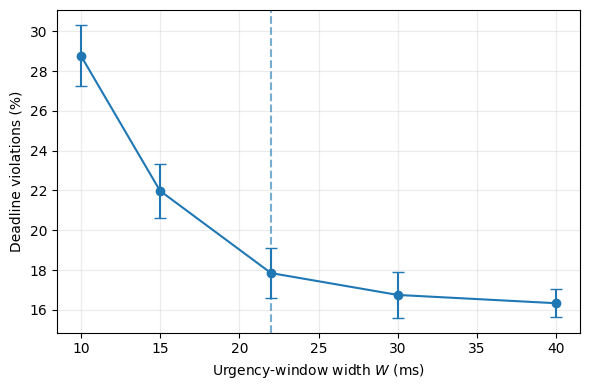

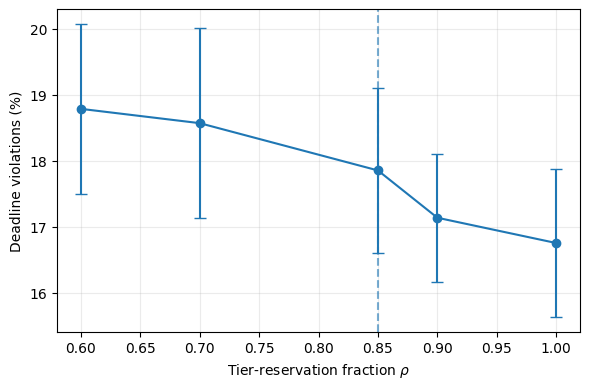


Finished.
Results saved in: /content/PQC_HO_PARAMETER_SENSITIVITY


In [ ]:
# ============================================================
# STANDALONE PQC-HO PARAMETER SENSITIVITY
# W = urgency-window width
# rho = tier-reservation fraction
#
# Completely independent cell.
# Does NOT require functions from previous notebook cells.
# ============================================================

import math
import copy
import time
from dataclasses import dataclass, replace
from pathlib import Path
from typing import Dict, List, Optional, Sequence, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats


# ============================================================
# 1. PQC PROFILES
#    Same P1/P2/P3 values used in the manuscript
# ============================================================

@dataclass(frozen=True)
class PQCProfile:
    profile: str
    kem: str
    signature: str
    kem_public_key_bytes: int
    kem_ciphertext_bytes: int
    sig_public_key_bytes: int
    signature_bytes: int
    edge_crypto_ms: float
    protocol_overhead_bytes: int = 600

    @property
    def payload_bytes(self):
        return int(
            self.kem_public_key_bytes
            + self.kem_ciphertext_bytes
            + self.sig_public_key_bytes
            + self.signature_bytes
            + self.protocol_overhead_bytes
        )


# Measured profiles used in the current study
profiles = {
    "P1": PQCProfile(
        profile="P1",
        kem="ML-KEM-512",
        signature="ML-DSA-44",
        kem_public_key_bytes=800,
        kem_ciphertext_bytes=768,
        sig_public_key_bytes=1312,
        signature_bytes=2420,
        edge_crypto_ms=0.0896,
    ),

    "P2": PQCProfile(
        profile="P2",
        kem="ML-KEM-768",
        signature="ML-DSA-65",
        kem_public_key_bytes=1184,
        kem_ciphertext_bytes=1088,
        sig_public_key_bytes=1952,
        signature_bytes=3309,
        edge_crypto_ms=0.1007,
    ),

    "P3": PQCProfile(
        profile="P3",
        kem="ML-KEM-1024",
        signature="ML-DSA-87",
        kem_public_key_bytes=1568,
        kem_ciphertext_bytes=1568,
        sig_public_key_bytes=2592,
        signature_bytes=4627,
        edge_crypto_ms=0.1337,
    ),
}

PROFILE_ORDER = ["P1", "P2", "P3"]


print("PQC profiles:")
for p, x in profiles.items():
    print(
        p,
        f"payload={x.payload_bytes} bytes,",
        f"edge={x.edge_crypto_ms:.4f} ms"
    )


# ============================================================
# 2. SIMULATION CONFIGURATION
# ============================================================

@dataclass
class SimConfig:

    # Time
    dt_ms: float = 1.0
    fixed_signaling_ms: float = 4.0
    max_simulation_ms: float = 6000.0

    # Vehicles / arrivals
    n_vehicles: int = 300
    arrival_window_ms: float = 300.0
    burst_window_ms: float = 60.0
    storm_fraction: float = 0.75
    arrival_mode: str = "storm"

    # PQC mixture
    profile_p1: float = 0.40
    profile_p2: float = 0.40
    profile_p3: float = 0.20

    # Deadlines
    deadline_min_ms: float = 70.0
    deadline_max_ms: float = 140.0
    hard_failure_ms: float = 200.0

    # Parameters tested here
    urgency_window_ms: float = 22.0
    tier_fairness_fraction: float = 0.85

    # Radio
    total_bandwidth_mhz: float = 20.0
    mean_snr_db: float = 12.0
    snr_std_db: float = 4.0
    snr_random_walk_std_db: float = 0.12
    min_snr_db: float = -5.0
    max_snr_db: float = 30.0

    packet_loss: float = 0.01
    mtu_bytes: int = 1500
    per_packet_overhead_bytes: int = 64

    # MEC
    mec_reference_cores: float = 4.0
    crypto_cpu_share: float = 0.10

    # Small workload variation
    payload_noise_sigma: float = 0.02
    compute_noise_sigma: float = 0.05

    # Admission
    admission_capacity_fraction: float = 1.0
    scheduler_epsilon_ms: float = 1e-6


# ============================================================
# 3. JOB MODEL
# ============================================================

@dataclass
class Job:
    job_id: int
    profile: str

    arrival_ms: float
    deadline_ms: float
    hard_deadline_ms: float

    payload_bytes: float

    total_wire_bits: float
    remaining_wire_bits: float

    compute_work_ms: float
    remaining_compute_ms: float

    snr_db: float
    packet_loss: float

    phase: str = "radio"

    tx_done_ms: Optional[float] = None
    complete_ms: Optional[float] = None

    served_bits: float = 0.0
    served_compute_ms: float = 0.0

    @property
    def absolute_deadline_ms(self):
        return self.arrival_ms + self.deadline_ms

    @property
    def absolute_hard_deadline_ms(self):
        return self.arrival_ms + self.hard_deadline_ms

    def clone(self):
        return copy.deepcopy(self)


# ============================================================
# 4. BASIC HELPERS
# ============================================================

def spectral_efficiency(snr_db):
    snr_linear = 10.0 ** (snr_db / 10.0)
    return math.log2(1.0 + snr_linear)


def wire_bits(payload_bytes, cfg):
    n_packets = max(
        1,
        math.ceil(payload_bytes / cfg.mtu_bytes)
    )

    total_bytes = (
        payload_bytes
        + n_packets * cfg.per_packet_overhead_bytes
    )

    return float(total_bytes * 8.0)


def profile_probabilities(cfg):

    p = np.array([
        cfg.profile_p1,
        cfg.profile_p2,
        cfg.profile_p3
    ])

    return p / p.sum()


# ============================================================
# 5. GENERATE NOMINAL HANDOVER-STORM JOBS
# ============================================================

def generate_jobs(cfg, profiles, seed):

    rng = np.random.default_rng(seed)

    n = cfg.n_vehicles

    # ---------------- Arrival process ----------------

    n_storm = int(round(n * cfg.storm_fraction))

    center = cfg.arrival_window_ms / 2

    storm = rng.uniform(
        center - cfg.burst_window_ms / 2,
        center + cfg.burst_window_ms / 2,
        size=n_storm,
    )

    normal = rng.uniform(
        0,
        cfg.arrival_window_ms,
        size=n - n_storm,
    )

    arrivals = np.concatenate([storm, normal])

    rng.shuffle(arrivals)

    # ---------------- Security profiles ----------------

    tier_ids = rng.choice(
        PROFILE_ORDER,
        size=n,
        p=profile_probabilities(cfg),
    )

    # ---------------- Deadlines ----------------

    deadlines = rng.uniform(
        cfg.deadline_min_ms,
        cfg.deadline_max_ms,
        size=n,
    )

    # ---------------- Initial channels ----------------

    snrs = np.clip(
        rng.normal(
            cfg.mean_snr_db,
            cfg.snr_std_db,
            size=n,
        ),
        cfg.min_snr_db,
        cfg.max_snr_db,
    )

    jobs = []

    for i in range(n):

        prof = profiles[tier_ids[i]]

        payload_factor = rng.lognormal(
            0.0,
            cfg.payload_noise_sigma
        )

        compute_factor = rng.lognormal(
            0.0,
            cfg.compute_noise_sigma
        )

        payload = (
            prof.payload_bytes
            * payload_factor
        )

        compute = (
            prof.edge_crypto_ms
            * compute_factor
        )

        bits = wire_bits(payload, cfg)

        jobs.append(
            Job(
                job_id=i,
                profile=prof.profile,

                arrival_ms=float(arrivals[i]),
                deadline_ms=float(deadlines[i]),
                hard_deadline_ms=cfg.hard_failure_ms,

                payload_bytes=float(payload),

                total_wire_bits=float(bits),
                remaining_wire_bits=float(bits),

                compute_work_ms=float(compute),
                remaining_compute_ms=float(compute),

                snr_db=float(snrs[i]),
                packet_loss=cfg.packet_loss,
            )
        )

    jobs.sort(
        key=lambda x: (
            x.arrival_ms,
            x.job_id
        )
    )

    return jobs


# ============================================================
# 6. SERVICE-TIME ESTIMATION
# ============================================================

def radio_service_ms(job, cfg):

    rate = (
        cfg.total_bandwidth_mhz
        * 1e6
        * spectral_efficiency(job.snr_db)
        * (1.0 - job.packet_loss)
    )

    return (
        1000.0
        * job.remaining_wire_bits
        / max(rate, 1e-12)
    )


def compute_service_ms(job, cfg):

    capacity = (
        cfg.mec_reference_cores
        * cfg.crypto_cpu_share
    )

    return (
        job.remaining_compute_ms
        / max(capacity, 1e-12)
    )


def remaining_service_ms(
    job,
    stage,
    cfg,
):

    comp = compute_service_ms(
        job,
        cfg
    )

    if stage == "compute":
        return comp

    radio = radio_service_ms(
        job,
        cfg
    )

    return radio + comp


def stage_service_ms(
    job,
    stage,
    cfg,
):

    if stage == "radio":
        return radio_service_ms(job, cfg)

    return compute_service_ms(job, cfg)


# ============================================================
# 7. OBJECTIVE SLACK
# ============================================================

def objective_slack_ms(
    job,
    t_ms,
    service_ms,
    cfg,
):

    soft = (
        job.absolute_deadline_ms
        - t_ms
    )

    if soft > 0:
        return max(
            soft,
            cfg.scheduler_epsilon_ms
        )

    hard = (
        job.absolute_hard_deadline_ms
        - t_ms
    )

    if hard > 0:
        return max(
            hard,
            cfg.scheduler_epsilon_ms
        )

    return max(
        service_ms,
        cfg.dt_ms,
        cfg.scheduler_epsilon_ms
    )


# ============================================================
# 8. REQUIRED STAGE FRACTIONS
# ============================================================

def required_stage_fractions(
    jobs,
    stage,
    t_ms,
    cfg,
):

    values = []

    for j in jobs:

        total_service = remaining_service_ms(
            j,
            stage,
            cfg,
        )

        stage_service = stage_service_ms(
            j,
            stage,
            cfg,
        )

        slack = objective_slack_ms(
            j,
            t_ms,
            total_service,
            cfg,
        )

        values.append(
            stage_service / slack
        )

    return values


# ============================================================
# 9. CAPACITY-BASED ADMISSION
# ============================================================

def capacity_admission_count(
    ordered_required,
    cfg,
):

    if len(ordered_required) == 0:
        return 0

    cap = cfg.admission_capacity_fraction

    total = 0.0
    worst = 0.0

    best_k = 1

    for k, d in enumerate(
        ordered_required,
        start=1
    ):

        d = max(
            float(d),
            cfg.scheduler_epsilon_ms
        )

        total += d
        worst = max(worst, d)

        feasible = (
            total <= cap + 1e-12
            and
            k * worst <= cap + 1e-12
        )

        if k == 1 or feasible:
            best_k = k
        else:
            break

    return max(
        1,
        min(
            len(ordered_required),
            best_k
        )
    )


# ============================================================
# 10. PARTIAL TIER NON-STARVATION
# ============================================================

def partial_tier_fair_select(
    jobs,
    ranked_indices,
    k,
    t_ms,
    cfg,
):

    if k <= 0:
        return []

    groups = {}

    for idx in ranked_indices:

        tier = jobs[idx].profile

        groups.setdefault(
            tier,
            []
        ).append(idx)

    tiers = [
        x
        for x in PROFILE_ORDER
        if x in groups
    ]

    L = len(tiers)

    if L == 0:
        return []

    if k >= len(jobs):
        return list(ranked_indices)

    # ------------------------------------------------
    # If fewer service slots than active tiers:
    # deterministically rotate which tiers are served.
    # ------------------------------------------------

    if k < L:

        epoch = int(
            round(
                t_ms
                / max(cfg.dt_ms, 1e-12)
            )
        )

        start = epoch % L

        chosen = []

        for r in range(k):

            tier = tiers[
                (start + r) % L
            ]

            chosen.append(
                groups[tier][0]
            )

        chosen_set = set(chosen)

        return [
            idx
            for idx in ranked_indices
            if idx in chosen_set
        ][:k]

    # ------------------------------------------------
    # One guaranteed opportunity per active tier
    # ------------------------------------------------

    quotas = {
        tier: 1
        for tier in tiers
    }

    remaining = k - L

    # ------------------------------------------------
    # rho controls how much of remaining capacity
    # receives proportional tier reservation
    # ------------------------------------------------

    if (
        remaining > 0
        and
        cfg.tier_fairness_fraction > 0
    ):

        counts = {
            tier: len(groups[tier])
            for tier in tiers
        }

        total = float(
            sum(counts.values())
        )

        rho = np.clip(
            cfg.tier_fairness_fraction,
            0.0,
            1.0
        )

        desired_reserved = {
            tier:
                rho
                * remaining
                * counts[tier]
                / total
            for tier in tiers
        }

        for tier in tiers:

            add = min(
                counts[tier] - 1,
                int(
                    math.floor(
                        desired_reserved[tier]
                    )
                )
            )

            quotas[tier] += max(
                0,
                add
            )

    chosen = []

    for tier in tiers:

        chosen.extend(
            groups[tier][
                :quotas[tier]
            ]
        )

    chosen_set = set(chosen)

    # Remaining unreserved slots:
    # use global workload/urgency ranking

    for idx in ranked_indices:

        if len(chosen) >= k:
            break

        if idx not in chosen_set:

            chosen.append(idx)

            chosen_set.add(idx)

    return [
        idx
        for idx in ranked_indices
        if idx in chosen_set
    ][:k]


# ============================================================
# 11. PQC-HO SCHEDULER
# ============================================================

def select_jobs(
    jobs,
    stage,
    t_ms,
    cfg,
):

    n = len(jobs)

    if n == 0:
        return []

    W = max(
        cfg.urgency_window_ms,
        cfg.dt_ms,
        cfg.scheduler_epsilon_ms,
    )

    scores = []

    for i, j in enumerate(jobs):

        service = remaining_service_ms(
            j,
            stage,
            cfg,
        )

        soft_slack = (
            j.absolute_deadline_ms
            - t_ms
        )

        hard_slack = (
            j.absolute_hard_deadline_ms
            - t_ms
        )

        # ---------------------------------------------
        # Before soft deadline
        # ---------------------------------------------

        if soft_slack > 0:

            urgency_bin = int(
                math.floor(
                    soft_slack / W
                )
            )

            key = (
                0,
                urgency_bin,
                service,
                j.absolute_deadline_ms,
                j.job_id,
            )

        # ---------------------------------------------
        # Soft deadline missed, hard threshold remains
        # ---------------------------------------------

        elif hard_slack > 0:

            urgency_bin = int(
                math.floor(
                    hard_slack / W
                )
            )

            key = (
                1,
                urgency_bin,
                service,
                j.absolute_hard_deadline_ms,
                j.job_id,
            )

        # ---------------------------------------------
        # Hard threshold already passed
        # ---------------------------------------------

        else:

            key = (
                2,
                service,
                j.arrival_ms,
                j.job_id,
            )

        scores.append(
            (i, key)
        )

    ranked_indices = [
        x[0]
        for x in sorted(
            scores,
            key=lambda x: x[1]
        )
    ]

    required = required_stage_fractions(
        jobs,
        stage,
        t_ms,
        cfg,
    )

    k = capacity_admission_count(
        [
            required[i]
            for i in ranked_indices
        ],
        cfg,
    )

    selected = partial_tier_fair_select(
        jobs,
        ranked_indices,
        k,
        t_ms,
        cfg,
    )

    # Verify actual fair-selected set is feasible

    cap = cfg.admission_capacity_fraction

    while (
        len(selected) > 1
        and
        (
            sum(
                required[i]
                for i in selected
            ) > cap + 1e-12

            or

            len(selected)
            * max(
                required[i]
                for i in selected
            ) > cap + 1e-12
        )
    ):

        k -= 1

        selected = partial_tier_fair_select(
            jobs,
            ranked_indices,
            k,
            t_ms,
            cfg,
        )

    return selected


# ============================================================
# 12. RESOURCE ALLOCATION
# ============================================================

def allocation_fractions(
    jobs,
    selected,
    stage,
    t_ms,
    cfg,
):

    out = np.zeros(
        len(jobs),
        dtype=float
    )

    if len(selected) == 0:
        return out

    required = required_stage_fractions(
        jobs,
        stage,
        t_ms,
        cfg,
    )

    demand = np.array([
        max(
            required[i],
            cfg.scheduler_epsilon_ms
        )
        for i in selected
    ])

    total_demand = demand.sum()

    if (
        not np.isfinite(total_demand)
        or total_demand <= 0
    ):

        out[selected] = (
            1.0 / len(selected)
        )

        return out

    if total_demand <= 1.0:

        residual = (
            1.0 - total_demand
        )

        shares = (
            demand
            + residual / len(selected)
        )

        shares /= shares.sum()

    else:

        shares = (
            demand / total_demand
        )

    out[selected] = shares

    return out


# ============================================================
# 13. SIMULATION
# ============================================================

def simulate(
    template_jobs,
    cfg,
    seed,
):

    rng = np.random.default_rng(
        seed + 880301
    )

    jobs = [
        j.clone()
        for j in template_jobs
    ]

    t_ms = 0.0
    next_idx = 0

    active = []

    last_arrival = max(
        j.arrival_ms
        for j in jobs
    )

    stop_at = min(
        cfg.max_simulation_ms,
        last_arrival
        + max(
            1500.0,
            12.0 * cfg.hard_failure_ms
        )
    )

    while t_ms <= stop_at:

        # ---------------------------------------------
        # New arrivals
        # ---------------------------------------------

        while (
            next_idx < len(jobs)
            and
            jobs[next_idx].arrival_ms
            <= t_ms + 1e-9
        ):

            active.append(
                jobs[next_idx]
            )

            next_idx += 1

        # ---------------------------------------------
        # Channel evolution
        # ---------------------------------------------

        for j in active:

            if j.phase == "radio":

                j.snr_db = float(
                    np.clip(
                        j.snr_db
                        + rng.normal(
                            0.0,
                            cfg.snr_random_walk_std_db
                        ),

                        cfg.min_snr_db,
                        cfg.max_snr_db,
                    )
                )

        radio_jobs = [
            j
            for j in active
            if j.phase == "radio"
        ]

        compute_jobs = [
            j
            for j in active
            if j.phase == "compute"
        ]

        # ---------------------------------------------
        # Scheduling
        # ---------------------------------------------

        radio_selected = select_jobs(
            radio_jobs,
            "radio",
            t_ms,
            cfg,
        )

        compute_selected = select_jobs(
            compute_jobs,
            "compute",
            t_ms,
            cfg,
        )

        radio_alloc = allocation_fractions(
            radio_jobs,
            radio_selected,
            "radio",
            t_ms,
            cfg,
        )

        compute_alloc = allocation_fractions(
            compute_jobs,
            compute_selected,
            "compute",
            t_ms,
            cfg,
        )

        # ---------------------------------------------
        # RADIO SERVICE
        # ---------------------------------------------

        total_bw_hz = (
            cfg.total_bandwidth_mhz
            * 1e6
        )

        for j, fraction in zip(
            radio_jobs,
            radio_alloc
        ):

            if fraction <= 0:
                continue

            bandwidth = (
                total_bw_hz
                * fraction
            )

            rate = (
                bandwidth
                * spectral_efficiency(
                    j.snr_db
                )
            )

            attempted_bits = (
                rate
                * cfg.dt_ms
                / 1000.0
            )

            served_bits = (
                attempted_bits
                * (1.0 - j.packet_loss)
            )

            actual = min(
                j.remaining_wire_bits,
                served_bits
            )

            j.remaining_wire_bits -= actual
            j.served_bits += actual

            if (
                j.remaining_wire_bits
                <= 1e-6
            ):

                j.remaining_wire_bits = 0.0

                j.phase = "compute"

                j.tx_done_ms = (
                    t_ms
                    + cfg.dt_ms
                )

        # ---------------------------------------------
        # MEC SERVICE
        # ---------------------------------------------

        compute_capacity = (
            cfg.mec_reference_cores
            * cfg.crypto_cpu_share
        )

        for j, fraction in zip(
            compute_jobs,
            compute_alloc
        ):

            if fraction <= 0:
                continue

            service = (
                compute_capacity
                * fraction
                * cfg.dt_ms
            )

            actual = min(
                j.remaining_compute_ms,
                service
            )

            j.remaining_compute_ms -= actual
            j.served_compute_ms += actual

            if (
                j.remaining_compute_ms
                <= 1e-9
            ):

                j.remaining_compute_ms = 0

                j.phase = "complete"

                j.complete_ms = (
                    t_ms
                    + cfg.dt_ms
                    + cfg.fixed_signaling_ms
                )

        # Remove finished requests

        active = [
            j
            for j in active
            if j.phase != "complete"
        ]

        if (
            next_idx >= len(jobs)
            and
            len(active) == 0
        ):
            break

        t_ms += cfg.dt_ms


    # ========================================================
    # METRICS
    # ========================================================

    records = []

    for j in jobs:

        if j.complete_ms is None:

            latency = np.nan

            violation = 1

            effective_latency = max(
                0.0,
                stop_at - j.arrival_ms
            )

        else:

            latency = (
                j.complete_ms
                - j.arrival_ms
            )

            violation = int(
                latency
                > j.deadline_ms
            )

            effective_latency = latency

        tardiness = max(
            0.0,
            effective_latency
            - j.deadline_ms
        )

        records.append({
            "job_id": j.job_id,
            "profile": j.profile,
            "latency_ms": latency,
            "deadline_violation": violation,
            "tardiness_ms": tardiness,
        })

    df = pd.DataFrame(records)

    return {
        "deadline_violation_rate":
            df["deadline_violation"].mean(),

        "mean_tardiness_ms":
            df["tardiness_ms"].mean(),

        "mean_latency_ms":
            df["latency_ms"].mean(),

        "p95_latency_ms":
            df["latency_ms"].quantile(0.95),
    }


# ============================================================
# 14. RUN ONE PARAMETER SETTING
# ============================================================

def run_setting(
    cfg,
    seeds
):

    rows = []

    for seed in seeds:

        jobs = generate_jobs(
            cfg,
            profiles,
            seed
        )

        metrics = simulate(
            jobs,
            cfg,
            seed
        )

        rows.append({
            "seed": seed,
            **metrics
        })

    return pd.DataFrame(rows)


# ============================================================
# 15. 95% CONFIDENCE INTERVAL
# ============================================================

def mean_ci(x):

    x = np.asarray(
        x,
        dtype=float
    )

    x = x[
        np.isfinite(x)
    ]

    mean = np.mean(x)

    if len(x) <= 1:

        return mean, np.nan

    ci = (
        stats.t.ppf(
            0.975,
            len(x) - 1
        )
        * stats.sem(x)
    )

    return mean, ci


# ============================================================
# 16. PARAMETER VALUES
# ============================================================

SEEDS = list(
    range(
        7001,
        7021
    )
)

W_VALUES = [
    10,
    15,
    22,
    30,
    40
]

RHO_VALUES = [
    0.60,
    0.70,
    0.85,
    0.90,
    1.00
]

BASE_CFG = SimConfig()

OUTDIR = Path(
    "PQC_HO_PARAMETER_SENSITIVITY"
)

OUTDIR.mkdir(
    exist_ok=True
)


# ============================================================
# 17. W SENSITIVITY
#     rho fixed at 0.85
# ============================================================

all_raw = []
summary_rows = []

print(
    "\n========================================"
)
print(
    "W SENSITIVITY"
)
print(
    "========================================"
)

for W in W_VALUES:

    print(
        f"Running W = {W} ms..."
    )

    cfg = replace(
        BASE_CFG,
        urgency_window_ms=float(W),
        tier_fairness_fraction=0.85,
    )

    result = run_setting(
        cfg,
        SEEDS
    )

    result["parameter"] = "W"
    result["value"] = W

    all_raw.append(result)

    v_mean, v_ci = mean_ci(
        100
        * result[
            "deadline_violation_rate"
        ]
    )

    t_mean, t_ci = mean_ci(
        result[
            "mean_tardiness_ms"
        ]
    )

    summary_rows.append({
        "Parameter": "W (ms)",
        "Value": W,

        "Viol. (%)": v_mean,
        "Viol. CI95": v_ci,

        "Tard. (ms)": t_mean,
        "Tard. CI95": t_ci,
    })


# ============================================================
# 18. rho SENSITIVITY
#     W fixed at 22 ms
# ============================================================

print(
    "\n========================================"
)
print(
    "RHO SENSITIVITY"
)
print(
    "========================================"
)

for rho in RHO_VALUES:

    print(
        f"Running rho = {rho:.2f}..."
    )

    cfg = replace(
        BASE_CFG,
        urgency_window_ms=22.0,
        tier_fairness_fraction=float(rho),
    )

    result = run_setting(
        cfg,
        SEEDS
    )

    result["parameter"] = "rho"
    result["value"] = rho

    all_raw.append(result)

    v_mean, v_ci = mean_ci(
        100
        * result[
            "deadline_violation_rate"
        ]
    )

    t_mean, t_ci = mean_ci(
        result[
            "mean_tardiness_ms"
        ]
    )

    summary_rows.append({
        "Parameter": "rho",
        "Value": rho,

        "Viol. (%)": v_mean,
        "Viol. CI95": v_ci,

        "Tard. (ms)": t_mean,
        "Tard. CI95": t_ci,
    })


# ============================================================
# 19. SAVE RESULTS
# ============================================================

raw_df = pd.concat(
    all_raw,
    ignore_index=True
)

summary_df = pd.DataFrame(
    summary_rows
)

raw_df.to_csv(
    OUTDIR
    / "parameter_sensitivity_raw.csv",
    index=False
)

summary_df.to_csv(
    OUTDIR
    / "parameter_sensitivity_summary.csv",
    index=False
)


# ============================================================
# 20. PRINT MANUSCRIPT RESULTS
# ============================================================

print(
    "\n\n========================================"
)
print(
    "FINAL PARAMETER SENSITIVITY TABLE"
)
print(
    "========================================"
)

print(
    summary_df[
        [
            "Parameter",
            "Value",
            "Viol. (%)",
            "Tard. (ms)"
        ]
    ].to_string(
        index=False,
        formatters={
            "Viol. (%)":
                lambda x: f"{x:.2f}",

            "Tard. (ms)":
                lambda x: f"{x:.2f}",
        }
    )
)


# ============================================================
# 21. GENERATE LATEX TABLE AUTOMATICALLY
# ============================================================

latex = r"""
\begin{table}[t]
\centering
\caption{Sensitivity to urgency-window width $W$ and tier-reservation
fraction $\rho$.}
\label{tab:param_sensitivity}
\footnotesize
\setlength{\tabcolsep}{3.5pt}
\begin{tabular}{c c c c}
\hline
Parameter & Value & Viol. (\%) & Tard. (ms) \\
\hline
"""

w_part = summary_df[
    summary_df["Parameter"]
    == "W (ms)"
]

for i, (_, row) in enumerate(
    w_part.iterrows()
):

    pname = (
        r"$W$ (ms)"
        if i == 0
        else ""
    )

    latex += (
        f"{pname} & "
        f"{row['Value']:g} & "
        f"{row['Viol. (%)']:.2f} & "
        f"{row['Tard. (ms)']:.2f} "
        "\\\\\n"
    )


latex += "\\hline\n"


rho_part = summary_df[
    summary_df["Parameter"]
    == "rho"
]

for i, (_, row) in enumerate(
    rho_part.iterrows()
):

    pname = (
        r"$\rho$"
        if i == 0
        else ""
    )

    latex += (
        f"{pname} & "
        f"{row['Value']:.2f} & "
        f"{row['Viol. (%)']:.2f} & "
        f"{row['Tard. (ms)']:.2f} "
        "\\\\\n"
    )


latex += r"""\hline
\end{tabular}
\end{table}
"""


print(
    "\n========================================"
)
print(
    "LATEX TABLE"
)
print(
    "========================================\n"
)

print(latex)


with open(
    OUTDIR
    / "parameter_sensitivity_table.tex",
    "w"
) as f:

    f.write(latex)


# ============================================================
# 22. PLOT W
# ============================================================

wplot = summary_df[
    summary_df["Parameter"]
    == "W (ms)"
].copy()

plt.figure(
    figsize=(6, 4)
)

plt.errorbar(
    wplot["Value"],
    wplot["Viol. (%)"],
    yerr=wplot["Viol. CI95"],
    marker="o",
    capsize=4,
)

plt.axvline(
    22,
    linestyle="--",
    alpha=0.6,
)

plt.xlabel(
    r"Urgency-window width $W$ (ms)"
)

plt.ylabel(
    "Deadline violations (%)"
)

plt.grid(
    alpha=0.25
)

plt.tight_layout()

plt.savefig(
    OUTDIR
    / "sensitivity_W.pdf",
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 23. PLOT rho
# ============================================================

rplot = summary_df[
    summary_df["Parameter"]
    == "rho"
].copy()

plt.figure(
    figsize=(6, 4)
)

plt.errorbar(
    rplot["Value"],
    rplot["Viol. (%)"],
    yerr=rplot["Viol. CI95"],
    marker="o",
    capsize=4,
)

plt.axvline(
    0.85,
    linestyle="--",
    alpha=0.6,
)

plt.xlabel(
    r"Tier-reservation fraction $\rho$"
)

plt.ylabel(
    "Deadline violations (%)"
)

plt.grid(
    alpha=0.25
)

plt.tight_layout()

plt.savefig(
    OUTDIR
    / "sensitivity_rho.pdf",
    bbox_inches="tight"
)

plt.show()


print(
    "\nFinished."
)

print(
    f"Results saved in: {OUTDIR.resolve()}"
)